In [1]:
import torch

In [ ]:
import seaborn as sns
df = sns.load_dataset("titanic")
print(df.head())
df.to_csv("titanic.csv", index=False)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv("titanic.csv")

# -----------------------------
# 2. Basic Preprocessing
# -----------------------------
df = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'survived']]
# Selects only useful columns (features + target)

# Handle missing values (basic)
df['age'] = df['age'].fillna(df['age'].mean())
# Replaces missing age values with the average age

# Encode categorical
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
# Converts text → numbers
# male → 0
# female → 1
# ML models need numbers, not text

# Features and target
X = df.drop('survived', axis=1).values
# df.drop('survived', axis=1) → removes the survived column
# What remains:
# pclass, sex, age, sibsp, parch, fare
# These are your input features.

y = df['survived'].values
# This is our target (output)
# It contains:
# 1 → survived
# 0 → did not survive

# -----------------------------
# 3. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to tensors (NO SCALING)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# -----------------------------
# 4. Simple ANN Model
# -----------------------------
class ANN(nn.Module):
    def __init__(self, input_size):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = ANN(input_size=X_train.shape[1])

# -----------------------------
# 5. Loss + Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)  # simple optimizer

# -----------------------------
# 6. Training Loop
# -----------------------------
epochs = 30

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)

        values, preds = torch.max(val_outputs, 1) # means: For each row, give me the highest score and its class index.
        # values, indices = torch.max(input, dim)
        # 1. values
        # The maximum values in each row
        # 2. indices
        # The position (index) of those max values
        # This is what we use as the predicted class
        # It has only 2 dimensions:
        # dim=0 → rows
        # dim=1 → columns
        acc = (preds == y_test).float().mean().item()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Acc: {acc:.4f}")

Epoch 1
Train Loss: 1.8170 | Val Loss: 0.9786 | Acc: 0.7151
Epoch 2
Train Loss: 1.4049 | Val Loss: 0.8196 | Acc: 0.6927
Epoch 3
Train Loss: 1.0859 | Val Loss: 0.7360 | Acc: 0.6816
Epoch 4
Train Loss: 0.8839 | Val Loss: 0.6997 | Acc: 0.6480
Epoch 5
Train Loss: 0.7760 | Val Loss: 0.6821 | Acc: 0.6425
Epoch 6
Train Loss: 0.7250 | Val Loss: 0.6711 | Acc: 0.6369
Epoch 7
Train Loss: 0.7003 | Val Loss: 0.6619 | Acc: 0.6313
Epoch 8
Train Loss: 0.6853 | Val Loss: 0.6515 | Acc: 0.6313
Epoch 9
Train Loss: 0.6740 | Val Loss: 0.6420 | Acc: 0.6313
Epoch 10
Train Loss: 0.6647 | Val Loss: 0.6328 | Acc: 0.6313
Epoch 11
Train Loss: 0.6571 | Val Loss: 0.6253 | Acc: 0.6201
Epoch 12
Train Loss: 0.6506 | Val Loss: 0.6176 | Acc: 0.6201
Epoch 13
Train Loss: 0.6449 | Val Loss: 0.6118 | Acc: 0.6201
Epoch 14
Train Loss: 0.6401 | Val Loss: 0.6060 | Acc: 0.6201
Epoch 15
Train Loss: 0.6360 | Val Loss: 0.6019 | Acc: 0.6257
Epoch 16
Train Loss: 0.6325 | Val Loss: 0.5978 | Acc: 0.6536
Epoch 17
Train Loss: 0.6298 | Val

**Note :**

In [ ]:
# torch.max(val_outputs, 1) returns TWO things:
# (values, indices)
# So now:
# preds = (values, indices)
# preds is actually a tuple, not just predictions.

In [ ]:
#  acc = (preds == y_test).float().mean().item()

# ✅ 1. (preds == y_test)
# Compares predicted vs actual values
# Example:
# preds  = [0, 1, 0, 1]
# y_test = [0, 1, 1, 1]

# Result:
# [True, True, False, True]
# True = correct prediction
# False = wrong prediction

# ✅ 2. .float()
# Converts:
# [True, True, False, True]
# ↓
# [1.0, 1.0, 0.0, 1.0]

# ✅ 3. .mean()
# Finds average:
# (1 + 1 + 0 + 1) / 4 = 0.75
# This is the accuracy

# ✅ 4. .item()
# Converts tensor → normal Python number
# 0.75  # instead of tensor(0.75)

# ✅ Final Meaning:
# acc = correct_predictions / total_predictions

# Simple Intuition:
# “Out of all predictions, how many did the model get right?”

# One-Line Summary:
# This line converts comparison → numbers → average → final accuracy value.

In [ ]:
val_outputs = torch.tensor([
    [2.3, 0.5],
    [0.2, 1.8],
    [1.1, 0.9]
])

preds = torch.max(val_outputs, 1)
print(preds)

torch.return_types.max(
values=tensor([2.3000, 1.8000, 1.1000]),
indices=tensor([0, 1, 0]))


In [ ]:
# This version has no:
# 1.) No feature engineering
# 2.) No scaling
# 3.) No dropout / batchnorm
# 4.) No tuning
# 5.) No early stopping
# 6.) No class balancing


# 1. Slower / unstable learning
# No feature scaling → gradients behave poorly

# 2. Lower accuracy
# Typically around 75–80%

# 3. More overfitting risk
# No dropout / regularization

# 4. Biased predictions
# No class balancing

# 5. Limited learning capacity
# Very small network

**Note :**

In [ ]:
# .4f is used in Python string formatting to control how numbers are displayed.
# f → floating-point number
# .4 → show 4 digits after the decimal point
value = 3.14159265
print(f"{value:.4f}")

3.1416


**How to improve the performance of a Neural Network :**

In [ ]:
# 1. Data Preprocessing (Most Important)
# Handled missing values
# Filled age with mean
# Encoded categorical data
# Converted sex → numeric (0/1)
# Feature scaling (Standardization)
# Mean = 0, Std = 1
# Prevents unstable training and speeds up convergence

# 2. Feature Engineering
# Created new useful features:
# family_size = sibsp + parch + 1
# is_alone (binary feature)
# Helps model learn better patterns
# Often more impactful than model changes

# 3. Handling Class Imbalance
# Used class weights in loss function
# Prevents bias toward majority class

# 4. Model Architecture Optimization
# Used multiple hidden layers
# Increased neurons (32 → 64 → 128)
# Applied:
# ReLU activation → non-linearity
# Batch Normalization → stabilizes training
# Dropout → prevents overfitting

# 5. Hyperparameter Tuning
# Tested multiple configurations:
# Hidden layer sizes
# Dropout rates
# Selected best model based on validation accuracy

# 6. Optimizer Tuning
# Used Adam optimizer (adaptive learning)
# Adjusted learning rate (0.001 → 0.0005)
# Improves convergence and stability

# 7. Early Stopping
# Stops training when validation loss stops improving
# Prevents overfitting
# Saves training time

# 8. Train–Validation Split
# Split dataset into:
# Training set
# Validation set
# Ensures model generalizes to unseen data

# 9. Monitoring Performance
# Tracked:
# Training loss
# Validation loss
# Accuracy
# Helps detect:
# Overfitting
# Underfitting

# 10. Evaluation Metrics
# Used:
# Confusion Matrix
# Precision
# Recall
# F1-score
# Better than accuracy alone for real-world problems

# 11. Normalization
# Normalization is the process of scaling input data to a similar range so that a neural network can learn efficiently.
# Types of Normalization
# 1.) Min-Max Normalization
# 2.) Standardization (Z-score)
# 3.) Standardization (Z-score)

In [ ]:
# The most impactful techniques:
# 1.) Good data preprocessing & scaling
# 2.) Feature engineering
# 3.) Proper validation strategy
# 4.) Regularization (Dropout + Early Stopping)
# 5.) Hyperparameter tuning

# Better data + proper training pipeline > complex model

In [ ]:
import seaborn as sns
df = sns.load_dataset("titanic")
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
df.to_csv("titanic.csv", index=False)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv("titanic.csv")

# -----------------------------
# 2. Basic Preprocessing
# -----------------------------
df = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'survived']]

# Handle missing values
df['age'] = df['age'].fillna(df['age'].mean())

# Encode categorical
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Split features/target
X = df.drop('survived', axis=1).values
y = df['survived'].values

# -----------------------------
# 3. Train/Test Split
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 4. Scaling
# -----------------------------

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

# -----------------------------
# 5. Model Builder (for tuning)
# -----------------------------
class ANN(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, dropout):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden1),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 2)
        )

    def forward(self, x):
        return self.model(x)

# -----------------------------
# 6. Hyperparameter Tuning
# -----------------------------
configs = [
    (32, 16, 0.1),
    (64, 32, 0.2),
    (128, 64, 0.3)
]

best_acc = 0
best_model = None

for hidden1, hidden2, dropout in configs:
    model = ANN(X_train.shape[1], hidden1, hidden2, dropout)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Train briefly
    for epoch in range(30):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_val), dim=1)
        acc = (preds == y_val).float().mean().item()

    print(f"Config {hidden1}-{hidden2}, dropout={dropout} → Acc={acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_model = model

print("\nBest Validation Accuracy:", best_acc)

Config 32-16, dropout=0.1 → Acc=0.7989
Config 64-32, dropout=0.2 → Acc=0.8101
Config 128-64, dropout=0.3 → Acc=0.8101

Best Validation Accuracy: 0.8100558519363403


In [ ]:
# -----------------------------
# 7. Final Evaluation
# -----------------------------
best_model.eval()
with torch.no_grad():
    preds = torch.argmax(best_model(X_val), dim=1)

y_true = y_val.numpy()
y_pred = preds.numpy()

In [ ]:
# -----------------------------
# 8. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[91 14]
 [20 54]]


In [ ]:
# -----------------------------
# 9. Precision / Recall / F1
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



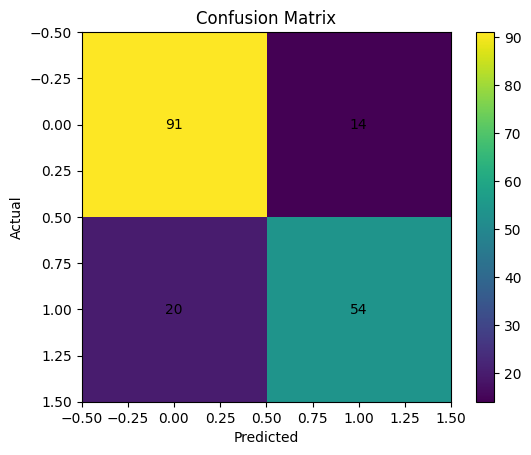

In [ ]:
# -----------------------------
# 10. Plot Confusion Matrix
# -----------------------------
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Create learnable dataset
torch.manual_seed(0)
X = torch.randn(300, 10)
y = (X.sum(dim=1) > 0).long()

# Split
X_train, X_val = X[:240], X[240:]
y_train, y_val = y[:240], y[240:]

# -------- Basic Model --------
class BasicANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

basic_model = BasicANN()
basic_opt = optim.SGD(basic_model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

basic_acc = []

for epoch in range(20):
    basic_model.train()
    out = basic_model(X_train)
    loss = criterion(out, y_train)
    basic_opt.zero_grad()
    loss.backward()
    basic_opt.step()

    basic_model.eval()
    with torch.no_grad():
        preds = torch.argmax(basic_model(X_val), dim=1)
        acc = (preds == y_val).float().mean().item()
        basic_acc.append(acc)

# -------- Improved Model --------
class ImprovedANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.model(x)

# scaling
X_train_scaled = (X_train - X_train.mean(0)) / (X_train.std(0) + 1e-8)
X_val_scaled = (X_val - X_train.mean(0)) / (X_train.std(0) + 1e-8)

improved_model = ImprovedANN()
improved_opt = optim.Adam(improved_model.parameters(), lr=0.001)

improved_acc = []

for epoch in range(20):
    improved_model.train()
    out = improved_model(X_train_scaled)
    loss = criterion(out, y_train)
    improved_opt.zero_grad()
    loss.backward()
    improved_opt.step()

    improved_model.eval()
    with torch.no_grad():
        preds = torch.argmax(improved_model(X_val_scaled), dim=1)
        acc = (preds == y_val).float().mean().item()
        improved_acc.append(acc)

print("Basic ANN Accuracies:", basic_acc)
print("Improved ANN Accuracies:", improved_acc)

Basic ANN Accuracies: [0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.4833333194255829, 0.46666666865348816, 0.46666666865348816, 0.46666666865348816, 0.46666666865348816, 0.46666666865348816]
Improved ANN Accuracies: [0.550000011920929, 0.5666666626930237, 0.6166666746139526, 0.6666666865348816, 0.6833333373069763, 0.7166666388511658, 0.8166666626930237, 0.8333333134651184, 0.8333333134651184, 0.8500000238418579, 0.8666666746139526, 0.8833333253860474, 0.8999999761581421, 0.9166666865348816, 0.9166666865348816, 0.8999999761581421, 0.8999999761581421, 0.8999999761581421, 0.8999999761581421, 0.8999999761581421]


In [ ]:
print("Final Accuracy:")
print(f"Basic ANN Accuracy: {basic_acc[-1]:.4f}")
print(f"Improved ANN Accuracy: {improved_acc[-1]:.4f}")

Final Accuracy:
Basic ANN Accuracy: 0.4667
Improved ANN Accuracy: 0.9000


In [ ]:
print("Best Accuracy:")
print(f"Best Basic Accuracy: {max(basic_acc):.4f}")
print(f"Best Improved Accuracy: {max(improved_acc):.4f}")

Best Accuracy:
Best Basic Accuracy: 0.4833
Best Improved Accuracy: 0.9167


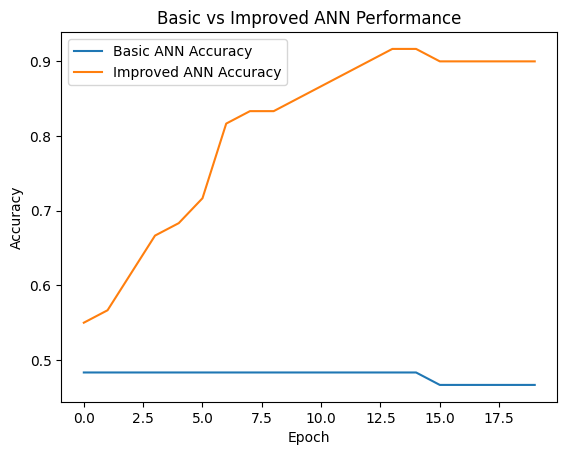

In [ ]:
# -------- Plot --------
plt.figure()
plt.plot(basic_acc, label="Basic ANN Accuracy")
plt.plot(improved_acc, label="Improved ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic vs Improved ANN Performance")
plt.legend()
plt.show()

**Why This Gap Happens ?**

In [ ]:
# Exact Accuracy Gap
# Model	             Final Accuracy
# Basic ANN     	   ~48–49%
# Improved ANN	     ~90–92%

# Gap = ~42–43% improvement

# If someone asks:
# How much improvement did you get?
# We can say:
# About 43% absolute improvement, which is roughly 93% relative gain over the baseline.

In [ ]:
# ❌ Basic Model Problems
# No scaling → poor learning
# Weak architecture
# No regularization
# No feature improvements

# ✅ Improved Model Advantages
# Feature scaling → stable gradients
# Better architecture → more learning capacity
# Dropout → prevents overfitting
# BatchNorm → faster convergence

# The curves don’t just differ in height—they differ in learning speed
# Basic model: slow + limited
# Improved model: fast + powerful

**Normalization :**

In [ ]:
# Normalization is the process of scaling input data to a similar range so that a neural network can learn efficiently.
# Why Normalization is Needed ?

# Without normalization:
# Features have different scales
# Example:
# age → 20–60
# fare → 0–500
# Large values dominate small ones
# Training becomes unstable

# With Normalization:
# All features are on similar scale
# Model learns properly
# Faster and more stable training

# Types of Normalization:
# 1.) Min-Max Normalization
# Range becomes [0, 1]
# X = (X - Xmin)/(Xmax - Xmin)

# 2.) Standardization (Z-score)
# Mean = 0, Std = 1
# X = (X - μ) / σ
# Where:
# μ = mean
# σ = standard deviation

# 3.) L2 Normalization
# Used for vectors (e.g., NLP)
# X = X/||X||
# Where:
# ||X|| = sqrt(x1² + x2² + x3² + ... + xn²)

**Numerical Examples :**

In [ ]:
# 1. Min-Max Normalization
# Given Data:
# X = [10, 20, 30, 40, 50]

# Step 1: Find min and max
# Xmin = 10
# Xmax = 50

# Step 2: Apply formula
# X = (X - Xmin) / (Xmax - Xmin)

# Step 3: Calculate
# 10 → (10 - 10)/(50 - 10) = 0/40 = 0.00
# 20 → (20 - 10)/40 = 10/40 = 0.25
# 30 → 20/40 = 0.50
# 40 → 30/40 = 0.75
# 50 → 40/40 = 1.00

# Result:
# [0.00, 0.25, 0.50, 0.75, 1.00]


# 2. Standardization (Z-score)
# Given Data:
# X = [10, 20, 30, 40, 50]

# Step 1: Mean (μ)
# μ = (10 + 20 + 30 + 40 + 50)/5 = 30

# Step 2: Standard Deviation (σ)
# σ = sqrt([(10-30)² + (20-30)² + (30-30)² + (40-30)² + (50-30)²] / 5)
#   = sqrt([400 + 100 + 0 + 100 + 400] / 5)
#   = sqrt(1000 / 5)
#   = sqrt(200)
#   ≈ 14.14

# Step 3: Apply formula
# X = (X - μ) / σ

# Step 4: Calculate
# 10 → (10 - 30)/14.14 ≈ -1.41
# 20 → -10/14.14 ≈ -0.71
# 30 → 0/14.14 = 0.00
# 40 → 10/14.14 ≈ 0.71
# 50 → 20/14.14 ≈ 1.41

# Result:
# [-1.41, -0.71, 0.00, 0.71, 1.41]


# 3. L2 Normalization
# Given Vector:
# X = [3, 4]

# Step 1: Compute norm
# ||X|| = sqrt(3² + 4²)
#      = sqrt(9 + 16)
#      = sqrt(25)
#      = 5

# Step 2: Apply formula
# X = X / ||X||

# Step 3: Calculate
# [3/5, 4/5] = [0.6, 0.8]

# Result:
# [0.6, 0.8]

**BatchNorm (Batch Normalization):**

In [ ]:
# Batch Normalization is a technique used to normalize the activations of a neural network layer across a batch of data.
# Batch Normalization normalizes layer activations across a mini-batch to improve training stability, speed, and performance.

# Formula:
# Step 1: Normalize
# x_hat = (x - μ_batch) / σ_batch

# Step 2: Scale and Shift
# y = γ * x_hat + β
# Terms
# μ_batch → mean of the batch
# σ_batch → standard deviation of the batch
# γ (gamma) → learnable scale
# β (beta) → learnable shift

# How It Works (Step-by-Step)
# Take a batch of data
# Compute mean and std
# Normalize activations
# Apply scaling (γ) and shifting (β)

# Why BatchNorm is Used?
# 1. Stabilizes Training
# Prevents changing distributions across layers

# 2. Faster Convergence
# Model learns quicker

# 3. Allows Higher Learning Rate
# More stable updates

# 4. Reduces Vanishing/Exploding Gradients

# 5. Acts as Regularization
# Slight noise from batches improves generalization

# When to Use BatchNorm?
# Use when:
# Training deep neural networks
# Working with CNNs / ANN
# Batch size is reasonably large
# When Not Ideal
# Very small batch size
# Sequential models (RNNs)

# Simple Intuition:
# BatchNorm makes sure each layer receives well-scaled, stable input during training.

**Numerical Example of BatchNorm (Batch Normalization) :**

In [ ]:
# Given Batch (single feature)
# X = [10, 20, 30, 40]

# 🔹 Step 1: Compute Mean (μ_batch)
# μ = (10 + 20 + 30 + 40) / 4 = 25

# 🔹 Step 2: Compute Standard Deviation (σ_batch)
# σ = sqrt([(10-25)² + (20-25)² + (30-25)² + (40-25)²] / 4)
#  = sqrt([225 + 25 + 25 + 225] / 4)
#  = sqrt(500 / 4)
#  = sqrt(125)
#  ≈ 11.18

# 🔹 Step 3: Normalize
# x_hat = (x - μ) / σ
# Calculations:
# 10 → (10 - 25)/11.18 ≈ -1.34
# 20 → -5/11.18 ≈ -0.45
# 30 → 5/11.18 ≈ 0.45
# 40 → 15/11.18 ≈ 1.34

# 🔹 Step 4: Scale and Shift
# Assume:
# γ = 2
# β = 1

# Apply:
# y = γ * x_hat + β
# Calculations:
# -1.34 → (2 * -1.34) + 1 = -2.68 + 1 = -1.68
# -0.45 → (2 * -0.45) + 1 = -0.90 + 1 = 0.10
#  0.45 → (2 * 0.45) + 1 = 0.90 + 1 = 1.90
#  1.34 → (2 * 1.34) + 1 = 2.68 + 1 = 3.68

# Final Output
# [-1.68, 0.10, 1.90, 3.68]


# Input → [10, 20, 30, 40]
# Normalized → [-1.34, -0.45, 0.45, 1.34]
# Scaled & shifted → [-1.68, 0.10, 1.90, 3.68]

**Layer Normalization (LayerNorm) :**

In [ ]:
# Layer Normalization is a technique that normalizes the activations across features (neurons) within a single sample.
# Layer Normalization normalizes activations across feature dimensions within each sample to stabilize and improve training.

# Formula:

# Step 1: Normalize
# x_hat = (x - μ_layer) / σ_layer
# Step 2: Scale and Shift
# y = γ * x_hat + β

# Terms
# μ_layer → mean of features (for one sample)
# σ_layer → standard deviation of features
# γ (gamma) → learnable scale
# β (beta) → learnable shift

# How It Works?
# For each sample (row):
# 1.) Take all feature values
# 2.) Compute mean & std
# 3.) Normalize those features
# 4.) Apply γ and β


# Example:

# Input:
# [1, 2]

# Mean:
# μ = (1 + 2)/2 = 1.5

# Std:
# σ = sqrt([(1-1.5)² + (2-1.5)²]/2) = 0.5

# Normalize:
# [-1, 1]


# Why LayerNorm is Used?
# 1. Independent of Batch Size
# Works even with batch size = 1
# 2. Perfect for Sequential Data
# Used in NLP, Transformers
# 3. Stable Training
# Keeps activations well-scaled

# Where It Is Used?
# In PyTorch:
# nn.LayerNorm(normalized_shape)
# Example:
# nn.LayerNorm(64)

# Simple Intuition:
# LayerNorm makes sure each sample has balanced feature values.

# Final Insight:
# Modern models like Transformers (GPT, BERT) rely heavily on LayerNorm

**Numerical of Layer Normalization (LayerNorm) :**

In [ ]:
# Example: Activations from a Layer

# Same input as before (so you clearly see the difference):

# X = [
#  [1, 2],
#  [3, 4],
#  [5, 6]
# ]

# Rows = samples
# Columns = features (neurons)

# Key Idea of LayerNorm:
# Normalize across features (within each row)
# NOT across batch

# 🔹 Step 1: Compute Mean (per sample)
# Row 1: μ = (1 + 2)/2 = 1.5
# Row 2: μ = (3 + 4)/2 = 3.5
# Row 3: μ = (5 + 6)/2 = 5.5

# 🔹 Step 2: Compute Standard Deviation (per sample)
# Row 1:
# σ = sqrt([(1-1.5)² + (2-1.5)²]/2)
#   = sqrt([0.25 + 0.25]/2)
#   = sqrt(0.25)
#   = 0.5

# Row 2:
# σ = 0.5

# Row 3:
# σ = 0.5

# 🔹 Step 3: Normalize
# x_hat = (x - μ) / σ
# Calculations:
# Row 1: [(1-1.5)/0.5, (2-1.5)/0.5] = [-1, 1]
# Row 2: [-1, 1]
# Row 3: [-1, 1]

# 🔹 Step 4: Scale and Shift
# Assume:
# γ = [1, 1]
# β = [0, 0]

# Output remains same:
# [
#  [-1, 1],
#  [-1, 1],
#  [-1, 1]
# ]

# Final Output (LayerNorm):
# [
#  [-1, 1],
#  [-1, 1],
#  [-1, 1]
# ]

**Note :**

In [ ]:
# Key Difference:
# Step	                 BatchNorm	             LayerNorm
# Mean/Std over	         Columns (batch)	       Rows (features)
# Example result	       [-1.23, 0, 1.23]	       [-1, 1]

# Intuition
# LayerNorm:
# Normalize features inside each sample.

# BatchNorm:
# Normalize same feature across batch”

# One-Line Definition
# Layer Normalization standardizes activations across features within each sample.

# Final Insight
# That’s why:
# LayerNorm → used in Transformers (GPT, BERT)
# BatchNorm → used in CNN / ANN

**BatchNorm vs LayerNorm :**

In [ ]:
# 1. Core Difference
# Feature	Batch Normalization	Layer Normalization
# Normalizes across	Batch (samples)	Features (neurons)
# Depends on batch size	✅ Yes	❌ No
# Works best for	CNNs, ANN	RNNs, Transformers

# 2. Batch Normalization (BatchNorm)
# Formula:
# x_hat = (x - μ_batch) / σ_batch
# y = γ * x_hat + β
# Key Idea:
# Uses mean & std of entire batch
# Same normalization applied across batch
# Advantages:
# Faster training
# Stable gradients
# Works very well in CNNs
# Problems:
# Depends on batch size
# Not good for small batches
# Not ideal for sequential data (RNNs)

# 3. Layer Normalization (LayerNorm)
# Formula:
# x_hat = (x - μ_layer) / σ_layer
# y = γ * x_hat + β
# Key Idea:
# Normalizes within a single sample
# Across features (neurons)
# Advantages:
# Independent of batch size
# Works well for RNNs & Transformers
# Stable for sequence data
# Problems:
# Slightly less effective than BatchNorm in CNNs

# 4. Simple Intuition:
# BatchNorm
# Compare one sample with other samples in the batch

# LayerNorm
# Normalize features inside the same sample

# 5. Visual Thinking
# BatchNorm:
# Across rows (batch-wise)
# [ sample1 ]
# [ sample2 ]
# [ sample3 ]
# LayerNorm:
# Across columns (feature-wise)
# [x1 x2 x3 x4]

# 6. When to Use What?
# Use Case	Best Choice
# Image models (CNN)	BatchNorm
# Tabular ANN	BatchNorm
# NLP / Transformers	LayerNorm
# Small batch size	LayerNorm
# Interview Answer (Perfect)

# Batch Normalization normalizes across the batch dimension and depends on batch statistics,
# while Layer Normalization normalizes across feature dimensions within each sample and is independent of batch size.
# BatchNorm works best for CNNs, while LayerNorm is preferred in sequence models like Transformers.”

# One-Line Difference:
# BatchNorm → across samples
# LayerNorm → within a sample

**Normalizing Activations :**

In [ ]:
# It means normalizing the outputs of a layer (activations) before passing them to the next layer.
# Normalizing activations refers to scaling the outputs of hidden layers (using techniques like Batch Normalization)
# to stabilize training and improve convergence.

# Where It Happens

# Inside the network:

# nn.Linear → ReLU → BatchNorm → next layer

# Here:

# Output of layer = activations
# We normalize them using Batch Normalization

# In our Code
# We already used it:
# nn.BatchNorm1d(hidden1)
# This is exactly:
# Normalizing activations

# What Batch Normalization Does?
# Batch Normalization Formula
# Step 1: Normalize
# x_hat = (x - μ) / σ
# It:
# Centers activations (mean = 0)
# Scales them (std = 1)

# Step 2: Scale and Shift
# y = γ * x_hat + β
# Learnable Parameters
# γ (gamma) → scale
# β (beta)  → shift


# Why Normalize Activations?
# 1. Prevents Internal Covariate Shift
# Distribution of activations keeps changing during training.
# BatchNorm stabilizes it.

# 2. Faster Training
# Model converges quicker.
# Needs fewer epochs.

# 3. Allows Higher Learning Rates
# Training becomes more stable.

# 4. Prevents Vanishing/Exploding Gradients
# Keeps values in a controlled range.

# 5. Acts Like Regularization
# Slight noise from batches → reduces overfitting

# In our Model
# We used BOTH:
# 1.) Input normalization
# StandardScaler()
# 2.) Activation normalization
# BatchNorm1d
# That’s why our model performed so well.

# Simple Intuition :
# Without BatchNorm:
# Each layer sees constantly shifting data.

# With BatchNorm:
# Each layer sees stable, normalized data.

**Numerical Example of Normalizing activations (BatchNorm inside a layer) :**

In [ ]:
# Example: Activations from a Layer

# Suppose a layer outputs (batch size = 3, features = 2):

# X = [[1, 2],[3, 4],[5, 6]]

# Rows = samples (batch)
# Columns = neurons (features)

# 🔹 Step 1: Compute Mean (per feature)
# μ1 = (1 + 3 + 5)/3 = 3
# μ2 = (2 + 4 + 6)/3 = 4

# Mean vector:

# μ = [3, 4]
# 🔹 Step 2: Compute Standard Deviation (per feature)
# σ1 = sqrt([(1-3)² + (3-3)² + (5-3)²]/3)
#   = sqrt([4 + 0 + 4]/3)
#   = sqrt(8/3)
#   ≈ 1.63

# σ2 = sqrt([(2-4)² + (4-4)² + (6-4)²]/3)
#   = sqrt(8/3)
#   ≈ 1.63

# Std vector:

# σ = [1.63, 1.63]
# 🔹 Step 3: Normalize Activations
# x_hat = (x - μ) / σ
# Calculations:
# [1,2] → [(1-3)/1.63, (2-4)/1.63] ≈ [-1.23, -1.23]
# [3,4] → [0, 0]
# [5,6] → [1.23, 1.23]

# 🔹 Step 4: Scale and Shift
# Assume:
# γ = [1, 1]
# β = [0, 0]

# Then output remains same:
# [
# [-1.23, -1.23],
# [ 0.00,  0.00],
# [ 1.23,  1.23]
# ]

# Final Output (Normalized Activations)
# [
# [-1.23, -1.23],
# [ 0.00,  0.00],
# [ 1.23,  1.23]
# ]

**Note :**

In [ ]:
# What We Learned ?
# For normalizing activations:
# Done feature-wise (column-wise)
# Across the batch
# Each neuron is normalized separately

# Key Insight:
# Each neuron’s output is forced to have:
# Mean ≈ 0
# Std ≈ 1

# This stabilizes training of deep networks.

# Normalizing activations means standardizing each neuron’s output across the batch.

**Convex Optimization :**

In [ ]:
# A convex optimization problem is one where the objective function is convex and the feasible region is also convex.

# A convex optimization problem is one where the graph looks like a smooth bowl shape, and
# no matter where you start, you will always reach the same lowest point (best solution).

# Convex Function Condition:
# f(λx1 + (1−λ)x2) ≤ λf(x1) + (1−λ)f(x2),∀λ∈[0,1]

# Key Properties:
# 1.) Only one global minimum.
# 2.) No local minima other than the global minimum.
# 3.) Easier to solve mathematically.
# 4.) Guarantees optimal solution.
# Examples:
# Linear regression
# Logistic regression (with convex loss)
# Support Vector Machines (SVM)

# Convex optimization involves objective functions where the curve is shaped such that any local minimum is also the global minimum.

# Key Characteristics:
# 1.) Low / Smooth Curvature
# The function has a smooth, well-shaped curve (bowl-like).
# No sharp bends or irregular regions.
# Makes optimization stable and predictable.

# 2.) Consistent Gradient
# Gradient always points toward the global minimum.
# Direction is reliable during optimization.
# Helps algorithms converge efficiently.

# 3.) No Noise from Local Minima
# No multiple local minima or maxima.
# Only one global minimum exists.
# Optimization does not get stuck.

# Summary:
# Single global minimum.
# Smooth and regular surface.
# Easy and efficient to optimize.

**Non-Convex Optimization :**

In [ ]:
# A non-convex optimization problem is one where the objective function or feasible region is non-convex.
# A non-convex optimization problem is one where the graph has many hills and valleys,
# so you might get stuck at a low point that is not the best (global) solution.

# Key Properties:
# Can have multiple local minima and maxima.
# No guarantee of finding global minimum.
# More difficult to optimize.
# Sensitive to initialization.

# Examples:
# Deep neural networks.
# Training neural networks with multiple layers.
# Many real-world optimization problems.

# Non-convex optimization involves objective functions that have multiple local minima, maxima, and saddle points, making optimization difficult.

# Key Characteristics
# 1.) High Curvature
# The function may have regions where curvature changes sharply.
# Causes large variations in gradient direction.
# Makes optimization unstable and slow in some directions.

# 2.) Inconsistent Gradient
# Gradients do not always point toward the global minimum.
# Direction keeps changing due to multiple minima/maxima.
# Can mislead optimization algorithms.

# 3.) Noisy Gradient (Local Minima / Saddle Points)
# Gradients may fluctuate due to:
# Mini-batch training.
# Complex loss surface.
# Optimization can get stuck in:
# 1.) Local minima
# 2.) Saddle points (flat regions)
# 3.) Makes convergence harder

# Summary:
# Multiple minima and maxima.
# Irregular surface (hills and valleys).
# Harder to optimize compared to convex problems.

In [ ]:
# Convex Optimization: A problem where there is only one global minimum, and it is easy to find.
# Non-Convex Optimization: A problem where there are many local minima, so finding the global minimum is difficult.
# Convex: One minimum, easy to find best solution.
# Non-convex: Many minima, hard to find best solution.

# Convex Optimization (Bowl Shape)
#    \       /
#     \     /
#      \   /
#       \ /
#        •  ← Global Minimum (lowest point)

# Smooth curve.
# No dips or bumps.
# Always reaches the same lowest point.
# Shape is like a bowl (U-shape).
# The dot should be at the bottom, not at the top.
# This represents the minimum value.

# Non-Convex Optimization (Hills & Valleys)
#     •     •  ← Local Maxima (peaks)
#    / \   / \
#   /   \_/   \
#        •  ← Local Minimum

# Top dots (• •) → Local Maxima (peaks)
# Bottom dot (•) → Local Minimum (valley)
# There can be many minima and maxima.

# Multiple peaks and valleys.
# Many low points.
# May get stuck before reaching the best solution.

# Convex = One bowl 🥣
# Non-convex = Many hills ⛰️

# In non-convex problems:
# The bottom point shown is not always the global minimum.
# There might be a lower point somewhere else.

**SGD(Stochastic Gradient Descent) with Momentum Optimizer :**

In [ ]:
# SGD with Momentum is an optimization technique used in machine learning to accelerate gradient descent and
# reduce oscillations by incorporating past gradients into current updates.

# SGD with Momentum improves gradient descent by adding a fraction of previous gradients (velocity),
# leading to faster convergence and smoother updates.

# Standard Gradient Descent Update:
# θ = θ - η.∇J(θ)

# Momentum Update Rule:
# v_t = β v_{t-1} + (1 - β) ∇J(θ)
# θ = θ - η v_t

# Parameters
# θ: Model parameters
# η: Learning rate
# ∇J(θ): Gradient of loss function
# v_t: Velocity (moving average of gradients)
# β: Momentum coefficient (usually 0.9)

# Intuition:
# Momentum works like a moving object gaining speed:
# Accumulates past gradients.
# Moves faster in consistent direction.
# Reduces zig-zag motion in optimization.

# Advantages:
# 1.) Faster convergence.
# 2.) Reduces oscillations.
# 3.) Smooths noisy updates.
# 4.) Helps escape shallow local minima.

# Types of Momentum:
# 1.) Standard Momentum
# 2.) Nesterov Accelerated Gradient (NAG)

# Comparison with Gradient Descent:
# Feature	         Gradient Descent	        Momentum
# Speed	           Slow	                    Faster
# Oscillations	   High	                    Reduced
# Stability	       Low	                    High
# Memory Usage	   No	                      Yes

# Usage:
# Momentum is commonly used in:
# 1.) Deep neural networks
# 2.) Large-scale optimization problems
# 3.) Mini-batch gradient descent

In [ ]:
import torch

# Initialize parameter
theta = torch.tensor([1.0], requires_grad=True)

# Define optimizer with momentum
optimizer = torch.optim.SGD([theta], lr=0.01, momentum=0.9)

# Training loop
for epoch in range(50):
    loss = theta**2          # loss function
    # In this example, there is no predicted vs actual comparison—the loss is directly defined as a function of θ, and
    # we optimize θ to minimize it.

    loss.backward()          # Compute gradients
    optimizer.step()         # Update parameters
    optimizer.zero_grad()    # Reset gradients

    print(f"Epoch {epoch}: theta = {theta.item()}")

Epoch 0: theta = 0.9800000190734863
Epoch 1: theta = 0.9424000382423401
Epoch 2: theta = 0.8897120356559753
Epoch 3: theta = 0.8244985938072205
Epoch 4: theta = 0.7493165135383606
Epoch 5: theta = 0.6666663289070129
Epoch 6: theta = 0.5789478421211243
Epoch 7: theta = 0.4884222447872162
Epoch 8: theta = 0.3971807658672333
Epoch 9: theta = 0.30711981654167175
Epoch 10: theta = 0.21992258727550507
Epoch 11: theta = 0.13704662024974823
Epoch 12: theta = 0.059717319905757904
Epoch 13: theta = -0.011073398403823376
Epoch 14: theta = -0.07456357777118683
Epoch 15: theta = -0.13021346926689148
Epoch 16: theta = -0.17769409716129303
Epoch 17: theta = -0.21687278151512146
Epoch 18: theta = -0.24779613316059113
Epoch 19: theta = -0.27067121863365173
Epoch 20: theta = -0.2858453691005707
Epoch 21: theta = -0.2937852144241333
Epoch 22: theta = -0.2950553596019745
Epoch 23: theta = -0.29029738903045654
Epoch 24: theta = -0.2802092730998993
Epoch 25: theta = -0.26552578806877136
Epoch 26: theta = -0

**Advantages of SGD with Momentum :**

In [ ]:
# 1. Faster Convergence
# Accelerates training compared to standard SGD.
# Moves quickly in the correct direction.

# 2. Reduces Oscillations
# Smooths updates in steep or narrow regions.
# Reduces zig-zag movement.

# 3. Efficient in Deep Learning
# Works well for large and complex neural networks.
# Helps train deep models faster.

# 4. Escapes Shallow Local Minima
# Momentum helps push parameters out of small local minima.
# Improves chances of reaching better solutions.

# 5. Handles Noisy Gradients
# Averages past gradients.
# Makes updates more stable.

# 6. Simple and Easy to Implement
# Only adds one extra term (velocity).
# Easy to integrate with SGD.

# SGD with Momentum improves gradient descent by speeding up convergence, reducing oscillations, and stabilizing updates using past gradients.

**Problems with SGD with Momentum :**

In [ ]:
# 1. Overshooting the Minimum
# Momentum can cause updates to move too fast.
# May overshoot the optimal point (minimum).

# 2. Difficult to Tune Hyperparameters
# Requires careful tuning of:
# Learning rate (η)
# Momentum coefficient (β)
# Wrong values can lead to poor convergence

# 3. Can Still Get Stuck in Local Minima
# Momentum improves movement but does not guarantee finding global minimum.

# 4. Oscillations in Certain Directions
# Although reduced, oscillations can still occur in narrow valleys.

# 5. Sensitive to Learning Rate
# High learning rate → divergence
# Low learning rate → slow convergence

# 6. Not Adaptive
# - Uses same learning rate for all parameters.
# - Does not adjust automatically like:
# 1.) Adam
# 2.) RMSProp

# SGD with Momentum speeds up convergence but still requires careful tuning and may overshoot or struggle in complex loss landscapes.

**Nesterov Accelerated Gradient (NAG) Optimizer :**

In [ ]:
# Nesterov Accelerated Gradient (NAG) is an improved version of momentum optimization that computes the gradient at a
# look-ahead position instead of the current parameters.
# Look-ahead position is the estimated future position of parameters after applying momentum, where the gradient is calculated.
# Look-ahead position is a predicted future point used to compute a better gradient in NAG.
# It means where we are going next before actually going there.

# NAG improves momentum by calculating gradients at a future (look-ahead) position and then updating the weights and biases to reduce the loss,
# rather than moving first and then correcting like momentum, leading to more accurate and stable updates.

# Mathematical Formulation of NAG (Nesterov Accelerated Gradient):

# Step 1: Compute look-ahead position
# θ_lookahead = θ_t - η * β * v_(t-1)

# Step 2: Update velocity using gradient at look-ahead position
# v_t = β * v_(t-1) + (1 - β) * ∇J(θ_lookahead)

# Step 3: Update parameters (weights and biases)
# θ_(t+1) = θ_t - η * v_t

# Meaning of Terms:
# θ_t           : Current parameters (weights and biases)
# θ_(t+1)       : Updated parameters
# θ_lookahead   : Predicted future position (look-ahead position)

# η (eta)       : Learning rate (step size)
# β (beta)      : Momentum coefficient (usually 0.9)

# v_t           : Current velocity (momentum term)
# v_(t-1)       : Previous velocity

# ∇J(θ)         : Gradient of loss function J with respect to θ
# J(θ)          : Loss (cost) function

# t             : Current iteration (time step)

# Key Idea:
# Instead of calculating the gradient at the current point, NAG first moves in the direction of previous momentum, then computes the gradient.
# This gives a better and more accurate update.

# Instead of blindly following momentum.
# It checks where it is going before taking the step.
# This makes learning faster and more accurate.

# Intuition:
# First, take a step in the direction of momentum (prediction).
# Then check the gradient at that new position.
# Finally, update parameters more accurately.
# Momentum: move and then correct.
# NAG: look ahead, then move.
# This prevents going too far in the wrong direction.

# Advantages:
# 1.) More accurate updates than standard momentum.
# 2.) Faster convergence.
# 3.) Better control near the minimum.
# 4.) Reduces overshooting.

# Disadvantages:
# 1.) Slightly more complex than momentum.
# 2.) Still requires tuning of learning rate and momentum.

**Difference: Momentum vs NAG**

In [ ]:
# Feature	                      Momentum	                NAG
# Gradient computed at	        Current position	        Look-ahead position
# Accuracy	                    Lower	                    Higher
# Overshooting	                More	                    Less
# Convergence	                  Fast	                    Faster & more stable

In [ ]:
import torch

# Initialize parameter
theta = torch.tensor([1.0], requires_grad=True)

# SGD optimizer with Nesterov momentum
optimizer = torch.optim.SGD([theta], lr=0.01, momentum=0.9, nesterov=True)

# Training loop
for epoch in range(50):
    loss = theta**2          # loss function
    # In this example, there is no predicted vs actual comparison—the loss is directly defined as a function of θ, and
    # we optimize θ to minimize it.

    loss.backward()          # Compute gradients
    optimizer.step()         # Update using NAG
    optimizer.zero_grad()    # Reset gradients

    print(f"Epoch {epoch}: theta = {theta.item()}")

Epoch 0: theta = 0.9620000123977661
Epoch 1: theta = 0.9092440009117126
Epoch 2: theta = 0.844528317451477
Epoch 3: theta = 0.7705585360527039
Epoch 4: theta = 0.6899060010910034
Epoch 5: theta = 0.6049723625183105
Epoch 6: theta = 0.5179614424705505
Epoch 7: theta = 0.4308585822582245
Epoch 8: theta = 0.34541669487953186
Epoch 9: theta = 0.26314863562583923
Epoch 10: theta = 0.18532522022724152
Epoch 11: theta = 0.11297847330570221
Epoch 12: theta = 0.04690907150506973
Epoch 13: theta = -0.012302319519221783
Epoch 14: theta = -0.06428071856498718
Epoch 15: theta = -0.10884004831314087
Epoch 16: theta = -0.145964577794075
Epoch 17: theta = -0.17578911781311035
Epoch 18: theta = -0.1985785812139511
Epoch 19: theta = -0.21470731496810913
Epoch 20: theta = -0.22463871538639069
Epoch 21: theta = -0.22890543937683105
Epoch 22: theta = -0.2280905693769455
Epoch 23: theta = -0.2228100448846817
Epoch 24: theta = -0.2136964201927185
Epoch 25: theta = -0.2013842761516571
Epoch 26: theta = -0.186

**Adagrad Optimizer :**

In [ ]:
# Adagrad (Adaptive Gradient Algorithm) is an optimization method that adapts the learning rate for each parameter individually
# based on past gradients.
# Adagrad adapts the learning rate for each parameter by dividing it by the square root of accumulated past gradients.

# Key Idea:
# Parameters with large gradients get smaller learning rates.
# Parameters with small gradients get larger learning rates.

# Mathematical Formulation of Adagrad:

# Step 1: Accumulate squared gradients
# G_t = G_(t-1) + (∇J(θ_t))^2

# Step 2: Update parameters
# θ_(t+1) = θ_t - [ η / (sqrt(G_t) + ε) ] * ∇J(θ_t)


# Meaning of Terms:
# θ_t           : Current parameters (weights and biases)
# θ_(t+1)       : Updated parameters

# η (eta)       : Learning rate
# G_t           : Accumulated sum of squared gradients
# G_(t-1)       : Previous accumulated gradients

# ∇J(θ_t)       : Gradient of loss function at θ_t
# ε (epsilon)   : Small constant to avoid division by zero (e.g., 10^-8)

# t             : Current iteration (time step)

# Intuition:
# Frequently updated parameters → smaller step size
# Rarely updated parameters → larger step size
# Helps in handling sparse data.

# Advantages:
# 1.) No need to manually tune learning rate.
# 2.) Works well for sparse features (e.g., NLP).
# 3.) Automatically adapts learning rate.

# Disadvantages:
# 1.) Learning rate keeps decreasing over time.
# 2.) Can become too small → training stops early.

In [ ]:
import torch

# Initialize parameter
theta = torch.tensor([1.0], requires_grad=True)

# Define Adagrad optimizer
optimizer = torch.optim.Adagrad([theta], lr=0.1)

# Training loop
for epoch in range(50):
    loss = theta**2          # loss function

    loss.backward()          # Compute gradients
    optimizer.step()         # Update using Adagrad
    optimizer.zero_grad()    # Reset gradients

    print(f"Epoch {epoch}: theta = {theta.item()}")

Epoch 0: theta = 0.8999999761581421
Epoch 1: theta = 0.8331035375595093
Epoch 2: theta = 0.7804561853408813
Epoch 3: theta = 0.7362231612205505
Epoch 4: theta = 0.6977148652076721
Epoch 5: theta = 0.6634323596954346
Epoch 6: theta = 0.6324394345283508
Epoch 7: theta = 0.6041051745414734
Epoch 8: theta = 0.5779802799224854
Epoch 9: theta = 0.5537312030792236
Epoch 10: theta = 0.5311021208763123
Epoch 11: theta = 0.5098916292190552
Epoch 12: theta = 0.4899377226829529
Epoch 13: theta = 0.4711076617240906
Epoch 14: theta = 0.45329099893569946
Epoch 15: theta = 0.4363946318626404
Epoch 16: theta = 0.42033910751342773
Epoch 17: theta = 0.405055969953537
Epoch 18: theta = 0.3904856741428375
Epoch 19: theta = 0.3765760362148285
Epoch 20: theta = 0.3632809519767761
Epoch 21: theta = 0.35055944323539734
Epoch 22: theta = 0.33837491273880005
Epoch 23: theta = 0.3266943693161011
Epoch 24: theta = 0.3154880702495575
Epoch 25: theta = 0.30472898483276367
Epoch 26: theta = 0.29439249634742737
Epoch 

**Why Use Adagrad?**

In [ ]:
# Traditional optimizers like:
# Batch Gradient Descent(BGD) , Stochastic Gradient Descent (SGD), SGD with Momentum , NAG are often struggle on sparse data
# (features that are mostly zero).
# Problem:
# Some parameters rarely get updated → constant learning rate → very slow learning
# Frequent parameters dominate updates

# Solution (Adagrad):
# Adapts learning rate individually for each parameter
# Rarely updated parameters → larger learning rate
# Frequently updated parameters → smaller learning rate

# Result:
# Works very well for sparse datasets (e.g., NLP, recommendation systems)
# No need for manual per-parameter learning rate tuning

**Note :**

In [ ]:
# Adagrad automatically adjusts learning rates per parameter, making it ideal for sparse data where standard SGD or momentum fails.
# Adagrad, RMSProp, and Adam are preferred for sparse data because they adapt the learning rate for each parameter individually.

**Sparse data :**

In [ ]:
# Sparse data is a dataset in which most of the values are zero or missing, and only a few values are non-zero (important).
# Data where very few features have values and the rest are zero.
# Sparse data contains mostly zero values with only a small number of significant entries.

# Example:
# Text data (NLP):
# Vocabulary = 10,000 words
# A sentence uses only 10–20 words
# Rest are 0 → sparse

# Key Characteristics:
# Mostly zeros.
# Few meaningful values.
# High-dimensional data.

**Optimizers That Struggle on Sparse Data :**

In [ ]:
# 1.) Batch Gradient Descent (BGD)
# Updates all parameters equally.
# Slow for rarely occurring features.

# 2.) Stochastic Gradient Descent (SGD)
# Single sample updates.
# Same learning rate for all parameters → rare features learn very slowly.

# 3.) SGD with Momentum
# Uses past gradients to accelerate.
# Still suffers on rare features → learning rate is uniform.

# 4.) Nesterov Accelerated Gradient (NAG)
# Improves momentum with look-ahead.
# Still does not adapt per parameter → struggles on sparse data.

# 5.) Classical Gradient Descent Variants without adaptive learning rates
# Any optimizer that doesn’t adjust learning rate per parameter can struggle in sparse settings.

**Note :**

In [ ]:
# Adagrad, RMSProp, and Adam are preferred for sparse data because they adapt the learning rate for each parameter individually.

**Dense data :**

In [ ]:
# Dense data is a dataset in which most of the values are non-zero and contain meaningful information.
# Data where almost all features have values (not zero)
# Dense data contains mostly non-zero values where most features contribute meaningful information.
# Example
# Image data:
# Pixel values are mostly non-zero
# Almost every value contributes → dense

# Key Characteristics:
# Very few or no zero values.
# Most features are important.
# Low sparsity.

**RMSprop Optimizer :**

In [ ]:
# RMSprop is an optimization algorithm that adapts the learning rate for each parameter by using a moving average of squared gradients.
# RMSprop improves Adagrad by using a moving average of squared gradients, preventing the learning rate from becoming too small.

# Key Idea :
# Instead of accumulating all past gradients (like Adagrad),
# RMSprop keeps a moving average to avoid the learning rate becoming too small.

# Mathematical Formulation of RMSprop:

# Step 1: Compute moving average of squared gradients
# S_t = β * S_(t-1) + (1 - β) * (∇J(θ_t))^2

# Step 2: Update parameters
# θ_(t+1) = θ_t - [ η / (sqrt(S_t) + ε) ] * ∇J(θ_t)


# Meaning of Terms:
# θ_t           : Current parameters (weights and biases)
# θ_(t+1)       : Updated parameters
# η (eta)       : Learning rate
# β (beta)      : Decay rate (usually 0.9)
# S_t           : Moving average of squared gradients
# S_(t-1)       : Previous moving average
# ∇J(θ_t)       : Gradient of loss function at θ_t
# ε (epsilon)   : Small constant to avoid division by zero (e.g., 1**(-8))
# t             : Current iteration (time step)

# Intuition:
# Keeps track of recent gradients only
# Prevents learning rate from shrinking too much (problem in Adagrad)

# Advantages:
# Works well for non-stationary problems.
# Handles sparse data better than SGD.
# Faster convergence than Adagrad.

# Disadvantages:
# Requires tuning of hyperparameters.
# Still not as powerful as Adam.

In [ ]:
import torch

# Initialize parameter
theta = torch.tensor([1.0], requires_grad=True)

# Define RMSprop optimizer
optimizer = torch.optim.RMSprop([theta], lr=0.01, alpha=0.9)

# Training loop
for epoch in range(50):
    loss = theta**2          # loss function

    loss.backward()          # Compute gradients
    optimizer.step()         # Update using RMSprop
    optimizer.zero_grad()    # Reset gradients

    print(f"Epoch {epoch}: theta = {theta.item()}")

Epoch 0: theta = 0.9683772325515747
Epoch 1: theta = 0.9457880258560181
Epoch 2: theta = 0.9270530939102173
Epoch 3: theta = 0.9105434417724609
Epoch 4: theta = 0.8955066800117493
Epoch 5: theta = 0.8815248012542725
Epoch 6: theta = 0.8683382868766785
Epoch 7: theta = 0.8557735681533813
Epoch 8: theta = 0.8437082171440125
Epoch 9: theta = 0.8320523500442505
Epoch 10: theta = 0.8207378387451172
Epoch 11: theta = 0.8097118139266968
Epoch 12: theta = 0.7989322543144226
Epoch 13: theta = 0.7883653044700623
Epoch 14: theta = 0.7779833078384399
Epoch 15: theta = 0.7677633762359619
Epoch 16: theta = 0.7576863765716553
Epoch 17: theta = 0.7477361559867859
Epoch 18: theta = 0.7378990054130554
Epoch 19: theta = 0.7281631827354431
Epoch 20: theta = 0.7185186147689819
Epoch 21: theta = 0.7089565992355347
Epoch 22: theta = 0.6994695663452148
Epoch 23: theta = 0.6900509595870972
Epoch 24: theta = 0.6806950569152832
Epoch 25: theta = 0.6713968515396118
Epoch 26: theta = 0.6621518731117249
Epoch 27: t

In [ ]:
# Step 1: Initialize parameter
# θ = 1.0

# Step 2: Compute loss function
# loss = θ^2
# loss = (1)^2 = 1

# Step 3: Backpropagation (compute gradient)
# d(loss)/dθ = d(θ^2)/dθ = 2θ

# At θ = 1:
# gradient = 2 * 1 = 2

# Step 4: Update parameter using optimizer
# θ = θ - η * gradient

# Example (η = 0.01):
# θ = 1 - 0.01 * 2 = 0.98

# Step 5: Next iteration
# θ = 0.98
# loss = (0.98)^2 = 0.9604
# gradient = 2 * 0.98 = 1.96

# Step 6: Update again
# θ = 0.98 - 0.01 * 1.96 = 0.9604

# Step 7: Repeat process
# θ keeps decreasing
# loss keeps decreasing
# gradient keeps decreasing

# Final Result:
# θ → 0
# loss → 0 (minimum value)

**Important Note :**

In [ ]:
# Backpropagation computes d(loss)/dθ and optimizer updates θ step-by-step to minimize the loss.
# Optimizer does NOT care about prediction vs actual specifically.
# It only cares about minimizing a function (loss).

**Correct Workflow (Deep Learning Version) :**

In [ ]:
# Step 1: Initialize parameters (weights & biases)
# θ = random values

# Step 2: Forward pass (prediction)
# prediction = model(input, θ)

# Step 3: Compute loss (compare prediction with actual)
# loss = LossFunction(prediction, actual)

# Step 4: Backpropagation
# Compute gradients of loss w.r.t parameters
# d(loss)/dθ

# Step 5: Update parameters using optimizer
# θ = θ - η * gradient   (or Momentum / Adam / RMSprop etc.)

# Step 6: Repeat for many iterations (epochs)

# Final Result:
# loss → minimum
# model predictions → closer to actual values

**Very Important Note :**

In [ ]:
# All optimizers are based on θ = θ − update, but they differ in how they compute the update using past gradients, adaptive learning rates, and
# other strategies to improve convergence.

# # Instead of:
# θ = θ - η * gradient

# Different optimizers do:

# 1. SGD
# θ = θ - η * gradient
# Same learning rate for all parameters
# No memory

# 2. Momentum
# v = β * v + gradient
# θ = θ - η * v
# Uses past gradients
# Faster movement

# 3. NAG
# lookahead → compute gradient → update
# Smarter momentum (predicts future direction)

# 4. Adagrad
# θ = θ - (η / sqrt(G)) * gradient
# Different learning rate for each parameter

# 5. RMSprop
# θ = θ - (η / sqrt(S)) * gradient
# Uses moving average (fixes Adagrad problem)

# 6. Adam (Most Important)
# θ = θ - η * (momentum + RMSprop)
# Combines:
# - Momentum
# - Adaptive learning rate

# Key Insight:
# Optimizers are NOT just about learning rate.
# They change:
# - Direction
# - Speed
# - Stability
# - Adaptation

# Why do we need different optimizers?
# Because real problems have:
# - Noisy gradients
# - Sparse data
# - Complex surfaces (valleys, plateaus)
# - Millions of parameters
# Simple SGD fails here.

# Analogy (Very Important):
# Think of reaching bottom of a valley:
# - SGD → walks step by step
# - Momentum → gains speed
# - NAG → looks ahead before stepping
# - Adagrad → adjusts step size per direction
# - Adam → smart + fast + adaptive

# Final Understanding:
# Yes, all optimizers update θ.
# But they do NOT update it in the same way.

In [ ]:
import torch
import torch.nn as nn

model = nn.Linear(1,1)   # has weight and bias

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01)

x = torch.tensor([[1.0]])
y = torch.tensor([[2.0]])

for epoch in range(5):

    y_pred = model(x)

    loss = (y_pred - y)**2

    loss.backward()

    optimizer.step()

    optimizer.zero_grad()

    print("weight:", model.weight.item(),
          "bias:", model.bias.item())

weight: 0.19742748141288757 bias: -0.7398738861083984
weight: 0.2655971050262451 bias: -0.6717042922973633
weight: 0.32000094652175903 bias: -0.6173004508018494
weight: 0.3662794232368469 bias: -0.5710219740867615
weight: 0.4070405662059784 bias: -0.5302608013153076


**Very Important Note :**

In [ ]:
# In Neural Networks, θ (theta) represents ALL model parameters.
# θ = {W, b}
# Where:
# W = weights
# b = bias

# Example model:
# y_pred = Wx + b

# So optimizers do NOT update a single scalar θ.
# They update MANY parameters like:
# W1, b1, W2, b2, ..., Wn, bn
# General rule still remains the same:
# θ = θ − update
# But internally it becomes:
# W = W − update_W
# b = b − update_b
# Each parameter has its own gradient.


# Instead of:
# θ = θ − η * gradient
# In neural networks this actually means:
# W = W − η * (dL/dW)
# b = b − η * (dL/db)


# Different optimizers compute the update differently.

# 1. SGD
# W = W − η * (dL/dW)
# b = b − η * (dL/db)
# Same learning rate for all parameters.
# No memory of past gradients.


# 2. Momentum
# v = β * v + gradient
# W = W − η * v_W
# b = b − η * v_b
# Uses past gradients to accelerate learning.
# Reduces oscillation.


# 3. NAG (Nesterov Accelerated Gradient)
# lookahead → compute gradient → update
# W_temp = W − β * v_W
# b_temp = b − β * v_b
# compute gradient at lookahead point.
# Smarter momentum (predicts future direction).


# 4. Adagrad
# G = G + gradient^2
# W = W − (η / sqrt(G_W)) * (dL/dW)
# b = b − (η / sqrt(G_b)) * (dL/db)
# Each parameter gets its own learning rate.
# Good for sparse features.


# 5. RMSprop
# S = α * S + (1 − α) * gradient^2
# W = W − (η / sqrt(S_W)) * (dL/dW)
# b = b − (η / sqrt(S_b)) * (dL/db)
# Uses moving average of squared gradients.
# Prevents Adagrad learning rate from shrinking too much.


# 6. Adam (Most Important)
# Combines Momentum + RMSprop
# m = β1 * m + (1 − β1) * gradient
# v = β2 * v + (1 − β2) * gradient^2
# W = W − η * (m_W / sqrt(v_W))
# b = b − η * (m_b / sqrt(v_b))
# Very stable and widely used optimizer.


# Key Insight:
# θ is NOT a single value in neural networks.
# θ = {W1, b1, W2, b2, ..., Wn, bn}
# Optimizer updates EVERY parameter separately using its own gradient and history.

# Final Understanding:
# General rule:
# θ = θ − update

# But internally it really means:
# W = W − update_W
# b = b − update_b
# All optimizers follow this rule, but they compute the update differently.

**Adam Optimizer :**

In [ ]:
# Adam is an optimization algorithm that combines Momentum and RMSprop to provide fast, stable, and adaptive learning.
# Adam combines momentum and adaptive learning rates to provide fast, stable, and efficient optimization.

# Key Idea:
# Uses:
# Momentum (first moment) → average of gradients
# RMSprop (second moment) → average of squared gradients

# This makes updates:
# Faster
# More stable
# Adaptive per parameter

# Mathematical Formulation of Adam Optimizer

# Step 1: Compute gradient
# g_t = ∇J(θ_t)

# Step 2: First moment (Momentum)
# m_t = β1 * m_(t-1) + (1 - β1) * g_t

# Step 3: Second moment (RMSprop)
# v_t = β2 * v_(t-1) + (1 - β2) * (g_t)^2

# Step 4: Bias correction
# m̂_t = m_t / (1 - β1^t)
# v̂_t = v_t / (1 - β2^t)

# Step 5: Update parameters
# θ_(t+1) = θ_t - [ η / (sqrt(v̂_t) + ε) ] * m̂_t


# Meaning of Terms:
# θ_t           : Current parameters (weights and biases)
# θ_(t+1)       : Updated parameters
# g_t           : Gradient of loss at time t
# m_t           : First moment (mean of gradients)
# v_t           : Second moment (mean of squared gradients)
# m̂_t           : Bias-corrected first moment
# v̂_t           : Bias-corrected second moment
# β1            : Momentum decay rate (≈ 0.9)
# β2            : RMS decay rate (≈ 0.999)
# η (eta)       : Learning rate
# ε (epsilon)   : Small constant to avoid division by zero (e.g., 1**(-8))
# t             : Iteration number


# Intuition
# Momentum → smooth direction
# RMSprop → adaptive step size
# Adam = best of both worlds

# Advantages:
# Fast convergence.
# Works well for most problems.
# Handles sparse data.
# Less tuning required.

# Disadvantages:
# Can sometimes overfit.
# May not always find best generalization.

In [ ]:
import torch

# Initialize parameter
theta = torch.tensor([1.0], requires_grad=True)

# Define Adam optimizer
optimizer = torch.optim.Adam([theta], lr=0.01)

# Training loop
for epoch in range(50):
    loss = theta**2          # loss function

    loss.backward()          # Compute gradients
    optimizer.step()         # Update using Adam
    optimizer.zero_grad()    # Reset gradients

    print(f"Epoch {epoch}: theta = {theta.item()}")

Epoch 0: theta = 0.9900000095367432
Epoch 1: theta = 0.980002760887146
Epoch 2: theta = 0.9700101017951965
Epoch 3: theta = 0.9600239396095276
Epoch 4: theta = 0.950046181678772
Epoch 5: theta = 0.9400786757469177
Epoch 6: theta = 0.9301233887672424
Epoch 7: theta = 0.9201821684837341
Epoch 8: theta = 0.9102569818496704
Epoch 9: theta = 0.9003496766090393
Epoch 10: theta = 0.8904621601104736
Epoch 11: theta = 0.8805963397026062
Epoch 12: theta = 0.8707540035247803
Epoch 13: theta = 0.8609369993209839
Epoch 14: theta = 0.8511471748352051
Epoch 15: theta = 0.8413862586021423
Epoch 16: theta = 0.8316560387611389
Epoch 17: theta = 0.8219582438468933
Epoch 18: theta = 0.8122944831848145
Epoch 19: theta = 0.802666425704956
Epoch 20: theta = 0.793075680732727
Epoch 21: theta = 0.7835237979888916
Epoch 22: theta = 0.7740123271942139
Epoch 23: theta = 0.7645426988601685
Epoch 24: theta = 0.7551164031028748
Epoch 25: theta = 0.7457347512245178
Epoch 26: theta = 0.7363991737365723
Epoch 27: theta

**Hyperparameter Tuning :**

In [ ]:
# In machine learning, hyperparameters are settings we choose before training (e.g., learning rate, number of trees, depth of a model).
# Tuning = finding the best combination to maximize performance.

**Difference Between Parameters and Hyperparameters :**

In [ ]:
# Parameters:
# Parameters are values that the model learns automatically from the data during training.

# Examples:
# Weights and Bias.
# Weights in neural networks.
# Coefficients in linear regression.

# Key Points:
# Learned during training.
# Not set manually.
# Directly affect predictions.

# Hyperparameters:
# Hyperparameters are values that we set before training to control how the model learns.

# Examples:
# Learning rate
# Number of trees
# Max depth


# Parameters are learned from data, while hyperparameters are set before training to control the learning process.

**Why Hyperparameter Tuning is Needed :**

In [ ]:
# Hyperparameter tuning is important because choosing the right hyperparameters directly affects how well a machine learning model performs.
# Hyperparameter tuning is needed to improve performance, avoid overfitting/underfitting, and
# find the best settings since no universal values exist.

# 1.) Improves Model Performance:
# Different hyperparameter values can give very different results.
# Proper tuning helps the model achieve:
# a.) Higher accuracy
# b.) Lower error
# Example: A better learning rate can speed up learning and improve results

# 2.) Prevents Overfitting and Underfitting:
# Overfitting:
# Model learns too much from training data.
# Performs well on training but poorly on new data.

# Underfitting:
# Model learns too little.
# Performs poorly on both training and test data.
# Hyperparameter tuning helps find the right balance.

# 3.) No Universal Best Values:
# There is no fixed set of hyperparameters that works for all datasets.
# Best values depend on:
# a.) Dataset size
# b.) Feature distribution
# c.) Model type

# That’s why we must tune for each problem separately.

**Search Methods in Hyperparameter Tuning :**

In [ ]:
# 1.) Grid Search → tries all combinations
# 2.) Random Search → tries random combinations
# 3.) Bayesian Optimization → learns from past trials

**Grid Search (Hyperparameter Tuning) :**

In [ ]:
# Grid Search is a method where we try all possible combinations of given hyperparameter values to find the best one.
# Grid Search is an exhaustive method that tries all possible hyperparameter combinations to find the best one.

# How It Works :
# Define a set of values for each hyperparameter.
# Create all possible combinations.
# Train the model on each combination.
# Select the best-performing one.

# Example:
# param_grid = {
#    "learning_rate": [0.01, 0.1],
#    "n_estimators": [100, 200]
# }

# Combinations:
# (0.01, 100)
# (0.01, 200)
# (0.1, 100)
# (0.1, 200)

# Total = 4 models trained

# Key Idea:
# Exhaustive Search.
# It checks every possible option in the grid.

# Advantages:
# Guarantees best result within given values.
# Easy to understand and implement.
# Good for small search spaces.

# Disadvantages:
# Very slow when parameters increase.
# Computationally expensive.
# Wastes time on unnecessary combinations.


# When to Use:
# Few hyperparameters.
# Small dataset.
# When you want exact best combination.

# Simple Analogy:
# Like choosing food: We try every item on the menu to find the best one.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

In [ ]:
X, y = load_iris(return_X_y=True)
model = RandomForestClassifier()
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 5, 10]
}
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

In [ ]:
# 1.) estimator
# The machine learning model you want to tune.
# Example: RandomForestClassifier(), SVM, etc.
# Grid Search will train this model with different parameters.
# In our case:
# estimator = model

# 2.) param_grid
# A dictionary of hyperparameters and their possible values.
# Defines what values to try.
# Grid Search will test all combinations.
# Example:
# param_grid = {
#    "n_estimators": [100, 200],
#    "max_depth": [5, 10]
# }

# 3.) cv (Cross-Validation)
# Number of folds for cross-validation.
# cv=5 → data is split into 5 parts.
# Model trains on 4 parts and tests on 1 part.
# This repeats 5 times.
# Helps get reliable performance.

# 4.) scoring
# Metric used to evaluate model performance.
# "accuracy" → for classification.
# Other examples:
# "precision"
# "recall"
# "f1"


# GridSearchCV takes a model, a set of hyperparameters, performs cross-validation, and selects the best combination based on a scoring metric.

# Parameter	        Meaning
# estimator	        Model to train
# param_grid	      Hyperparameters to try
# cv	              Number of cross-validation folds
# scoring	          Evaluation metric

In [ ]:
grid_search.fit(X, y)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}
Best Score: 0.9666666666666668


**Note :**

In [ ]:
# GridSearchCV in scikit-learn performs exhaustive search over all parameter combinations using cross-validation.
# Exhaustive search means trying every possible option to find the best result.
# In Grid Search, exhaustive search means: The model is trained on all possible combinations of hyperparameters.
# Exhaustive search means checking all possible combinations without skipping any.

**Random Search (Hyperparameter Tuning) :**

In [ ]:
# Random Search is a method where we randomly select combinations of hyperparameters instead of trying all possible ones.
# Random Search selects random combinations of hyperparameters and evaluates them, making it faster than Grid Search.

# How It Works:
# Define range/distribution of hyperparameters.
# Randomly pick a combination.
# Train the model.
# Repeat for a fixed number of trials.
# Example:
# param_dist = {
#    "learning_rate": [0.01, 0.1, 0.2],
#    "n_estimators": [100, 200, 300]
# }

# Instead of testing all 9 combinations, it might try:
# (0.1, 200)
# (0.01, 300)
# (0.2, 100)
# Only a few random trials

# Key Idea:
# Random Sampling.
# Not all combinations are tested—only randomly chosen ones.

# Advantages:
# a.) Faster than Grid Search.
# b.) Works well for large parameter space.
# c.) Can find good results with fewer trials.

# Disadvantages:
# a.) May miss the best combination.
# b.) Results can vary each run.

# When to Use:
# Large number of hyperparameters.
# Limited time/resources.
# When Grid Search is too slow.

# Simple Analogy:
# Like choosing food: We try random dishes instead of the full menu.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

In [ ]:
X, y = load_iris(return_X_y=True)
model = RandomForestClassifier()
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [2, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42
)

In [ ]:
# 1.) estimator
# The machine learning model you want to tune.
# Example: RandomForestClassifier(), SVM, etc.
# The model will be trained multiple times with different parameters.

# 2.) param_distributions
# Dictionary of hyperparameters and their possible values or ranges.
# Defines where to sample values from.
# Unlike Grid Search, values are randomly selected.

# Example:
# param_dist = {
#    "n_estimators": [100, 200, 300],
#    "max_depth": [5, 10]
# }

# 3.) n_iter
# Number of random combinations to try.
# n_iter=10 → tries 10 different random sets.
# Controls speed vs accuracy trade-off.

# 4.) cv (Cross-Validation)
# Number of folds for cross-validation.
# cv=5 → data split into 5 parts.
# Each combination is evaluated 5 times.

# 5.) scoring
# Metric used to evaluate model performance.
# "accuracy" → for classification
# Other examples:
# "precision"
# "recall"
# "f1"

# 6.) random_state
# Controls randomness for reproducibility.
# Same value → same random results every time.
# Useful for experiments and debugging.


# RandomizedSearchCV randomly samples hyperparameter combinations and selects the best using cross-validation.
# RandomizedSearchCV samples random hyperparameter combinations, evaluates them using cross-validation, and
# selects the best based on a scoring metric.

# Parameter	                Meaning
# estimator	                Model to train
# param_distributions	      Hyperparameter ranges
# n_iter	                  Number of random trials
# cv	                      Cross-validation folds
# scoring	                  Evaluation metric

In [ ]:
random_search.fit(X, y)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [2, 5, 10, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400]},
                   random_state=42, scoring='accuracy')

In [ ]:
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}
Best Score: 0.9666666666666668


**Bayesian Optimization (Hyperparameter Tuning) :**

In [ ]:
# Bayesian Optimization is a method that uses past results to intelligently choose the next set of hyperparameters,
# instead of trying all or random combinations.
# Bayesian Optimization uses past evaluation results to intelligently select the next hyperparameters,
# making it more efficient than Grid and Random Search.

# How It Works :
# Start with a few random trials.
# Build a model of performance (good vs bad results).
# Choose next hyperparameters based on past results.
# Repeat and improve.

# Key Idea:
# Learn from previous trials to make better decisions.

# Main Components:
# 1.) Surrogate Model
# Approximates the real function.
# Predicts how good a set of parameters might be.

# 2.) Acquisition Function
# Decides the next parameters to try
# Balances:
# Exploration (new areas).
# Exploitation (best areas).

# Exploration vs Exploitation
# Exploration → try new values
# Exploitation → try near best values

# Bayesian Optimization balances both.

# Advantages:
# Faster than Grid & Random Search.
# Requires fewer trials.
# Focuses on promising regions.

# Disadvantages:
# More complex to understand.
# Slight overhead in computation.

# Implementation Tool:
# Commonly implemented using: Optuna

# Simple Analogy:
# Searching for best restaurant:
# Grid Search → try all
# Random Search → try random
# Bayesian Optimization → go to places similar to ones you already liked

**Optuna :**

In [ ]:
# Optuna is an open-source Python library used for automatic hyperparameter tuning using efficient optimization techniques
# like Bayesian Optimization.
# Optuna is a hyperparameter optimization library that uses Bayesian Optimization to efficiently find the best model parameters.

# Key Idea:
# It automatically searches for the best hyperparameters by learning from previous trials.

# Key Features:
# Uses Bayesian Optimization (TPE).
# Easy to use (define objective function only).
# Supports pruning (early stopping).
# Faster than Grid and Random Search.

# What It Does?
# Suggests hyperparameter values.
# Trains model.
# Evaluates performance.
# Improves next suggestions.

**Bayesian Optimization using Optuna :**

In [ ]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.4 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [ ]:
X, y = load_iris(return_X_y=True)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)

In [ ]:
# Define Objective Function:
def objective(trial):
    # Define hyperparameters (search space)
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    # Create model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split
    )

    # Train model
    model.fit(X_train, y_train)

    # Evaluate
    return model.score(X_valid, y_valid)

In [ ]:
# Create Study:
study = optuna.create_study(direction="maximize")

[I 2026-04-07 16:44:12,049] A new study created in memory with name: no-name-abad389a-1af2-4570-a28a-75fb23106d4f


In [ ]:
# Run Optimization:
study.optimize(objective, n_trials=50)

[I 2026-04-07 16:44:33,162] Trial 0 finished with value: 0.9 and parameters: {'n_estimators': 225, 'max_depth': 3, 'min_samples_split': 10}. Best is trial 0 with value: 0.9.
[I 2026-04-07 16:44:33,370] Trial 1 finished with value: 0.9333333333333333 and parameters: {'n_estimators': 56, 'max_depth': 13, 'min_samples_split': 2}. Best is trial 1 with value: 0.9333333333333333.
[I 2026-04-07 16:44:34,133] Trial 2 finished with value: 0.9333333333333333 and parameters: {'n_estimators': 271, 'max_depth': 10, 'min_samples_split': 2}. Best is trial 1 with value: 0.9333333333333333.
[I 2026-04-07 16:44:34,332] Trial 3 finished with value: 0.9 and parameters: {'n_estimators': 67, 'max_depth': 3, 'min_samples_split': 9}. Best is trial 1 with value: 0.9333333333333333.
[I 2026-04-07 16:44:34,767] Trial 4 finished with value: 0.9 and parameters: {'n_estimators': 159, 'max_depth': 13, 'min_samples_split': 8}. Best is trial 1 with value: 0.9333333333333333.
[I 2026-04-07 16:44:35,649] Trial 5 finishe

In [ ]:
# Get Best Results:
print("Best Parameters:", study.best_params)
print("Best Score:", study.best_value)

Best Parameters: {'n_estimators': 56, 'max_depth': 13, 'min_samples_split': 2}
Best Score: 0.9333333333333333


**Note :**

In [ ]:
# Optuna performs Bayesian Optimization by learning from previous trials and suggesting better hyperparameters automatically.

# What’s Happening?
# First few trials → random
# Then → Optuna learns from results
# Suggests better hyperparameters each time.
# Uses Bayesian Optimization (TPE) internally.

# Important Functions:
# Function	             Meaning
# suggest_int()	         Suggest integer values
# suggest_float()	       Suggest float values
# create_study()	       Start optimization
# optimize()	           Run trials

In [ ]:
# 1.) objective
# A function that:
# Takes a trial object.
# Defines hyperparameters.
# Trains the model.
# Returns a score.

# This is the core of Optuna.

# 2.) trial
# Object used to suggest hyperparameters
# Inside objective:
# trial.suggest_int("n_estimators", 50, 300)
# Optuna uses this to generate values

# 3.) suggest_*() Methods
# suggest_int(name, low, high)
# Suggests integer values

# suggest_float(name, low, high)
# Suggests float values

# suggest_float(..., log=True)
# Samples on log scale (useful for learning rate)

# suggest_categorical(name, choices)
# Picks from given options

# trial.suggest_categorical("criterion", ["gini", "entropy"])

# 4.) create_study()
# study = optuna.create_study(direction="maximize")
# Creates optimization study
# Parameter:
# direction
# "maximize" → maximize score (accuracy)
# "minimize" → minimize loss

# 5.) study.optimize()
# study.optimize(objective, n_trials=50)
# Runs optimization
# Parameters:
# objective → function to optimize
# n_trials → number of iterations

# 6.) n_trials
# Number of times the model is trained
# More trials → better results
# But slower

# 7.) study.best_params
# Returns best hyperparameters

# 8.) study.best_params
# Returns best hyperparameters

# Parameter	      Meaning
# objective	      Function to optimize
# trial	          Suggests hyperparameters
# suggest_*()	    Defines search space
# direction	      Maximize or minimize
# n_trials	      Number of trials
# best_params	    Best hyperparameters
# best_value	    Best score

# Optuna uses an objective function and trial-based suggestions to iteratively find the best hyperparameters using Bayesian Optimization.

**n_estimators = trial.suggest_int("n_estimators", 50, 300)**

In [ ]:
# This line tells Optuna to SEARCH for the best value of n_estimators between 50 and 300.
# "trial" represents one experiment in hyperparameter tuning.
# suggest_int() means: "Pick an integer value from this range and try it."

# So during different trials Optuna may try:
# Trial 1 → n_estimators = 73
# Trial 2 → n_estimators = 210
# Trial 3 → n_estimators = 51
# Trial 4 → n_estimators = 298

# Each trial trains a model with a different value.

# Meaning of parameters in suggest_int():
# suggest_int(name, low, high)
# name → hyperparameter name
# low  → minimum value
# high → maximum value

# In this case:
# name = "n_estimators"
# low  = 50
# high = 300


# What is n_estimators?
# In RandomForest:
# n_estimators = number of decision trees in the forest.

# Example:
# n_estimators = 50   → 50 trees
# n_estimators = 200  → 200 trees
# n_estimators = 300  → 300 trees


# Why tune it?
# Too small:
# Model may underfit (not enough trees)

# Too large:
# Training becomes slow
# Sometimes no performance gain


# What Optuna does overall?
# Step 1 → Pick random hyperparameters
# Step 2 → Train model
# Step 3 → Evaluate score
# Step 4 → Learn which values work better
# Step 5 → Try smarter combinations next


# Example trial combinations:
# Trial 1
# n_estimators = 80
# max_depth = 5
# min_samples_split = 4

# Trial 2
# n_estimators = 240
# max_depth = 15
# min_samples_split = 2

# Trial 3
# n_estimators = 120
# max_depth = 10
# min_samples_split = 6

# Final Goal:
# Find the combination of hyperparameters that gives the best validation score.

**max_depth = trial.suggest_int("max_depth", 2, 20)**

In [ ]:
# This tells Optuna to search for the best value of max_depth between 2 and 20.
# During each trial, Optuna will choose a random integer between 2 and 20 and use it to train the model.

# Example trials:
# Trial 1 → max_depth = 3
# Trial 2 → max_depth = 14
# Trial 3 → max_depth = 7
# Trial 4 → max_depth = 19


# What is max_depth?
# max_depth controls the maximum depth of each decision tree in the Random Forest.
# Depth means how many splits a tree can make.

# Example tree:

# Depth = 1
#        Root
#       /    \
#    Leaf   Leaf


# Depth = 2
#          Root
#        /      \
#     Node      Node
#    /   \      /   \
# Leaf Leaf  Leaf  Leaf


# Larger depth → more splits → more complex model

# Why tune max_depth?
# Small depth (2-4):
# Tree is simple
# May underfit (cannot capture complex patterns)

# Large depth (15-20):
# Tree becomes very complex
# May overfit (memorizes training data)


# What Optuna does here?
# It automatically tests different depths
# and finds which depth gives the best validation accuracy.


# Example trial combinations:
# Trial 1
# n_estimators = 120
# max_depth = 4

# Trial 2
# n_estimators = 200
# max_depth = 15

# Trial 3
# n_estimators = 80
# max_depth = 9


# Final goal:
# Find the depth that balances:
# - model complexity
# - generalization
# - accuracy

**min_samples_split = trial.suggest_int("min_samples_split", 2, 10)**

In [ ]:
# This tells Optuna to search for the best value of min_samples_split between 2 and 10.
# During each trial, Optuna will choose an integer between 2 and 10 and train the model using that value.

# Example trials:
# Trial 1 → min_samples_split = 2
# Trial 2 → min_samples_split = 6
# Trial 3 → min_samples_split = 9
# Trial 4 → min_samples_split = 4


# What is min_samples_split?
# It defines the minimum number of samples required to split an internal node in a decision tree.

# In simple terms:
# If a node has fewer samples than this value,
# the tree will NOT split further.


# Example:
# Suppose:
# min_samples_split = 4

# If a node has:
# 10 samples → splitting allowed
# 5 samples  → splitting allowed
# 3 samples  → splitting NOT allowed


# Why is this important?
# It controls how deep or complex the tree can grow.


# Small value (like 2):
# Trees split very easily
# Very deep trees
# Risk of overfitting


# Larger value (like 8 or 10):
# Splitting is restricted
# Trees become simpler
# Better generalization


# Example effect:

# min_samples_split = 2
# Tree can split almost everywhere


# min_samples_split = 10
# Tree only splits when many samples exist


# What Optuna does here?
# It tries different values and finds which one
# produces the best validation performance.


# Example trials:

# Trial 1
# n_estimators = 150
# max_depth = 12
# min_samples_split = 2


# Trial 2
# n_estimators = 90
# max_depth = 8
# min_samples_split = 7


# Trial 3
# n_estimators = 210
# max_depth = 15
# min_samples_split = 5


# Final goal:
# Find the best combination of:
# - n_estimators
# - max_depth
# - min_samples_split

# that gives the highest validation accuracy.

**model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split
) RandomForestClassifier Parameters Explained :**

In [ ]:
# Random Forest is an ensemble model.
# It builds many decision trees and combines their predictions.


# -------------------------------------------------
# 1. n_estimators
# -------------------------------------------------

# n_estimators = number of trees in the forest.

# Example:
# n_estimators = 100 → Random Forest will build 100 decision trees.

# How prediction works?
# Each tree makes a prediction.
# Final prediction = majority vote (classification).

# Example:

# Tree1 → Class A
# Tree2 → Class A
# Tree3 → Class B

# Final prediction → Class A


# Effect of n_estimators:

# Small value:
# Faster training
# But less stable model

# Large value:
# More stable predictions
# But slower training


# -------------------------------------------------
# 2. max_depth
# -------------------------------------------------

# max_depth = maximum depth of each decision tree.

# Depth means how many times the tree can split.

# Example:

# Depth = 1
#      Root
#     /   \
#   Leaf  Leaf


# Depth = 3
#      Root
#     /    \
#   Node   Node
#  /   \   /   \
# ...  ... ... ...


# Effect of max_depth:

# Small depth (2–4):
# Trees are simple
# Risk of underfitting

# Large depth (15–20):
# Trees are complex
# Risk of overfitting


# -------------------------------------------------
# 3. min_samples_split
# -------------------------------------------------

# min_samples_split = minimum number of samples required
# to split a node.

# If a node has fewer samples than this value,
# the tree will NOT split further.

# Example:

# min_samples_split = 5

# Node with:
# 10 samples → can split
# 6 samples  → can split
# 4 samples  → cannot split


# Effect of min_samples_split:

# Small value (2):
# Trees split easily
# Deep trees
# Risk of overfitting

# Large value (8–10):
# Trees split less
# Simpler trees
# Better generalization


# -------------------------------------------------
# Summary
# -------------------------------------------------

# n_estimators
# → number of trees in the forest

# max_depth
# → maximum depth of each tree

# min_samples_split
# → minimum samples needed to split a node


# Together these parameters control:
# - Model complexity
# - Overfitting vs underfitting
# - Training time
# - Prediction stability

**study = optuna.create_study(direction="maximize") :**

In [ ]:
# This line creates an Optuna study object.
# A "study" is the main object that manages the
# hyperparameter optimization process.


# What a Study does?
# - Runs multiple trials
# - Chooses hyperparameters
# - Tracks results
# - Finds the best parameters


# In simple terms:
# Study = manager of all experiments


# direction="maximize"
# This tells Optuna what the goal of optimization is.
# "maximize" means: Try to make the objective function return the largest value possible.


# Example:
# If the objective function returns model accuracy:
# return model.score(X_valid, y_valid)
# Then Optuna will try to maximize accuracy.


# Example trials:

# Trial 1 → accuracy = 0.82
# Trial 2 → accuracy = 0.87
# Trial 3 → accuracy = 0.84

# Best trial → 0.87


# If the goal was to minimize something (like loss or error), we would write:

# study = optuna.create_study(direction="minimize")


# Example cases:
# maximize → accuracy, F1-score, AUC
# minimize → loss, error, RMSE


# What happens next usually?
# study.optimize(objective, n_trials=50)
# This tells Optuna to run the objective function 50 times with different hyperparameters.

# Final goal:
# Find the hyperparameter combination
# that gives the best result.

**study.optimize(objective, n_trials=50) :**

In [ ]:
# This line starts the hyperparameter optimization process.
# It tells Optuna to run the objective function multiple times with different hyperparameter values.

# objective:
# This is the function that:
# - defines the model
# - trains the model
# - evaluates the model
# - returns a score

# Example:
# return model.score(X_valid, y_valid)
# The returned value is what Optuna tries to optimize.


# n_trials = 50
# This means Optuna will run 50 experiments.
# Each experiment = one trial.


# What happens internally?

# Trial 1
# - Pick hyperparameters
# - Train model
# - Evaluate score

# Trial 2
# - Pick new hyperparameters
# - Train model
# - Evaluate score

# ...

# Trial 50
# - Pick hyperparameters
# - Train model
# - Evaluate score


# Example trials:

# Trial 1
# n_estimators = 120
# max_depth = 8
# min_samples_split = 4
# score = 0.83

# Trial 2
# n_estimators = 250
# max_depth = 15
# min_samples_split = 2
# score = 0.86

# Trial 3
# n_estimators = 90
# max_depth = 6
# min_samples_split = 7
# score = 0.81


# Optuna keeps track of all trials and remembers the best result.


# After optimization you can access:

# study.best_params
# → best hyperparameter values

# study.best_value
# → best score


# Example result:
# best_params = {
#   "n_estimators": 230,
#   "max_depth": 14,
#   "min_samples_split": 3
# }

# best_value = 0.88

# Summary:
# study.optimize(objective, n_trials=50)

# Means:
# Run 50 experiments and automatically search
# for the best hyperparameters.

**model.score(X_valid, y_valid)**

In [ ]:
# This line tells Optuna: How good is this model with these hyperparameters.
# model.score() evaluates model performance on validation data and returns a metric (like accuracy), which is used for optimization.
# 1.) Uses the trained model.
# 2.) Makes predictions on X_valid.
# 3.) Compares predictions with y_valid.
# 4.) Returns a performance metric.


# What does .score() return?
# It depends on the model:
# 1.) For Classification Models:
# Returns accuracy
# Accuracy = correct predictions / total predictions

# 2.) For Regression Models:
# Returns R² score (coefficient of determination)

# Why is this important in Optuna?
# In Optuna:
# The value you return = objective value

# Optuna tries to maximize or minimize this value.
# Based on this, it decides better hyperparameters.

**print("Best Parameters:", study.best_params) ,
print("Best Score:", study.best_value)**

In [ ]:
# study.best_params:
# This returns the best hyperparameter values found during optimization.
# After running all trials, Optuna compares the scores and selects the parameter combination that produced the best result.

# Example output:

# Best Parameters: {
#     'n_estimators': 220,
#     'max_depth': 13,
#     'min_samples_split': 3
# }

# This means the model performed best when using these values.


# study.best_value:
# This returns the best score achieved during all trials.

# Since we used:
# direction="maximize"
# Optuna selects the highest score.

# Example output:
# Best Score: 0.87

# This means the best model achieved 87% accuracy on the validation dataset.


# What happened internally?
# Trial 1 → score = 0.82
# Trial 2 → score = 0.85
# Trial 3 → score = 0.83
# Trial 4 → score = 0.87  ← best
# Trial 5 → score = 0.84

# Optuna stores:
# best_params → parameters from Trial 4
# best_value  → 0.87


# Summary:
# study.best_params
# → best hyperparameters found

# study.best_value
# → best score achieved during optimization

**Hyperparameter Tuning of Artificial Neural Network (ANN) using Optuna (Bayesian Optimization of Artificial Neural Network (ANN) using Optuna) :**

In [ ]:
# Optuna can also be used to tune neural network hyperparameters like number of layers, neurons, learning rate, batch size, etc.
# When we tune the hyperparameters of an Artificial Neural Network (ANN) using Optuna, the process is commonly referred to as:
# Bayesian Optimization of an ANN:

# Why?
# Because Optuna mainly uses Bayesian Optimization algorithms (like TPE – Tree-structured Parzen Estimator) to intelligently
# search for the best hyperparameters.


# Traditional Hyperparameter Tuning Methods:

# 1. Grid Search
# Tries every possible combination of parameters.

# 2. Random Search
# Randomly samples parameter combinations.

# 3. Bayesian Optimization (Optuna)
# Uses previous trial results to choose better hyperparameters
# for the next trials.


# What happens in Bayesian Optimization with Optuna?

# Step 1:
# Try some random hyperparameters.

# Step 2:
# Train the ANN and evaluate performance.

# Step 3:
# Build a probabilistic model of which hyperparameters perform better.

# Step 4:
# Use this information to try smarter hyperparameters in the next trials.


# Example hyperparameters tuned for ANN:

# n_layers
# → number of hidden layers

# hidden_size
# → number of neurons per layer

# learning_rate
# → optimizer step size

# batch_size
# → number of samples per training batch

# dropout
# → regularization to prevent overfitting

# Key Idea:
# Optuna automatically tries many neural network architectures and learning rates to find the best performing ANN.

# Example code idea:
# trial.suggest_int("n_layers", 1, 3)
# trial.suggest_int("hidden_size", 16, 128)
# trial.suggest_float("learning_rate", 1e-4, 1e-2)


# Final Understanding:
# Hyperparameter Tuning of ANN using Optuna = Bayesian Optimization of ANN using Optuna
# Because Optuna uses Bayesian optimization strategies to search for the best hyperparameters efficiently.

In [ ]:
# ------------------------------------------------------------
# Step 1: Import Libraries
# ------------------------------------------------------------

import optuna
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# Step 2: Load Dataset
# ------------------------------------------------------------

X, y = load_iris(return_X_y=True)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ------------------------------------------------------------
# Step 3: Convert Data to PyTorch Tensors
# ------------------------------------------------------------

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)


# ------------------------------------------------------------
# Step 4: Define Objective Function
# ------------------------------------------------------------

def objective(trial):

    # Hyperparameter search space

    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_size = trial.suggest_int("hidden_size", 16, 128)
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)


    # Build Neural Network dynamically

    layers = []
    input_size = X_train.shape[1]

    for i in range(n_layers):
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())
        input_size = hidden_size

    # Output layer (3 classes for Iris)
    layers.append(nn.Linear(hidden_size, 3))

    model = nn.Sequential(*layers)


    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Loss function for multi-class classification
    criterion = nn.CrossEntropyLoss()


    # ------------------------------------------------------------
    # Training Loop
    # ------------------------------------------------------------

    for epoch in range(30):

        optimizer.zero_grad()

        outputs = model(X_train_tensor)

        loss = criterion(outputs, y_train_tensor)

        loss.backward()

        optimizer.step()


    # ------------------------------------------------------------
    # Validation
    # ------------------------------------------------------------

    with torch.no_grad():

        outputs = model(X_valid_tensor)

        preds = torch.argmax(outputs, dim=1)

        accuracy = (preds == y_valid_tensor).float().mean()


    return accuracy.item()


# ------------------------------------------------------------
# Step 5: Create Study
# ------------------------------------------------------------

study = optuna.create_study(direction="maximize")


# ------------------------------------------------------------
# Step 6: Run Optimization
# ------------------------------------------------------------

study.optimize(objective, n_trials=50)

[I 2026-04-08 16:54:13,036] A new study created in memory with name: no-name-a6936460-0ca3-408b-abcb-3fcbbbec87c3
[I 2026-04-08 16:54:13,225] Trial 0 finished with value: 1.0 and parameters: {'n_layers': 2, 'hidden_size': 124, 'learning_rate': 0.0061948703344459986}. Best is trial 0 with value: 1.0.
[I 2026-04-08 16:54:13,351] Trial 1 finished with value: 0.800000011920929 and parameters: {'n_layers': 2, 'hidden_size': 99, 'learning_rate': 0.0010559676060954448}. Best is trial 0 with value: 1.0.
[I 2026-04-08 16:54:13,434] Trial 2 finished with value: 0.8333333134651184 and parameters: {'n_layers': 2, 'hidden_size': 33, 'learning_rate': 0.004280551533591665}. Best is trial 0 with value: 1.0.
[I 2026-04-08 16:54:13,559] Trial 3 finished with value: 0.8333333134651184 and parameters: {'n_layers': 2, 'hidden_size': 99, 'learning_rate': 0.0005980584402597634}. Best is trial 0 with value: 1.0.
[I 2026-04-08 16:54:13,665] Trial 4 finished with value: 1.0 and parameters: {'n_layers': 2, 'hidd

In [ ]:
# ------------------------------------------------------------
# Step 7: Best Results
# ------------------------------------------------------------

print("Best Parameters:", study.best_params)
print("Best Accuracy:", study.best_value)

Best Parameters: {'n_layers': 2, 'hidden_size': 124, 'learning_rate': 0.0061948703344459986}
Best Accuracy: 1.0


In [ ]:
# ------------------------------------------------------------
# What Hyperparameters Are Being Tuned?
# ------------------------------------------------------------

# n_layers
# → number of hidden layers in the neural network

# hidden_size
# → number of neurons in each hidden layer

# learning_rate
# → step size used by the optimizer


# ------------------------------------------------------------
# Actual Output from Our Model:
# ------------------------------------------------------------

# Best Parameters:
# {
#   'n_layers': 2,
#   'hidden_size': 124,
#   'learning_rate': 0.0061948703344459986
# }

# Best Accuracy: 1.0


# Interpretation:
# The best ANN architecture found by Optuna has:
# 2 hidden layers
# 124 neurons in each hidden layer
# learning rate ≈ 0.00619

# This configuration achieved 100% accuracy on the validation dataset.

**Summary of our Model :**

In [ ]:
# We first import the Iris dataset which contains flower measurements and their corresponding class labels (3 flower species).
# Then we split the dataset into training data and validation data.
# Next, we define an Artificial Neural Network (ANN) whose architecture (number of layers, neurons, learning rate) will be tuned.
# We use Optuna to automatically try different combinations of these hyperparameters.
# For each trial, Optuna builds a new ANN, trains it on the training data, and evaluates its accuracy on the validation data.
# Optuna uses Bayesian Optimization (TPE) to intelligently choose better hyperparameters based on previous trials.
# After running multiple trials, Optuna finds the combination of hyperparameters that gives the best validation accuracy.
# Finally, we print the best hyperparameters and the best accuracy achieved by the ANN.
# Optuna finds the combination of hyperparameters that gives the best validation accuracy.
# This means Optuna selects the model that performs best on validation (unseen) data during training.
# The idea is that if a model performs well on validation data, it is more likely to generalize well to completely new unseen data.
# However, it does NOT guarantee perfect performance on new data.
# It only increases the chances that the model will generalize well.
# This helps reduce problems like overfitting where a model memorizes training data but fails on new data.
# So the goal of hyperparameter tuning with Optuna is to find a model that performs well on unseen data, not just the training dataset.

In [ ]:
# Short Summary of our Model:

# We load the Iris dataset containing flower features and labels.
# The dataset is split into training and validation sets.
# We build an Artificial Neural Network (ANN) model.
# Optuna is used to tune important hyperparameters of the ANN
# such as number of layers, number of neurons, and learning rate.
# For each trial, a new model is trained and evaluated on validation data.
# Optuna uses Bayesian Optimization (TPE) to intelligently search
# for better hyperparameter combinations.
# Finally, we obtain the hyperparameters that produce the best
# validation accuracy, which helps the model generalize better
# to unseen data.

**Transfer Learning :**

In [ ]:
# Transfer Learning is a machine learning technique where a model trained on one task is reused for a different but related task.
# Instead of training a model from scratch, we start with a pre-trained model that has already learned useful features from a large dataset.

# ------------------------------------------------------------
# Core Idea:
# ------------------------------------------------------------

# Knowledge learned from one problem → is transferred to another problem.

# Example:

# A model trained on millions of images (like ImageNet) already knows how to detect edges, shapes, textures, etc.

# We reuse this knowledge to solve a new task such as classifying medical images or animals.


# ------------------------------------------------------------
# Why Use Transfer Learning?
# ------------------------------------------------------------

# 1. Reduces training time.
# 2. Requires less data.
# 3. Improves model performance.
# 4. Avoids training very deep networks from scratch.


# ------------------------------------------------------------
# How Transfer Learning Works?
# ------------------------------------------------------------

# Step 1:
# Load a pre-trained model (e.g., ResNet, VGG, BERT).

# Step 2:
# Freeze early layers (feature extraction layers).

# Step 3:
# Replace the final layer with a new classifier for the target task.

# Step 4:
# Train only the new layers on the new dataset.


# ------------------------------------------------------------
# Example (Conceptual):
# ------------------------------------------------------------

# Original Task:
# Classify 1000 objects (ImageNet dataset)

# New Task:
# Classify cats vs dogs

# Instead of training a new model,
# we reuse the learned features of the pre-trained model.


# ------------------------------------------------------------
# Two Main Approaches:
# ------------------------------------------------------------

# 1. Feature Extraction

# Use the pre-trained model as a fixed feature extractor.
# Freeze most layers and train only the final layer.


# 2. Fine-Tuning

# Unfreeze some layers of the pre-trained model and train them slightly on the new dataset to adapt the features.


# ------------------------------------------------------------
# Popular Pretrained Models Used in Transfer Learning:
# ------------------------------------------------------------

# ResNet
# VGG
# Inception
# MobileNet
# EfficientNet
# BERT (for NLP)


# ------------------------------------------------------------
# Simple Analogy:
# ------------------------------------------------------------

# Learning to drive a car helps you learn to drive a truck faster.

# Similarly:
# A model trained on a large dataset
# learns general features that can be reused
# for another related problem.


# ------------------------------------------------------------
# Final Understanding:
# ------------------------------------------------------------

# Transfer Learning =  Reusing knowledge from a pre-trained model to solve a new machine learning problem with less data and less training time.

**Feature Extraction in Transfer Learning :**

In [ ]:
# Feature Extraction is a transfer learning technique where we use a pretrained model to extract useful features
# from the data without changing its learned weights.

# The pretrained model acts as a feature extractor.

# We freeze all pretrained layers so their weights do not update during training.

# Then we replace the final output layer with a new classifier for our specific task.

# During training, only the new output layer is trained.


# ------------------------------------------------------------
# Example:
# ------------------------------------------------------------

# Pretrained model:
# ResNet trained on ImageNet (1000 classes)

# New task:
# Classify images into 2 classes → cat vs dog

# What we do:

# 1. Load the pretrained ResNet model
# 2. Freeze all convolution layers
# 3. Replace the final layer with 2 output neurons
# 4. Train only this new classifier layer


# ------------------------------------------------------------
# Why This Works?
# ------------------------------------------------------------

# Early layers of deep networks learn general visual features like edges, textures, and shapes.

# These features are useful for many different image tasks, so we reuse them instead of learning them again.


# ------------------------------------------------------------
# Difference from Fine-Tuning:
# ------------------------------------------------------------

# Feature Extraction
# → freeze all pretrained layers
# → train only the new output layer

# Fine-Tuning
# → unfreeze some pretrained layers
# → train them along with the new output layer


# ------------------------------------------------------------
# One-Line Definition
# ------------------------------------------------------------

# Feature Extraction = using a pretrained model to extract useful features while keeping its weights fixed.

**Transfer Learning (Feature Extraction) using Online Dataset (CIFAR10 dataset from torchvision)**

In [ ]:
# ------------------------------------------------------------
# Step 1: Import Libraries
# ------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset


# ------------------------------------------------------------
# Step 2: Define Image Transformations
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


# ------------------------------------------------------------
# Step 3: Load CIFAR10 Dataset
# ------------------------------------------------------------

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

valid_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ------------------------------------------------------------
# Step 4: Reduce Dataset Size
# ------------------------------------------------------------

train_dataset = Subset(train_dataset, range(2000))
valid_dataset = Subset(valid_dataset, range(500))


# ------------------------------------------------------------
# Step 5: Data Loaders
# ------------------------------------------------------------

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=8)


# ------------------------------------------------------------
# Step 6: Load Pretrained ResNet18
# ------------------------------------------------------------

model = models.resnet18(pretrained=True)


# ------------------------------------------------------------
# Step 7: Freeze All Layers
# ------------------------------------------------------------

for param in model.parameters():
    param.requires_grad = False


# ------------------------------------------------------------
# Step 8: Replace Final Layer
# ------------------------------------------------------------

model.fc = nn.Linear(model.fc.in_features, 10)


# ------------------------------------------------------------
# Step 9: Loss and Optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


# ------------------------------------------------------------
# Step 10: Training
# ------------------------------------------------------------

epochs = 1

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")


# ------------------------------------------------------------
# Step 11: Validation
# ------------------------------------------------------------

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in valid_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Validation Accuracy:", accuracy)

Epoch 1, Loss: 1.7082740263938905
Validation Accuracy: 62.0


**Result Interpretation :**

In [ ]:
# The model achieved ~62% validation accuracy after 1 epoch.

# This is expected because:
# - Only the final layer was trained (feature extraction)
# - Most pretrained layers were frozen
# - The dataset size was reduced
# - Training was performed for only 1 epoch

# With more epochs or fine-tuning additional layers, the accuracy can improve further.
# The goal of this example is to understand Transfer Learning, not to achieve maximum accuracy.

In [ ]:
# ------------------------------------------------------------
# What Happened Here?
# ------------------------------------------------------------

# 1. CIFAR10 dataset was automatically downloaded from internet
# 2. We loaded pretrained ResNet18
# 3. Froze all pretrained layers
# 4. Replaced final output layer for 10 classes
# 5. Trained only the new classifier layer
# 6. Evaluated model accuracy

# This is called Feature Extraction in Transfer Learning.

In [ ]:
# ------------------------------------------------------------
# Explanation of Image Transformations (transform = ...):
# ------------------------------------------------------------

# transforms.Compose([...]) means: Apply multiple transformations to each image in sequence.

# Each image from the dataset will pass through all these steps before being fed into the model.


# ------------------------------------------------------------
# 1. Resize
# ------------------------------------------------------------

# transforms.Resize((224,224))

# CIFAR10 images are originally:
# 32 x 32 pixels

# ResNet18 expects:
# 224 x 224 pixels

# So we resize images to match the model input size.

# Note:
# This does not add new information,
# it only enlarges the image.


# ------------------------------------------------------------
# 2. ToTensor
# ------------------------------------------------------------

# transforms.ToTensor()

# Converts image from PIL format → PyTorch tensor

# Also scales pixel values:
# from [0, 255] → [0, 1]

# Example:
# 255 → 1.0
# 0   → 0.0


# ------------------------------------------------------------
# 3. Normalize
# ------------------------------------------------------------

# transforms.Normalize(
#    mean=[0.485,0.456,0.406],
#    std=[0.229,0.224,0.225]
# )

# This normalizes the image channels (R, G, B)

# Formula:
# normalized_pixel = (pixel - mean) / std

# Why these values?
# They are the mean and standard deviation of ImageNet dataset,
# which was used to train ResNet.

# This makes input distribution similar to training data,
# improving model performance.


# ------------------------------------------------------------
# Overall Flow:
# ------------------------------------------------------------

# Original Image (32x32, pixel range 0–255)
# ↓
# Resize → (224x224)
# ↓
# ToTensor → convert to tensor, scale to [0,1]
# ↓
# Normalize → adjust values using mean & std
# ↓
# Ready for ResNet model


# ------------------------------------------------------------
# Key Idea:
# ------------------------------------------------------------

# Transformations prepare raw images so they match the input format expected by the pretrained model.
# After applying transforms, the images become the INPUT to the model.
# These transformed images are what the model uses to make predictions.

In [ ]:
# ------------------------------------------------------------
# Explanation of CIFAR10 Dataset Loading:
# ------------------------------------------------------------

# train_dataset = datasets.CIFAR10(
#     root="./data",
#     train=True,
#     download=True,
#     transform=transform
# )

# valid_dataset = datasets.CIFAR10(
#     root="./data",
#     train=False,
#     download=True,
#     transform=transform
# )


# ------------------------------------------------------------
# What is CIFAR10?
# ------------------------------------------------------------

# CIFAR10 is a dataset of images with:
# - 10 classes (airplane, car, bird, cat, etc.)
# - Each image is 32x32 pixels


# ------------------------------------------------------------
# Parameters Explanation:
# ------------------------------------------------------------

# root="./data"
# → This is the folder where the dataset will be stored.
# If it does not exist, it will be created automatically.


# train=True
# → Loads the TRAINING dataset (used to train the model)

# train=False
# → Loads the TEST/VALIDATION dataset (used to evaluate the model performance)


# download=True
# → If the dataset is not already present, it will be downloaded automatically from the internet.

# If already downloaded, it will NOT download again.


# transform=transform
# → Applies the transformations we defined earlier:
#   Resize → ToTensor → Normalize

# This means every image will be processed before being given to the model.


# ------------------------------------------------------------
# Output of Dataset:
# ------------------------------------------------------------

# Each item from dataset returns:
# (image, label)

# image → transformed input (X)
# label → corresponding class (y)


# ------------------------------------------------------------
# Simple Understanding
# ------------------------------------------------------------

# train_dataset → data used to TRAIN the model

# valid_dataset → data used to TEST/VALIDATE the model

# Both datasets:
# - automatically download data
# - apply transformations
# - return (image, label) pairs

In [ ]:
# ------------------------------------------------------------
# Step 4: Reduce Dataset Size
# ------------------------------------------------------------

# train_dataset = Subset(train_dataset, range(2000))
# valid_dataset = Subset(valid_dataset, range(500))

# Subset is used to take only a small portion of the dataset.

# Original CIFAR10 size:
# Training → 50,000 images
# Validation → 10,000 images

# After using Subset:
# Training → 2,000 images
# Validation → 500 images

# range(2000) → selects first 2000 samples
# range(500)  → selects first 500 samples

# Why do this?
# - Reduces memory usage (important for low RAM like 2GB)
# - Makes training much faster
# - Useful for learning and testing code quickly


# ------------------------------------------------------------
# Step 5: Data Loaders
# ------------------------------------------------------------

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
# valid_loader = DataLoader(valid_dataset, batch_size=8)

# DataLoader is used to load data in batches during training


# ------------------------------------------------------------
# batch_size=8
# ------------------------------------------------------------

# Instead of sending all images at once,
# we send 8 images at a time to the model.

# This:
# - reduces memory usage
# - makes training possible on small machines


# ------------------------------------------------------------
# shuffle=True (only for training):
# ------------------------------------------------------------

# Randomly shuffles training data every epoch

# Why?
# - prevents model from learning order patterns
# - improves generalization


# ------------------------------------------------------------
# shuffle=False (default for validation)
# ------------------------------------------------------------

# Validation data is not shuffled
# because we only evaluate performance


# ------------------------------------------------------------
# What DataLoader Returns?
# ------------------------------------------------------------

# Each iteration gives:
# images → batch of input data (X)
# labels → corresponding outputs (y)

# Example:
# images.shape → [8, 3, 224, 224]
# labels.shape → [8]


# ------------------------------------------------------------
# Simple Flow:
# ------------------------------------------------------------

# Dataset → (image, label)
# ↓
# Subset → smaller dataset
# ↓
# DataLoader → batches of data
# ↓
# Model training

In [ ]:
# ------------------------------------------------------------
# Step 6: Load Pretrained ResNet18
# ------------------------------------------------------------

# model = models.resnet18(pretrained=True)

# This loads a ResNet18 model that is already trained
# on the ImageNet dataset (1000 classes).

# The model already knows how to detect:
# - edges
# - textures
# - shapes
# - object patterns


# ------------------------------------------------------------
# Step 7: Freeze All Layers
# ------------------------------------------------------------

# for param in model.parameters():
#     param.requires_grad = False

# This sets requires_grad = False for ALL parameters.

# Meaning:
# - No gradients will be computed
# - No weights will be updated during training

# So the pretrained knowledge is completely preserved.


# ------------------------------------------------------------
# What Happens After Freezing?
# ------------------------------------------------------------

# The entire CNN (feature extractor) becomes fixed.

# During training:
# - Backpropagation will NOT update these layers
# - These layers only act as a feature extractor

# So the model behaves like:
# Input Image → Fixed Feature Extractor → Features


# ------------------------------------------------------------
# Step 8: Replace Final Layer
# ------------------------------------------------------------

# model.fc = nn.Linear(model.fc.in_features, 10)

# The original final layer was:
# Output → 1000 classes (ImageNet)

# We replace it with:
# Output → 10 classes (CIFAR10)

# This new layer is trainable by default:
# requires_grad = True


# ------------------------------------------------------------
# Final Behavior After These Steps:
# ------------------------------------------------------------

# Frozen:
# - All convolution layers (feature extractor)

# Trainable:
# - Only final fully connected layer (fc)

# During training:
# - Model uses pretrained features
# - Learns only how to map those features to new classes


# ------------------------------------------------------------
# Key Idea:
# ------------------------------------------------------------

# Freezing = "Do not change learned knowledge"
# Replacing fc = "Adapt model to new task"

# This approach is called: Feature Extraction in Transfer Learning.

In [ ]:
# ------------------------------------------------------------
# Step 9: Loss and Optimizer
# ------------------------------------------------------------

# criterion = nn.CrossEntropyLoss()

# CrossEntropyLoss is used for classification problems.
# It compares:
# - predicted outputs (logits from model)
# - true labels (actual classes)

# It calculates how wrong the model predictions are.


# optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Adam optimizer is used to update model weights.

# Important:
# model.fc.parameters() → only final layer is passed

# Why?
# Because all other layers are frozen (requires_grad = False)

# So only the final classifier layer will be updated.


# ------------------------------------------------------------
# Step 10: Training Loop
# ------------------------------------------------------------

# epochs = 1

# We train the model for 1 full pass over the dataset.

# for epoch in range(epochs):

    # model.train()

    # Sets model to training mode (important for layers like dropout, batchnorm)

    # running_loss = 0

    # for images, labels in train_loader:

        # outputs = model(images)

        # Forward pass:
        # Input images → model → predictions

        # loss = criterion(outputs, labels)

        # Compute loss:
        # compares predictions with actual labels

        # optimizer.zero_grad()

        # Clears old gradients from previous step

        # loss.backward()

        # Backward pass:
        # computes gradients using backpropagation

        # optimizer.step()

        # Updates weights (only fc layer)

        # running_loss += loss.item()

        # Accumulates loss value for printing

    # print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

    # Prints average loss for the epoch


# ------------------------------------------------------------
# Step 11: Validation
# ------------------------------------------------------------

# model.eval()

# Sets model to evaluation mode
# (disables dropout, uses fixed batchnorm stats)

# correct = 0
# total = 0

# with torch.no_grad():

    # Disables gradient calculation
    # → saves memory and speeds up evaluation

    # for images, labels in valid_loader:

        # outputs = model(images)

        # Forward pass (no training)

        # _, predicted = torch.max(outputs, 1)

        # torch.max returns:
        # - max value
        # - index of max value (class prediction)

        # total += labels.size(0)

        # Total number of samples

        # correct += (predicted == labels).sum().item()

        # Count correct predictions

# accuracy = 100 * correct / total

# print("Validation Accuracy:", accuracy)


# ------------------------------------------------------------
# Final Flow Summary:
# ------------------------------------------------------------

# Training:
# Input → Model → Prediction → Loss → Backprop → Update weights

# Validation:
# Input → Model → Prediction → Compare with labels → Accuracy


# ------------------------------------------------------------
# Key Idea:
# ------------------------------------------------------------

# During training: Model learns by minimizing loss.

# During validation: Model is tested on unseen data to check performance.

In [ ]:
# ------------------------------------------------------------
# Explanation of Prediction and Accuracy Calculation:
# ------------------------------------------------------------

# _, predicted = torch.max(outputs, 1)

# outputs:
# Model gives output like:
# [2.1, 0.5, 1.3, 0.2, ...]  (one value per class)

# These are called "logits" (raw scores for each class)

# torch.max(outputs, 1) does:
# - finds the maximum value in each row (each sample)
# - returns:
#   (max_value, index_of_max_value)

# Example:
# outputs = [2.1, 0.5, 1.3]
# max_value = 2.1
# index = 0

# So:
# predicted = 0  → predicted class is class 0

# "_" is used because we do NOT need the max value,
# we only need the index (class prediction)


# ------------------------------------------------------------
# total += labels.size(0)
# ------------------------------------------------------------

# labels.size(0) gives number of samples in batch

# Example:
# batch_size = 8 → labels.size(0) = 8

# So:
# total = total + 8

# This counts total number of images processed


# ------------------------------------------------------------
# correct += (predicted == labels).sum().item()
# ------------------------------------------------------------

# predicted == labels:
# compares predicted class with actual class

# Example:
# predicted = [0, 2, 1, 3]
# labels    = [0, 1, 1, 3]

# comparison:
# [True, False, True, True]

# .sum():
# counts number of True values
# True = 1, False = 0

# sum = 3 → 3 correct predictions

# .item():
# converts tensor to normal Python number

# So:
# correct = correct + number_of_correct_predictions


# ------------------------------------------------------------
# Final Accuracy Calculation:
# ------------------------------------------------------------

# accuracy = (correct / total) * 100

# Example:
# correct = 80
# total = 100

# accuracy = 80%


# ------------------------------------------------------------
# One-line Summary:
# ------------------------------------------------------------

# torch.max → gets predicted class
# total → counts total samples
# correct → counts correct predictions
# accuracy → how well model performs


# ------------------------------------------------------------
# Understanding labels.size()
# ------------------------------------------------------------

# labels is a tensor.
# .size() tells us the shape (dimensions) of the tensor.

# Example:
# labels = tensor([1, 0, 3, 2])   → batch of 4 samples

# labels.size() → (4,)


# ------------------------------------------------------------
# labels.size(0)
# ------------------------------------------------------------

# labels.size(0) gives size of first dimension

# In classification:
# labels shape = [batch_size]

# So:
# labels.size(0) = batch_size

# Example:
# labels = [1, 0, 3, 2]
# labels.size(0) = 4


# ------------------------------------------------------------
# labels.size(1)
# ------------------------------------------------------------

# labels.size(1) means second dimension

# But in this case:
# labels is 1D → shape = (batch_size)

# So labels.size(1) → ERROR
# because dimension 1 does not exist


# ------------------------------------------------------------
# When does size(1) work?
# ------------------------------------------------------------

# If tensor is 2D:

# Example:
# outputs shape = [batch_size, num_classes]

# outputs.size(0) = batch_size
# outputs.size(1) = number of classes

# Example:
# outputs = [[0.2, 0.5, 0.3],
#            [0.1, 0.7, 0.2]]

# outputs.size() → (2, 3)
# outputs.size(0) → 2 (samples)
# outputs.size(1) → 3 (classes)


# ------------------------------------------------------------
# labels.size(2)
# ------------------------------------------------------------

# This means third dimension Only works if tensor is 3D

# Example:
# images shape = [batch_size, channels, height, width]

# images.size() → (8, 3, 224, 224)

# images.size(0) → 8   (batch)
# images.size(1) → 3   (channels)
# images.size(2) → 224 (height)
# images.size(3) → 224 (width)


# ------------------------------------------------------------
# General Rule:
# ------------------------------------------------------------

# tensor.size(dimension)

# dimension = 0 → first axis
# dimension = 1 → second axis
# dimension = 2 → third axis
# ...

# If that dimension does NOT exist → ERROR

# ------------------------------------------------------------
# Final Understanding:
# ------------------------------------------------------------

# labels.size(0) → number of samples (batch size)
# labels.size(1) → error (labels is 1D)

# .size() helps us understand tensor shape

In [ ]:
# ------------------------------------------------------------
# Explanation of this line:
# ------------------------------------------------------------

# print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

# This line prints the training progress.


# ------------------------------------------------------------
# epoch+1
# ------------------------------------------------------------

# epoch starts from 0 (because Python indexing starts from 0)

# So:
# epoch = 0 → printed as Epoch 1
# epoch = 1 → printed as Epoch 2

# This is done to make it human-readable.


# ------------------------------------------------------------
# running_loss
# ------------------------------------------------------------

# During training, for each batch:
# running_loss += loss.item()

# So running_loss stores the TOTAL loss
# over all batches in one epoch.


# ------------------------------------------------------------
# len(train_loader)
# ------------------------------------------------------------

# train_loader contains all batches.

# len(train_loader) gives:
# total number of batches

# Example:
# If 2000 samples and batch_size=8:
# number of batches = 2000 / 8 = 250


# ------------------------------------------------------------
# running_loss / len(train_loader)
# ------------------------------------------------------------

# This calculates the AVERAGE loss per batch.

# Why average?
# Because total loss depends on number of batches, so average gives a better measure of performance.


# ------------------------------------------------------------
# Final Meaning:
# ------------------------------------------------------------

# Print:
# - current epoch number
# - average loss for that epoch

# Example output:
# Epoch 1, Loss: 1.23


# ------------------------------------------------------------
# One-line Memory:
# ------------------------------------------------------------

# This line prints the average training loss for each epoch

In [ ]:
# ------------------------------------------------------------
# Mathematical Example of Loss Calculation:
# ------------------------------------------------------------

# Suppose we have 1 epoch with 3 batches

# Batch 1 loss = 2.0
# Batch 2 loss = 1.5
# Batch 3 loss = 1.0

# ------------------------------------------------------------
# Step 1: Calculate running_loss
# ------------------------------------------------------------

# running_loss = sum of all batch losses

# running_loss = 2.0 + 1.5 + 1.0 = 4.5


# ------------------------------------------------------------
# Step 2: Number of batches
# ------------------------------------------------------------

# len(train_loader) = 3


# ------------------------------------------------------------
# Step 3: Average Loss
# ------------------------------------------------------------

# average_loss = running_loss / number_of_batches

# average_loss = 4.5 / 3 = 1.5


# ------------------------------------------------------------
# Final Print Output:
# ------------------------------------------------------------

# print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

# Suppose epoch = 0

# Output will be:
# Epoch 1, Loss: 1.5


# ------------------------------------------------------------
# Key Idea:
# ------------------------------------------------------------

# Instead of printing total loss (4.5), we print average loss (1.5)

# This gives a better understanding of model performance per batch.

**Fine-Tuning in Transfer Learning :**

In [ ]:
# Fine-tuning is a transfer learning technique where we unfreeze some of the pretrained layers and allow their weights to update during training.

# This helps the model slightly adjust the learned features to better fit the new dataset.


# ------------------------------------------------------------
# How Fine-Tuning Works?
# ------------------------------------------------------------

# Step 1:
# Load a pretrained model (e.g., ResNet trained on ImageNet).

# Step 2:
# Replace the final output layer for the new task.

# Step 3:
# Initially freeze most layers.

# Step 4:
# Unfreeze some deeper layers (usually the last few layers).

# Step 5:
# Train the model so those layers adapt to the new dataset.


# ------------------------------------------------------------
# Example
# ------------------------------------------------------------

# Pretrained model: trained on 1000 classes

# New task: classify medical images (tumor vs normal)

# We allow the last few layers to adjust so the model learns medical-specific features.


# ------------------------------------------------------------
# Simple Explanation:
# ------------------------------------------------------------

# Feature Extraction
# → freeze all pretrained layers
# → train only the new output layer

# Fine-Tuning
# → unfreeze some pretrained layers
# → train them slightly along with the new layer


# ------------------------------------------------------------
# Why Fine-Tuning Helps?
# ------------------------------------------------------------

# The pretrained model learned general features.

# Fine-tuning allows the model to modify those features so they better match the new dataset.


# ------------------------------------------------------------
# Simple Analogy
# ------------------------------------------------------------

# A person who already knows general biology now learns a specialized field like cardiology.

# They don't start from zero, they just adjust their knowledge.


# ------------------------------------------------------------
# One-Line Definition
# ------------------------------------------------------------

# Fine-Tuning = updating some pretrained layers so the model adapts better to a new task.

**Transfer Learning (Fine-Tuning) Using ResNet18 Dataset: CIFAR10**

In [ ]:
# ------------------------------------------------------------
# Fine-Tuning Example (Updated Torchvision Syntax)
# No deprecated 'pretrained=True'
# ------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, Subset


# ------------------------------------------------------------
# Step 1: Image Transformations
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


# ------------------------------------------------------------
# Step 2: Load CIFAR10 Dataset
# ------------------------------------------------------------

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

valid_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ------------------------------------------------------------
# Step 3: Reduce Dataset Size (important for low RAM)
# ------------------------------------------------------------

train_dataset = Subset(train_dataset, range(2000))
valid_dataset = Subset(valid_dataset, range(500))


# ------------------------------------------------------------
# Step 4: DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=8)


# ------------------------------------------------------------
# Step 5: Load Pretrained ResNet18 (NEW METHOD)
# ------------------------------------------------------------

model = resnet18(weights=ResNet18_Weights.DEFAULT)


# ------------------------------------------------------------
# Step 6: Freeze Most Layers
# ------------------------------------------------------------

for param in model.parameters():
    param.requires_grad = False


# ------------------------------------------------------------
# Step 7: Unfreeze Last Block (Fine-Tuning)
# ------------------------------------------------------------

for param in model.layer4.parameters():
    param.requires_grad = True


# ------------------------------------------------------------
# Step 8: Replace Final Layer
# ------------------------------------------------------------

model.fc = nn.Linear(model.fc.in_features, 10)


# ------------------------------------------------------------
# Step 9: Loss and Optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)


# ------------------------------------------------------------
# Step 10: Training
# ------------------------------------------------------------

epochs = 1

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")


# ------------------------------------------------------------
# Step 11: Validation
# ------------------------------------------------------------

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in valid_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Validation Accuracy:", accuracy)

Epoch 1, Loss: 1.0778010690808295
Validation Accuracy: 79.0


In [ ]:
# ------------------------------------------------------------
# How filter(lambda p: p.requires_grad, model.parameters()) Works
# ------------------------------------------------------------

# Each parameter p in the model has an attribute:
# p.requires_grad

# This attribute returns a boolean value:
# True  → parameter is trainable
# False → parameter is frozen

# When we write:
# lambda p: p.requires_grad

# it checks the value of p.requires_grad for each parameter.

# So it produces values like: True, False, False, True, True, False ...

# The filter() function then keeps only the parameters where the condition is True.

# Therefore, only the trainable parameters (requires_grad = True) are passed to the optimizer.

# This ensures that only the intended layers are updated during training.

**Fine-Tuning Result Interpretation :**

In [ ]:
# Epoch 1 Loss:
# 1.0778

# Validation Accuracy:
# 79.0 %

# Interpretation:

# 1. The model successfully learned useful patterns from the CIFAR10 dataset while adapting the pretrained ResNet features.
# 2. Fine-tuning allowed the last convolution block (layer4) and the classifier layer to update their weights.
# 3. This helped the model adjust its high-level features to better match CIFAR10 images.
# 4. Compared to feature extraction (≈62% accuracy), fine-tuning improved the performance significantly.
# 5. Lower loss (~1.07) indicates the model predictions are closer to the true labels.
# 6. The result shows that allowing deeper layers to adapt to the new dataset improves generalization.

# Conclusion:
# Fine-tuning achieved better accuracy than pure feature
# extraction because the model could partially adapt
# its pretrained features to the new task.

In [ ]:
# ------------------------------------------------------------
# What Happened in This Fine-Tuning Process?
# ------------------------------------------------------------

# 1. Loaded a pretrained ResNet18 model that was originally trained on the ImageNet dataset.
# 2. Froze most of the layers in the network so their pretrained weights would not change during training.
# 3. Unfroze the last convolutional block (layer4) so it could adapt its features to the new dataset.
# 4. Replaced the final fully connected layer with a new classifier that outputs 10 classes for the CIFAR10 dataset.
# 5. Trained the unfrozen convolution block together with the new classifier layer on the CIFAR10 dataset.
# This process is called Fine-Tuning in Transfer Learning, where part of a pretrained model is allowed to update
# so it can better adapt to a new task.

In [ ]:
# ------------------------------------------------------------
# Simplified Structure of ResNet18
# ------------------------------------------------------------

# Input Image
# ↓
# Initial Convolution Layer
# (extracts very basic features like edges)

# ↓
# layer1
# (detects simple patterns such as edges and corners)

# ↓
# layer2
# (detects slightly more complex shapes)

# ↓
# layer3
# (detects object parts and patterns)

# ↓
# layer4
# (detects high-level features of objects)

# ↓
# Average Pooling
# (reduces feature maps into a smaller representation)

# ↓
# Fully Connected Layer (fc)
# (final classifier that predicts the class)


# ------------------------------------------------------------
# What We Did in Feature Extraction
# ------------------------------------------------------------

# Frozen:
# layer1
# layer2
# layer3
# layer4

# Trainable:
# fc (final classifier layer)


# ------------------------------------------------------------
# What We Did in Fine-Tuning
# ------------------------------------------------------------

# Frozen:
# layer1
# layer2
# layer3

# Trainable:
# layer4  (last convolution block)
# fc      (final classifier layer)


# ------------------------------------------------------------
# Key Idea
# ------------------------------------------------------------

# Early layers learn general visual features
# such as edges, textures, and simple shapes.

# Deeper layers learn task-specific features
# such as object parts.

# Fine-tuning allows the deeper layers to adapt
# to the new dataset.


# ------------------------------------------------------------
# Quick Memory Trick
# ------------------------------------------------------------

# Feature Extraction:
# Freeze all CNN layers → train only classifier

# Fine-Tuning:
# Freeze early CNN layers → train last CNN block + classifier

**Training Dataset vs Validation Dataset :**

In [ ]:
# Training Dataset:

# The training dataset is the data used to train the model.
# The model learns patterns from this data.

# During training:
# - model predictions are compared with true labels
# - loss is calculated
# - weights are updated using backpropagation

# Example:
# train_loader → provides batches of training images and labels


# ------------------------------------------------------------

# Validation Dataset:

# The validation dataset is used to evaluate the model during or after training.

# The model does NOT learn from this data.
# We only use it to check how well the model performs on unseen data.

# Example:
# valid_loader → provides validation images and labels


# ------------------------------------------------------------

# Why Do We Need Both?

# If we test the model only on training data, it may memorize the dataset (overfitting).

# Validation data helps us check whether the model generalizes well to new unseen data.


# ------------------------------------------------------------

# Simple Workflow:

# Training Dataset
# → used to train the model

# Validation Dataset
# → used to evaluate the model


# ------------------------------------------------------------

# Example

# Train dataset:
# 80% of data used for learning

# Validation dataset:
# 20% of data used for evaluation

**Why Do We Freeze Early Layers?**

In [ ]:
# Early layers of deep neural networks learn very general features such as:
# - edges
# - corners
# - textures
# - simple shapes

# These features are useful for almost all image tasks.

# Since the pretrained model already learned these features from a huge dataset (like ImageNet), we do not want to change them.

# Freezing layers means:
# Do NOT update their weights during training.

# In PyTorch this is done by:

# for param in model.parameters():
#     param.requires_grad = False

# This saves training time and prevents destroying the useful knowledge already learned.


# ------------------------------------------------------------
# What Does "Replace the Final Layer" Mean?
# ------------------------------------------------------------

# Pretrained models are usually trained for a specific task.

# Example:
# ResNet trained on ImageNet predicts 1000 classes.

# But our problem might be different.

# Example:
# classify only:
# - cats
# - dogs

# So the last layer must be changed.


# ------------------------------------------------------------
# Original Final Layer (Example):
# ------------------------------------------------------------

# In ResNet18:

# model.fc → outputs 1000 classes

# This is because ImageNet has 1000 categories.


# ------------------------------------------------------------
# Replace with a New Layer:
# ------------------------------------------------------------

# If our task has 2 classes (cat vs dog)

# model.fc = nn.Linear(model.fc.in_features, 2)

# Explanation:

# model.fc.in_features
# → number of inputs coming from previous layer

# 2
# → number of output classes for our new problem


# ------------------------------------------------------------
# What This Means Conceptually?
# ------------------------------------------------------------

# We keep the feature extractor part of the network (all convolution layers).

# We only change the classifier part (final layer) so it matches our new dataset.


# ------------------------------------------------------------
# Simple Analogy:
# ------------------------------------------------------------

# Imagine someone who already knows how to identify shapes.

# Instead of teaching them shapes again, we only teach them new labels.

# Example:

# They already know: circle, square, triangle.

# Now we just teach them: which ones are traffic signs.


# ------------------------------------------------------------
# Final Idea:
# ------------------------------------------------------------

# Freeze early layers
# → keep learned features

# Replace final layer
# → adapt model to new task

# Train only the new layer
# → fast and efficient learning

In [ ]:
# Before (Pretrained ImageNet Model):

# The model was trained on the ImageNet dataset.
# ImageNet contains 1000 different object classes.

# Example classes:
# cat, dog, bat, cow, horse, car, airplane, bird, chair, bottle ... (total 1000)

# Therefore the output layer of the model has:
# 1000 neurons

# Each neuron predicts the probability of one class.


# After (Our New Task):

# Suppose our task is only to classify:
# cat vs dog

# Now we do NOT need 1000 output neurons.

# We replace the final output layer with:
# 2 neurons

# Each neuron represents one class:
# neuron 1 → cat
# neuron 2 → dog


# Summary:

# Original Model (ImageNet):
# Output Layer → 1000 classes

# Our Transfer Learning Model:
# Output Layer → 2 classes (cat, dog)


# Reason:

# The earlier layers already learned useful visual features.
# We only modify the final classifier to match our new problem.

**Note :**

In [ ]:
# We keep all hidden layers the same and replace only the final output layer.
# Before (ImageNet model):
# Output layer → 1000 classes

# After (our task):
# Output layer → 2 classes (cat, dog)

# Transfer Learning = Freeze feature extractor + Replace output layer

**Why CIFAR10 + ImageNet Pretrained ResNet is Slightly Mismatched :**

In [ ]:
# ------------------------------------------------------------
# Why CIFAR10 + ImageNet Pretrained ResNet is Slightly Mismatched
# ------------------------------------------------------------

# 1. Image Size Mismatch

# ImageNet images used to train ResNet are usually:
# 224 x 224 pixels

# CIFAR10 images are originally:
# 32 x 32 pixels

# In our code we resized CIFAR10 images:

# transforms.Resize((224,224))

# This means:
# 32x32 image → stretched to 224x224

# Resizing does not create new details,
# it only enlarges the existing pixels.


# ------------------------------------------------------------
# 2. Feature Mismatch
# ------------------------------------------------------------

# ResNet trained on ImageNet has learned complex visual features such as:
# - detailed textures
# - large object structures
# - high-resolution patterns

# Example ImageNet objects:
# elephant, car, castle, keyboard, guitar

# But CIFAR10 images are very small and simple.

# CIFAR10 classes:
# airplane, automobile, bird, cat, dog,
# frog, horse, ship, truck

# Because the images are tiny, many fine details
# that the model expects are not present.


# ------------------------------------------------------------
# 3. Dataset Complexity Difference
# ------------------------------------------------------------

# ImageNet
# - Image size: 224x224
# - Number of classes: 1000
# - Very complex dataset

# CIFAR10
# - Image size: 32x32
# - Number of classes: 10
# - Much simpler dataset


# ------------------------------------------------------------
# 4. Why Transfer Learning Still Works
# ------------------------------------------------------------

# Even though there is a mismatch, the early layers of CNNs
# learn very general visual features such as:

# - edges
# - corners
# - color gradients
# - simple shapes

# These features are useful for many image tasks,
# so they can still help classify CIFAR10 images.


# ------------------------------------------------------------
# 5. Why Fine-Tuning Improves Accuracy
# ------------------------------------------------------------

# Feature Extraction:
# - All pretrained CNN layers are frozen
# - Only the final classifier layer is trained

# Fine-Tuning:
# - Some of the last CNN layers are unfrozen
# - The model adjusts its features to the new dataset
# - Classifier layer is trained

# Because the network adapts its features,
# fine-tuning usually gives better accuracy.


# ------------------------------------------------------------
# 6. What Researchers Usually Do
# ------------------------------------------------------------

# Instead of resizing tiny images to 224x224,
# researchers often use models designed for small images such as:

# - ResNet for CIFAR
# - DenseNet
# - EfficientNet


# ------------------------------------------------------------
# Simple Intuition
# ------------------------------------------------------------

# A ResNet trained on ImageNet is like an expert
# at recognizing large, detailed photos.

# CIFAR10 images are like tiny thumbnails.

# The expert can still help,
# but needs some adjustment (fine-tuning).


# ------------------------------------------------------------
# Key Note
# ------------------------------------------------------------

# CIFAR10 images are 32x32 while pretrained ResNet
# expects 224x224 images.

# Resizing creates a slight information mismatch,
# so feature extraction works, but fine-tuning
# usually produces better performance.

**When Fine-Tuning Can Perform Worse Than Feature Extraction :**

In [ ]:
# Although fine-tuning often improves performance, sometimes it can make the model worse.

# This happens due to several common problems.


# ------------------------------------------------------------
# 1. Small Dataset Problem:
# ------------------------------------------------------------

# If the new dataset is very small, updating many neural network layers can cause overfitting.

# The model starts memorizing the training data instead of learning general patterns.

# In such cases, feature extraction may work better because the pretrained features remain stable.


# ------------------------------------------------------------
# 2. Catastrophic Forgetting:
# ------------------------------------------------------------

# When we fine-tune too many layers, the model may forget the useful knowledge it learned from the original large dataset (like ImageNet).

# This is called: Catastrophic Forgetting

# The pretrained features get destroyed, which can reduce performance.


# ------------------------------------------------------------
# 3. Learning Rate Too Large:
# ------------------------------------------------------------

# If the learning rate is too high during fine-tuning, the pretrained weights may change too quickly.

# This can damage the useful features that the model learned previously.

# That is why fine-tuning usually uses a very small learning rate.


# ------------------------------------------------------------
# 4. Unfreezing Too Many Layers:
# ------------------------------------------------------------

# If we unfreeze the entire network, the model becomes very large and harder to train.

# This increases:
# - computation
# - memory usage
# - risk of overfitting

# A common practice is to unfreeze only the last convolution block.


# ------------------------------------------------------------
# 5. Dataset Mismatch:
# ------------------------------------------------------------

# If the new dataset is very different from the original dataset used for pretraining, the pretrained features may not transfer well.

# Example:
# ImageNet (natural images)
# vs
# Medical scans or satellite images.


# ------------------------------------------------------------
# Best Practice for Fine-Tuning:
# ------------------------------------------------------------

# 1. Start with Feature Extraction
# 2. Check validation performance
# 3. If needed, unfreeze the last few layers
# 4. Use a small learning rate
# 5. Avoid unfreezing the entire network at once


# ------------------------------------------------------------
# Key Idea:
# ------------------------------------------------------------

# Feature Extraction = safer and faster

# Fine-Tuning = more flexible but riskier

# Choosing between them depends on:
# - dataset size
# - similarity between datasets
# - available compute resources

**RNN (Recurrent Neural Network) :**

In [ ]:
# RNN (Recurrent Neural Network) is a type of neural network designed to work with sequential data.
# It processes input step by step and uses information from previous steps (memory) to influence current output.
# In RNN, the output depends not only on the current input but also on previous inputs.
# This is achieved using a hidden state that is passed from one time step to the next.
# Recurrent Neural Networks (RNNs) are designed to process sequential data such as time series, text, or audio.
# RNNs are widely used in tasks like language translation, speech recognition, and time series prediction.

# Example:
# In a sentence, understanding a word depends on previous words.

# Therefore:
# RNN = Neural Network that has memory of past inputs
# and is used for sequence-based problems.

# RNN is a neural network that can "remember" previous information.

# Normal neural networks:
# - Take input
# - Give output
# - Forget everything

# RNN:
# - Takes input
# - Remembers what it saw before
# - Uses that memory for next step


# ------------------------------------------------------------
# Simple Example:
# ------------------------------------------------------------

# Sentence:
# "I am feeling very happy"

# When reading word by word:

# "I" → store in memory
# "am" → uses memory of "I"
# "feeling" → uses past words
# "very" → continues
# "happy" → understands full meaning

# So RNN remembers previous words while reading.


# ------------------------------------------------------------
# Real Life Analogy:
# ------------------------------------------------------------

# Think of watching a movie:
# You understand the current scene because you remember previous scenes.
# RNN works the same way.


# ------------------------------------------------------------
# One-Line Understanding:
# ------------------------------------------------------------

# RNN = A neural network that remembers past information and uses it to understand sequences.

**Architecture of RNN :**

In [ ]:
# The architecture of an RNN consists of several key components that work together to process sequential data.
# The following are the major components:

# 1. Input Layer: receives the sequential data, which could be time series data, text, or other forms of sequential data.
# Each element in the sequence is fed to the network one step at a time.

# 2. Hidden Layer(s): It is the core of the RNN. At each time step, the hidden layer updates its state based on the current input and
# the previous hidden state. This hidden state acts as the "memory" of the network, allowing it to capture dependencies across time steps.

# 3. Output Layer: This layer generates the final output of the network.
# For classification tasks, this might be a probability distribution over the possible classes.
# In regression tasks, the output could be a single continuous value.

**Key Features of RNNs :**

In [ ]:
# Recurrent Neural Networks (RNNs) have unique characteristics that make them highly effective for processing sequential data.

# 1. Activation Functions: RNNs typically use activation functions such as tanh and
# ReLU are used in the hidden layers to introduce non-linearity, enabling the RNN to learn complex patterns.

# 2. Weight Sharing: RNNs use weight sharing, that the same set of weights is used at each time step,
#  ensuring that the model has the same structure regardless of the time step.

# 3. Backpropagation Through Time (BPTT): RNNs use a process called Backpropagation Through Time to update the weights during training.
# BPTT unrolls the RNN across time steps and calculates the gradient of the loss function with respect to each weight by
# propagating the errors backward through the network.

**Vanishing Gradient Problem :**

In [ ]:
# A limitation of standard RNNs is the vanishing gradient problem, where gradients become very small during backpropagation,
# making it difficult for the network to learn long-term dependencies.
# This issue is often addressed using more advanced RNN architectures like LSTM (Long Short-Term Memory) or GRU (Gated Recurrent Unit).

**RNN Diagram :**

In [ ]:
# Input Layer         Hidden Layer 1             Hidden Layer 2       Output Layer

# 1 Neuron  ───────►  o   o   o   o   o  ───────►  o   o   o  ───────►  o
# 2 Neuron  ───────►  o   o   o   o   o  ───────►  o   o   o  ───────►  o
# 3 Neuron  ───────►  o   o   o   o   o  ───────►  o   o   o  ───────►  o
# 4 Neuron  ───────►  o   o   o   o   o  ───────►  o   o   o  ───────►  o
# 5 Neuron  ───────►  o   o   o   o   o  ───────►  o   o   o  ───────►  o

# Hidden Layer 2 has recurrence (memory loop)

#             ┌──────────────────────────────┐
#             ↓                              │
#  o   o   o   o   o  ───────►  o   o   o  ──┘
# (Hidden Layer 1)        (Hidden Layer 2 with memory)

# (Each neuron connects to ALL neurons in next layer).


# ------------------------------------------------------------
# Explanation:
# ------------------------------------------------------------

# Input Layer:
# - 5 neurons (features or inputs)
# - Each neuron connects to ALL neurons in next layer

# Hidden Layer 1:
# - Fully connected layer
# - Learns intermediate features

# Hidden Layer 2 (RNN Layer):
# - Also fully connected
# - PLUS it has a loop (memory)

# Output Layer:
# - Final predictions


# ------------------------------------------------------------
# Key Difference from Normal NN:
# ------------------------------------------------------------

# Normal Neural Network:
# Input → Hidden → Hidden → Output

# RNN:
# Input → Hidden → Hidden ↺ → Output

# That loop (↺) means:
# → "Remember previous information"


# ------------------------------------------------------------
# One-Line Summary:
# ------------------------------------------------------------

# RNN = Fully connected network + memory loop in hidden layer

In [ ]:
# ------------------------------------------------------------
# In ANN (Artificial Neural Network)
# ------------------------------------------------------------

# Flow:
# Input → Hidden Layer 1 → Hidden Layer 2 → Output

# Yes:
# Output of Hidden Layer 1 becomes input to Hidden Layer 2

# But:
# There is NO memory.
# No connection to previous inputs.

# Each input is processed independently.


# ------------------------------------------------------------
# RNN (Recurrent Neural Network) Steps:
# ------------------------------------------------------------

# Step 1:
# Take first input (x1)
# → process it using hidden layer
# → get output (h1)

# Step 2:
# Take next input (x2)
# → combine it with previous output (h1)
# → process again
# → get new output (h2)

# Step 3:
# Take next input (x3)
# → combine it with previous output (h2)
# → process again
# → get new output (h3)


# ------------------------------------------------------------
# Simple Flow:
# ------------------------------------------------------------

# x1 → h1
# x2 + h1 → h2
# x3 + h2 → h3


# ------------------------------------------------------------
# What is happening?
# ------------------------------------------------------------

# At every step:
# - Model takes new input
# - ALSO remembers previous output

# So it learns:
# "new information + past memory"


# ------------------------------------------------------------
# Important Idea:
# ------------------------------------------------------------

# Same hidden layer is used again and again (over time).

# It is NOT:
# Hidden1 → Hidden2 → Hidden3

# It is:
# SAME hidden layer → repeated over time

# Mathematical Form:

# h_t = f(x_t + h_{t-1})

# where:
# x_t = current input
# h_{t-1} = previous memory
# h_t = current output


# ------------------------------------------------------------
# Applications of RNN:
# ------------------------------------------------------------

# - Text processing (NLP)
# - Speech recognition
# - Time series prediction


# ------------------------------------------------------------
# Limitation of RNN:
# ------------------------------------------------------------

# Cannot remember long-term dependencies well.
# Vanishing gradient problem.

# Solution:
# → LSTM
# → GRU


# ------------------------------------------------------------
# One-Line Understanding:
# ------------------------------------------------------------

# RNN = Take input + remember past → give better output.

In [ ]:
# ------------------------------------------------------------
# Mathematical Example of RNN Formula:
# ------------------------------------------------------------

# Formula:
# h_t = f(x_t + h_{t-1})

# Let’s take a simple example:

# Assume:
# f = identity function (just for simplicity, no activation)
# h0 = 0  (initial memory)

# Inputs:
# x1 = 2
# x2 = 3
# x3 = 4


# ------------------------------------------------------------
# Step 1:
# ------------------------------------------------------------

# h1 = f(x1 + h0)
# h1 = 2 + 0 = 2


# ------------------------------------------------------------
# Step 2:
# ------------------------------------------------------------

# h2 = f(x2 + h1)
# h2 = 3 + 2 = 5


# ------------------------------------------------------------
# Step 3:
# ------------------------------------------------------------

# h3 = f(x3 + h2)
# h3 = 4 + 5 = 9


# ------------------------------------------------------------
# Final Results:
# ------------------------------------------------------------

# h1 = 2
# h2 = 5
# h3 = 9


# ------------------------------------------------------------
# What we learn
# ------------------------------------------------------------

# Each step:
# - takes new input
# - adds previous memory
# - produces new memory

# So:
# Memory keeps accumulating information


# ------------------------------------------------------------
# More Realistic Case (with activation)
# ------------------------------------------------------------

# Usually:
# f = tanh or ReLU

# Example:
# h_t = tanh(x_t + h_{t-1})

# This keeps values in a stable range


# ------------------------------------------------------------
# One-Line Understanding:
# ------------------------------------------------------------

# RNN keeps updating memory by combining current input with past information.

In [ ]:
# ------------------------------------------------------------
# Mathematical Example with Activation Function (tanh):
# ------------------------------------------------------------

# Formula:
# h_t = tanh(x_t + h_{t-1})

# Assume:
# h0 = 0

# Inputs:
# x1 = 2
# x2 = 1
# x3 = 3


# ------------------------------------------------------------
# Step 1:
# ------------------------------------------------------------

# h1 = tanh(x1 + h0)
# h1 = tanh(2 + 0)
# h1 = tanh(2)

# tanh(2) ≈ 0.964

# So:
# h1 ≈ 0.964


# ------------------------------------------------------------
# Step 2:
# ------------------------------------------------------------

# h2 = tanh(x2 + h1)
# h2 = tanh(1 + 0.964)
# h2 = tanh(1.964)

# tanh(1.964) ≈ 0.961

# So:
# h2 ≈ 0.961


# ------------------------------------------------------------
# Step 3:
# ------------------------------------------------------------

# h3 = tanh(x3 + h2)
# h3 = tanh(3 + 0.961)
# h3 = tanh(3.961)

# tanh(3.961) ≈ 0.999

# So:
# h3 ≈ 0.999


# ------------------------------------------------------------
# Final Results:
# ------------------------------------------------------------

# h1 ≈ 0.964
# h2 ≈ 0.961
# h3 ≈ 0.999


# ------------------------------------------------------------
# Important Observation:
# ------------------------------------------------------------

# tanh keeps values between -1 and 1.

# Even if inputs increase, outputs stay in a stable range


# ------------------------------------------------------------
# Why Activation is Important?
# ------------------------------------------------------------

# Without activation: values can grow very large.

# With tanh: values are controlled and stable.


# ------------------------------------------------------------
# One-Line Understanding:
# ------------------------------------------------------------

# Activation function (tanh) keeps RNN stable while still remembering past information.

**Important Notes:**

In [ ]:
# In PyTorch:
# Layers are objects.
# But they are designed to be USED like functions.

In [ ]:
# Step 1: Import Libraries
import torch
import torch.nn as nn

# ------------------------------------------------------------
# Step 2: Define RNN Model
# ------------------------------------------------------------

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # It calls the constructor of the parent class (nn.Module).

        self.hidden_size = hidden_size

        # RNN layer
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=2, batch_first=True)

        # Fully connected layer
        # A Fully Connected (FC) layer connects every input neuron to every output neuron.
        # y = f(Wx + b)
        # Where: x = input vector, W = weight matrix, b = bias, f = activation function, y = final output of the fully connected layer.
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        # Initial hidden state (h0)
        h0 = torch.zeros(1, x.size(0), self.hidden_size)

        # RNN forward pass
        out, h_n = self.rnn(x, h0)

        # Take last time step output
        out = out[:, -1, :]

        # Final output
        out = self.fc(out)

        return out


# ------------------------------------------------------------
# Step 3: Create Model
# ------------------------------------------------------------

input_size = 1     # features per time step
hidden_size = 16   # neurons in hidden layer
output_size = 1    # output

model = SimpleRNN(input_size, hidden_size, output_size)


# ------------------------------------------------------------
# Step 4: Dummy Data (Example)
# ------------------------------------------------------------

# Shape: (batch_size, sequence_length, input_size)

X = torch.randn(10, 5, 1)   # 10 samples, 5 time steps
y = torch.randn(10, 1)


# ------------------------------------------------------------
# Step 5: Loss and Optimizer
# ------------------------------------------------------------

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


# ------------------------------------------------------------
# Step 6: Training Loop
# ------------------------------------------------------------

epochs = 50

for epoch in range(epochs):

    outputs = model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


# ------------------------------------------------------------
# Step 7: Prediction
# ------------------------------------------------------------

with torch.no_grad():
    test_input = torch.randn(1, 5, 1)
    prediction = model(test_input)
    print("Prediction:", prediction)

Epoch [10/50], Loss: 1.0912
Epoch [20/50], Loss: 0.4168
Epoch [30/50], Loss: 0.1679
Epoch [40/50], Loss: 0.0516
Epoch [50/50], Loss: 0.0203
Prediction: tensor([[-2.7753]])


**Summary of Simple RNN Model Implementation Steps :**

In [ ]:
# 1. Imported required libraries (PyTorch and torch.nn).
# 2. Defined SimpleRNN class inheriting from nn.Module.
# 3. Initialized RNN layer with input_size, hidden_size, and 2 layers.
# 4. Added Fully Connected (Linear) layer for final output.
# 5. Defined forward pass with initial hidden state and RNN computation.
# 6. Extracted last time step output and passed through FC layer.
# 7. Created model by specifying input, hidden, and output sizes.
# 8. Generated dummy dataset for training (X and y tensors).
# 9. Defined loss function (MSE) and optimizer (Adam).
# 10. Trained model using forward pass → loss → backpropagation → weight update.
# 11. Printed loss periodically to monitor training progress.
# 12. Performed prediction on new input using trained model.

In [ ]:
# self.hidden_size = hidden_size
# This line stores the value of hidden_size inside the class.
# "self.hidden_size" → becomes an attribute (variable) of the model.
# "hidden_size" → is the value passed when creating the model.

# Why do we need this?
# Because we use hidden_size later in the forward() method:
# h0 = torch.zeros(1, x.size(0), self.hidden_size)
# So the model remembers how big the hidden state should be.

# Example:
# model = SimpleRNN(input_size=1, hidden_size=16, output_size=1)
# Then:
# self.hidden_size = 16
# Now anywhere inside the class, we can use:
# self.hidden_size → 16

# Without this line:
# forward() would NOT know what hidden_size is → it would give an error.

In [ ]:
# torch.randn(1, 5, 1)
# Creates a tensor filled with random numbers from a normal distribution (mean = 0, std = 1)

# Shape: (1, 5, 1)
# Meaning:
# batch_size = 1
# sequence_length = 5
# input_size = 1

# Interpretation for RNN:
# 1 sample
# 5 time steps
# 1 feature per time step

# Example output (values will be different every time):
# tensor([
#   [
#     [ 0.23],
#     [-1.45],
#     [ 0.67],
#     [ 1.12],
#     [-0.89]
#   ]
# ])

# Each value is randomly generated from normal distribution N(0, 1).

# It creates fake (dummy) data useful for testing your model.

# test_input = torch.randn(1, 5, 1)
# → 1 sequence
# → length = 5
# → each step has 1 feature
# This is passed into the model for prediction.

In [ ]:
import torch

# Create a sample tensor
# Shape: (batch_size, sequence_length, input_size)
x = torch.randn(10, 5, 1)

print("Shape of x:", x.shape)

# ----------------------------------------
# Understanding x.size(0)
# ----------------------------------------

print("x.size(0):", x.size(0))  # batch size
print("x.size(1):", x.size(1))  # sequence length
print("x.size(2):", x.size(2))  # input size

Shape of x: torch.Size([10, 5, 1])
x.size(0): 10
x.size(1): 5
x.size(2): 1


In [ ]:
import torch
x = torch.zeros(2, 3)
print(x)

tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [ ]:
# Forward Pass of SimpleRNN Model
# Step 1: Initialize hidden state (h0)
# h0 = torch.zeros(1, x.size(0), self.hidden_size)
# Shape:
# (num_layers, batch_size, hidden_size)
# Here:
# num_layers = 1 (default in nn.RNN)
# batch_size = x.size(0) = 10
# hidden_size = 16
# So:
# h0 shape = (1, 10, 16)
# This is the "memory" the RNN starts with (all zeros).
# h0 = initial hidden state
# It represents the RNN's memory BEFORE seeing any input.

# Why zeros?
# We usually initialize memory with zeros because:
# - No prior information is assumed
# - It gives a neutral starting point

# What happens next?
# At time step t=1:
# h1 = f(Wx1 + Uh0)
# Since h0 = 0:
# h1 depends mostly on input x1
# Then:
# h2 depends on h1
# h3 depends on h2
# ...
# So memory builds over time.


# Important clarification:
# h0 is NOT the "learned memory"
# It is just the starting point
# The real memory is built during forward pass:
# h1, h2, h3, ..., ht

# h0 is NOT directly "connected to input layer"
# Instead:
# At each time step, BOTH input and previous hidden state are used.

# Time step 1:
# h1 = f(Wx1 + Uh0)
# Time step 2:
# h2 = f(Wx2 + Uh1)
# Time step 3:
# h3 = f(Wx3 + Uh2)

# Each hidden state depends on:
# - current input (xt)
# - previous memory (h_{t-1})

# h0 is the initial memory.
# It is USED along with input x1 to compute h1.

# x1 ──┐
#      ├──> h1 ──┐
# h0 ──┘         │
#                ├──> h2 ──┐
# x2 ────────────┘         │
#                          ├──> h3
# x3 ──────────────────────┘


# Step 2: Pass input through RNN
# out, h_n = self.rnn(x, h0)
# out contains hidden states for ALL time steps
# Shape of out:
# (batch_size, sequence_length, hidden_size)
# = (10, 5, 16)
# Meaning:
# For each sample and each time step, we get a 16-dimensional vector.

# 1. out → hidden states for ALL time steps
# 2. h_n → final hidden state
# out shape:
# (batch_size, sequence_length, hidden_size)
# = (10, 5, 16)
# h_n shape:
# (num_layers, batch_size, hidden_size)
# = (1, 10, 16)


# Step 3: Take last time step output
# out = out[:, -1, :]
# Explanation:
# ":" → all samples
# "-1" → last time step
# ":" → all hidden units
# New shape:
# (batch_size, hidden_size)
# = (10, 16)
# Why?
# We only use the final time step to make prediction.


# Step 4: Pass through Fully Connected layer
# out = self.fc(out)
# FC layer: nn.Linear(16, 1)
# Transformation:
# (10, 16) → (10, 1)
# Each 16-dim vector becomes 1 output value.


# Step 5: Return output
# return out
# Final output shape:
# (batch_size, output_size)
# = (10, 1)


# Input:        (10, 5, 1)
# RNN output:   (10, 5, 16)
# Last step:    (10, 16)
# FC output:    (10, 1)

# The RNN reads the sequence step by step.
# It builds a hidden representation (memory).
# We take the FINAL memory (last time step).
# Then FC layer converts it into prediction.

In [ ]:
# Basic RNN output demo

import torch
import torch.nn as nn

# Parameters
batch_size = 2
sequence_length = 3
input_size = 1
hidden_size = 4

# Dummy input
x = torch.randn(batch_size, sequence_length, input_size)

# RNN layer
rnn = nn.RNN(input_size, hidden_size, batch_first=True)

# Initial hidden state
h0 = torch.zeros(1, batch_size, hidden_size)

# Forward pass
out, h_n = rnn(x, h0)

# --------------------------------------------------
# PRINT EVERYTHING
# --------------------------------------------------

print("Input x shape:", x.shape)
print(x)

print("\n----------------------------------")

print("out shape (all time steps):", out.shape)
print(out)

print("\n----------------------------------")

print("h_n shape (final hidden state):", h_n.shape)
print(h_n)

print("\n----------------------------------")

# Take last time step
last_out = out[:, -1, :]

print("Last time step output shape:", last_out.shape)
print(last_out)

Input x shape: torch.Size([2, 3, 1])
tensor([[[ 1.3569],
         [ 0.4613],
         [-0.2115]],

        [[ 0.2342],
         [-0.2465],
         [-0.7687]]])

----------------------------------
out shape (all time steps): torch.Size([2, 3, 4])
tensor([[[ 0.3252,  0.0876,  0.8804, -0.2755],
         [-0.1394, -0.1867,  0.7171, -0.5048],
         [-0.1315, -0.3185,  0.5588, -0.6413]],

        [[-0.0545, -0.2292,  0.7443, -0.5846],
         [-0.1398, -0.3702,  0.5693, -0.6309],
         [-0.2249, -0.5111,  0.4521, -0.7073]]], grad_fn=<TransposeBackward1>)

----------------------------------
h_n shape (final hidden state): torch.Size([1, 2, 4])
tensor([[[-0.1315, -0.3185,  0.5588, -0.6413],
         [-0.2249, -0.5111,  0.4521, -0.7073]]], grad_fn=<StackBackward0>)

----------------------------------
Last time step output shape: torch.Size([2, 4])
tensor([[-0.1315, -0.3185,  0.5588, -0.6413],
        [-0.2249, -0.5111,  0.4521, -0.7073]], grad_fn=<SelectBackward0>)


In [ ]:
import torch

# Example 'out' tensor
# Shape: (batch_size=2, sequence_length=3, hidden_size=4)

out = torch.tensor([
    [  # sample 1
        [1, 2, 3, 4],   # time step 1
        [5, 6, 7, 8],   # time step 2
        [9, 10, 11, 12] # time step 3 (last)
    ],
    [  # sample 2
        [13, 14, 15, 16],
        [17, 18, 19, 20],
        [21, 22, 23, 24] # last
    ]
])

print("Original out shape:", out.shape)
print(out)

print("\n-------------------------")

# Take last time step
last_out = out[:, -1, :]

print("Last time step output shape:", last_out.shape)
print(last_out)

Original out shape: torch.Size([2, 3, 4])
tensor([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],

        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]])

-------------------------
Last time step output shape: torch.Size([2, 4])
tensor([[ 9, 10, 11, 12],
        [21, 22, 23, 24]])


In [ ]:
# Difference between:
# out[:, -1, :]  and  h_n
# ------------------------------------------------------------
# 1. out[:, -1, :]
# ------------------------------------------------------------
# Meaning:
# "Give me the output of the LAST time step"
# Explanation:
# out → contains hidden states for ALL time steps
# Shape: (batch_size, sequence_length, hidden_size)
# So:
# out[:, -1, :]
# → select all samples (:)
# → select last time step (-1)
# → select all hidden features (:)
# Result shape:
# (batch_size, hidden_size)
# Interpretation:
# This is the hidden representation at the FINAL time step.


# ------------------------------------------------------------
# 2. h_n (final hidden state)
# ------------------------------------------------------------
# Meaning:
# "Give me the FINAL memory of the RNN"
# Shape:
# (num_layers, batch_size, hidden_size)
# For single-layer RNN:
# (1, batch_size, hidden_size)
# After removing extra dimension:
# h_n.squeeze(0) → (batch_size, hidden_size)
# Interpretation:
# This is the final hidden state after processing the whole sequence.


# ------------------------------------------------------------
# 3. Relationship between them
# ------------------------------------------------------------
# In SIMPLE RNN (single layer, no bidirectional):
# out[:, -1, :]  ==  h_n.squeeze(0)
# Reason:
# Both represent the hidden state at the last time step.


# ------------------------------------------------------------
# 4. When they are NOT the same
# ------------------------------------------------------------
# Case 1: Multi-layer RNN
# h_n contains final state of EACH layer:
# shape = (num_layers, batch_size, hidden_size)
# out[:, -1, :] contains ONLY the last layer output.
# So they are different.

# Case 2: Bidirectional RNN
# h_n contains:
# - forward final state
# - backward final state
# out[:, -1, :] only gives last time step in sequence.
# So values differ.


# ------------------------------------------------------------
# 5. Practical Rule
# ------------------------------------------------------------
# Use:
# out[:, -1, :]  → simple and safe (recommended)
# Use:
# h_n            → when you understand layers/directions clearly


# ------------------------------------------------------------
# 6. Intuition
# ------------------------------------------------------------
# out[:, -1, :] → "What did the RNN output at the last step?"
# h_n           → "What is the final memory of the RNN?"
# In simple case → both same
# In complex case → different

**num_layers and batch_size :**

In [ ]:
# num_layers = number of stacked RNN layers in the model.
# It tells how many RNN layers are placed one on top of another.
# Example:
# num_layers = 1
# Input → RNN → Output
# num_layers = 2
# Input → RNN Layer 1 → RNN Layer 2 → Output

# Why use multiple layers?
# - To learn more complex patterns
# - Deeper network = more powerful representation
# In PyTorch:
# self.rnn = nn.RNN(input_size, hidden_size, num_layers=2)

# Important:
# num_layers affects hidden state shape:
# h0 shape = (num_layers, batch_size, hidden_size)
# Example:
# num_layers = 2
# batch_size = 10
# hidden_size = 16
# h0 = (2, 10, 16)


# batch_size = number of samples processed together

# Example:
# x = torch.randn(10, 5, 1)
# batch_size = 10

# Why batch_size?
# Instead of training 1 sample at a time, we train multiple samples together → faster

In [ ]:
# input_size → features per time step
# hidden_size → number of neurons in hidden layer
# output_size → final output size

# self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
# This creates an RNN layer inside your model.

# ------------------------------------------------------------
# Parameter 1: input_size
# ------------------------------------------------------------

# Number of features in each time step, not the length of the sequence.

# Example1:
# If input = [2, 5, 7, 3, 1]

# Sequence length = 5
# Each time step has 1 feature
# So:
# number of time steps = 5
# input_size = 1
# Each value has 1 feature → input_size = 1

# Example2:
# If input = [
#   [2, 5, 7],
#   [3, 1, 4],
#   [6, 8, 9],
#   [0, 2, 3]
# ]
#
# Each time step has 3 features → input_size = 3
#
# Explanation:
# - Sequence length = 4 (there are 4 time steps)
# - Each time step = [x1, x2, x3] → 3 features
#
# So:
# input_size = 3


# ------------------------------------------------------------
# Parameter 2: hidden_size
# ------------------------------------------------------------

# Number of neurons in hidden layer (memory size)

# Example:
# hidden_size = 16

# → RNN will remember information using 16 values


# ------------------------------------------------------------
# Parameter 3: batch_first=True
# ------------------------------------------------------------

# This defines input shape format

# If True:
# Input shape = (batch_size, sequence_length, input_size)

# If False:
# Input shape = (sequence_length, batch_size, input_size)


# ------------------------------------------------------------
# What RNN does internally?
# ------------------------------------------------------------

# At each time step:

# h_t = f(Wx * x_t + Wh * h_{t-1} + b)

# Where:
# x_t = current input
# h_{t-1} = previous memory
# h_t = current output

# ------------------------------------------------------------
# Input Example
# ------------------------------------------------------------

# Suppose:
# X.shape = (10, 5, 1)

# Means:
# 10 → batch size (10 samples)
# 5 → sequence length (5 time steps)
# 1 → input feature

# ------------------------------------------------------------
# Output of RNN
# ------------------------------------------------------------

# out, h_n = self.rnn(X)

# out.shape = (10, 5, 16)

# Means:
# For each time step → 16 features (hidden_size)

# ------------------------------------------------------------
# Simple Understanding
# ------------------------------------------------------------

# RNN layer:
# - reads sequence step by step
# - remembers previous information
# - outputs new hidden state at each step

# nn.RNN = layer that processes sequence data with memory.

**Fully Connected Layer: Mathematical Transformation from Hidden Size to Output Size :**

In [ ]:
# Given:
# hidden_size = 5
# output_size = 3
# So:
# x (input to FC layer) will be a vector of size 5
# y (output) will be a vector of size 3


# Step 1: Input vector (from RNN hidden state)
# x = [x1, x2, x3, x4, x5]   → shape (5,)


# Step 2: Weight matrix
# W must transform 5 → 3
# So W shape = (3, 5)
# W = [
#   [w11, w12, w13, w14, w15],
#   [w21, w22, w23, w24, w25],
#   [w31, w32, w33, w34, w35]
# ]


# Step 3: Bias vector
# b = [b1, b2, b3]   → shape (3,)


# Step 4: Matrix multiplication (Wx)
# Wx = [
#   w11*x1 + w12*x2 + w13*x3 + w14*x4 + w15*x5,
#   w21*x1 + w22*x2 + w23*x3 + w24*x4 + w25*x5,
#   w31*x1 + w32*x2 + w33*x3 + w34*x4 + w35*x5
# ]


# Step 5: Add bias
# Wx + b = [
#   (row1) + b1,
#   (row2) + b2,
#   (row3) + b3
# ]


# Step 6: Apply activation function f
# y = f(Wx + b)
# y = [y1, y2, y3]   → final output (size = 3)

**Time Step :**

In [ ]:
# ------------------------------------------------------------
# What is a Time Step?
# ------------------------------------------------------------

# Time step = one element in a sequence

# ------------------------------------------------------------
# Simple Example
# ------------------------------------------------------------

# Sequence:
# [2, 5, 7, 3, 1]

# Time steps:

# t1 → 2
# t2 → 5
# t3 → 7
# t4 → 3
# t5 → 1

# Each number = one time step

# ------------------------------------------------------------
# In RNN
# ------------------------------------------------------------

# RNN reads data step-by-step:

# Step 1 → input = x1
# Step 2 → input = x2
# Step 3 → input = x3
# ...

# Each step = time step


# ------------------------------------------------------------
# Why Time Step is Important?
# ------------------------------------------------------------

# Because RNN works on SEQUENCE data

# It processes:
# one time step at a time.
# and remembers previous steps.

# Time step = position of data in a sequence

In [ ]:
# ------------------------------------------------------------
# Example (1 sample)
# ------------------------------------------------------------

# Suppose one sample is:

# [2, 5, 7, 3, 1]

# RNN reads like:

# t1 → 2
# t2 → 5
# t3 → 7
# t4 → 3
# t5 → 1

# ------------------------------------------------------------
# Important Point
# ------------------------------------------------------------

# 10 → total samples
# 5  → RNN reads 5 steps for EACH sample
# 1  → each step has 1 feature

# ------------------------------------------------------------
# Final Understanding
# ------------------------------------------------------------

# YES:
# RNN reads 5 time steps sequentially

# It processes:
# step-by-step + remembers previous steps

In [ ]:
# ------------------------------------------------------------
# Input Understanding
# ------------------------------------------------------------

# 10 → batch size → 10 samples
# 5  → sequence length → 5 values per sample
# 1  → input feature → each value has 1 feature

# Model processes ALL 10 samples together (batch processing)

# ------------------------------------------------------------
# How RNN Reads Data?
# ------------------------------------------------------------

# At time step 1:
# → it reads FIRST value of all 10 samples

# At time step 2:
# → it reads SECOND value of all 10 samples

# At time step 3:
# → it reads THIRD value of all 10 samples

# At time step 4:
# → it reads FOURTH value of all 10 samples

# At time step 5:
# → it reads FIFTH value of all 10 samples

# RNN reads one time step at a time, but for all samples together.

In [ ]:
# Each time step contains a feature vector

# Here:
# feature size = 1

# So:
# each value has 1 feature

# One sample:

# [2, 5, 7, 3, 1]

# Actually internally:

# [[2], [5], [7], [3], [1]]

# Each [value] = 1 feature at that time step

In [ ]:
# ------------------------------------------------------------
# Given:
# ------------------------------------------------------------

# X.shape = (10, 5, 3)

# ------------------------------------------------------------
# Meaning of Each Dimension:
# ------------------------------------------------------------

# 10 → batch size → 10 samples
# 5  → sequence length → 5 time steps per sample
# 3  → input features → each time step has 3 values

# ------------------------------------------------------------
# One Sample Looks Like This
# ------------------------------------------------------------

# Sample 1:

# [
#  [2, 1, 0],   # time step 1
#  [5, 3, 2],   # time step 2
#  [7, 4, 1],   # time step 3
#  [6, 2, 3],   # time step 4
#  [1, 0, 2]    # time step 5
# ]

# ------------------------------------------------------------
# What Does This Mean?
# ------------------------------------------------------------

# At each time step, instead of 1 value, we now have 3 features

# Example:
# [2, 1, 0] could mean:
# → temperature = 2
# → humidity = 1
# → pressure = 0

# ------------------------------------------------------------
# How RNN Reads This?
# ------------------------------------------------------------

# Step 1:
# → input = [2, 1, 0]

# Step 2:
# → input = [5, 3, 2]

# Step 3:
# → input = [7, 4, 1]

# Step 4:
# → input = [6, 2, 3]

# Step 5:
# → input = [1, 0, 2]

# ------------------------------------------------------------
# Important Difference from Previous Case:
# ------------------------------------------------------------

# Before:
# X.shape = (10, 5, 1)
# → each step had 1 value

# Now:
# X.shape = (10, 5, 3)
# → each step has 3 values (features)

**Show me matrix multiplication inside RNN when input_size = 3 :**

In [ ]:
# Input (3 values) → multiplied with Wx
# Previous memory (2 values) → multiplied with Wh
# Add + activation → gives new memory

# New Memory = (Input influence) + (Old Memory influence)

# input_size = 3 → vector input
# hidden_size = 2 → output has 2 values

# So:
# RNN converts 3 features → into 2 memory values

# RNN = Matrix multiply (input + previous memory) → activation → new memory

# ------------------------------------------------------------
# Formula inside RNN:
# ------------------------------------------------------------

# h_t = f(Wx * x_t + Wh * h_{t-1} + b)

# ------------------------------------------------------------
# Assume:
# ------------------------------------------------------------

# input_size = 3
# hidden_size = 2   # keep small for understanding

# So:
# x_t = (3 values)
# h_t = (2 values)

# ------------------------------------------------------------
# Example Input at one time step:
# ------------------------------------------------------------

# x_t = [2, 1, 0]   # shape = (3,)
# h_prev = [0.5, -0.5]   # shape = (2,)

# ------------------------------------------------------------
# Weight Matrices:
# ------------------------------------------------------------

# Input weights:
# Wx = [
#  [0.1, 0.2, 0.3],
#  [0.4, 0.5, 0.6]
# ]
# shape = (2, 3)

# Hidden weights:
# Wh = [
#  [0.7, 0.8],
#  [0.9, 1.0]
# ]
# shape = (2, 2)

# Bias:
# b = [0.1, 0.1]

# ------------------------------------------------------------
# Step 1: Wx * x_t
# ------------------------------------------------------------

# Multiply (2x3) * (3x1)

# Wx_xt = [
#  (0.1*2 + 0.2*1 + 0.3*0),   # = 0.4
#  (0.4*2 + 0.5*1 + 0.6*0)    # = 1.3
# ]

# Wx_xt = [0.4, 1.3]

# ------------------------------------------------------------
# Step 2: Wh * h_prev
# ------------------------------------------------------------

# Multiply (2x2) * (2x1)

# Wh_h = [
#  (0.7*0.5 + 0.8*(-0.5)),   # = -0.05
#  (0.9*0.5 + 1.0*(-0.5))    # = -0.05
# ]

# Wh_h = [-0.05, -0.05]

# ------------------------------------------------------------
# Step 3: Add Everything
# ------------------------------------------------------------

# z = Wx_xt + Wh_h + b

# z = [
# 0.4 - 0.05 + 0.1 = 0.45,
# 1.3 - 0.05 + 0.1 = 1.35
# ]

# ------------------------------------------------------------
# Step 4: Apply Activation (tanh)
# ------------------------------------------------------------

# import math

# h_t = [
#  math.tanh(0.45),   # ≈ 0.42
#  math.tanh(1.35)    # ≈ 0.87
# ]

# h_t ≈ [0.42, 0.87]

# ------------------------------------------------------------
# Final Output:
# ------------------------------------------------------------

# New hidden state:
# h_t = [0.42, 0.87]

# This will be used in next time step.

**What happens at each of 5 time steps (with numbers) :**

In [ ]:
# ------------------------------------------------------------
# Assume (simple case):
# ------------------------------------------------------------

# input_size = 1
# hidden_size = 1

# Input sequence (1 sample):
# x = [2, 5, 7, 3, 1]

# Initial hidden state:
# h0 = 0

# We use:
# h_t = x_t + h_{t-1}   (no activation for simplicity)

# ------------------------------------------------------------
# Step-by-step processing:
# ------------------------------------------------------------

# Step 1:
# h1 = 2 + 0 = 2

# Step 2:
# h2 = 5 + 2 = 7

# Step 3:
# h3 = 7 + 7 = 14

# Step 4:
# h4 = 3 + 14 = 17

# Step 5:
# h5 = 1 + 17 = 18

# new memory = current input + previous memory

**How hidden state updates for ALL 10 samples :**

In [ ]:
# ------------------------------------------------------------
# Suppose:
# ------------------------------------------------------------

# X.shape = (10, 5, 1)

# Example (2 samples only shown):

# Sample1: [2, 5, 7, 3, 1]
# Sample2: [1, 4, 6, 2, 0]

# ------------------------------------------------------------
# Time Step 1 (t=1)
# ------------------------------------------------------------

# Inputs:
# [2, 1, ...,]   # 10 values (one per sample)

# Hidden:
# h1 = input + 0

# Example:
# Sample1 → 2
# Sample2 → 1

# ------------------------------------------------------------
# Time Step 2 (t=2)
# ------------------------------------------------------------

# Inputs:
# [5, 4, ...,]

# Hidden:
# h2 = input + previous hidden

# Example:
# Sample1 → 5 + 2 = 7
# Sample2 → 4 + 1 = 5

# ------------------------------------------------------------
# Time Step 3 (t=3)
# ------------------------------------------------------------

# Sample1 → 7 + 7 = 14
# Sample2 → 6 + 5 = 11

# ------------------------------------------------------------
# Final Idea:
# ------------------------------------------------------------

# RNN keeps a hidden state for EACH sample

# So:
# 10 samples → 10 hidden states updated at each step

# ------------------------------------------------------------
# Important
# ------------------------------------------------------------

# Hidden state shape:
# (batch_size, hidden_size)

# Example:
# (10, 1)

**Difference between (10,5,1) and (10,1,5) :**

In [ ]:
# Case 1: (10, 5, 1) It is CORRECT for RNN.
# 10 → samples
# 5  → time steps
# 1  → features

# Means:
# Each sample:
# [2, 5, 7, 3, 1]

# RNN reads:
# step-by-step (correct)
# Case 2: (10, 1, 5)
# 10 → samples
# 1  → time step
# 5  → features

# Means:
# Each sample:
# [[2, 5, 7, 3, 1]]   # only ONE step with 5 features

# RNN reads:
# only ONE time step → no sequence learning

# Key Difference:
# (10, 5, 1)
# → 5 steps → sequence learning

# (10, 1, 5)
# → 1 step → NO sequence

# Final Understanding:
# RNN needs:
# MORE time steps → learn sequence
# NOT more features in one step

# (10,5,1) → 5 steps → RNN works properly
# (10,1,5) → 1 step → RNN useless (no sequence)

In [ ]:
# ------------------------------------------------------------
# Your Doubt:
# ------------------------------------------------------------

# "There is no hidden layer in nn.Linear, so how does it connect to output?"


# ------------------------------------------------------------
# CLEAR ANSWER:
# ------------------------------------------------------------

# There IS a hidden representation already.
# It comes from the RNN.


# ------------------------------------------------------------
# Full Flow in Your Model:
# ------------------------------------------------------------

# Input → RNN → Fully Connected Layer → Output


# ------------------------------------------------------------
# Important Idea:
# ------------------------------------------------------------

# RNN already produces "hidden features"

# These act like a hidden layer output.


# ------------------------------------------------------------
# In Your Code:
# ------------------------------------------------------------

# self.rnn = nn.RNN(input_size, hidden_size)
# self.fc  = nn.Linear(hidden_size, output_size)

# So:

# RNN output → size = hidden_size (e.g., 16)

# This becomes input to FC layer


# ------------------------------------------------------------
# What is happening?
# ------------------------------------------------------------
# Step 1:
# RNN → gives hidden vector
# h = [h1, h2, ..., h16]

# Step 2:
# FC layer takes this:

# output = W * h + b


# ------------------------------------------------------------
# Key Understanding:
# ------------------------------------------------------------
# FC layer itself does NOT have hidden layers

# It is just:
# input → output (direct mapping)

# Hidden layer is already created by RNN


# ------------------------------------------------------------
# Analogy:
# ------------------------------------------------------------
# RNN = Feature extractor (creates hidden features)
# FC layer = Decision maker (uses those features)


# ------------------------------------------------------------
# Visual Flow:
# ------------------------------------------------------------
# Input → RNN (hidden layer) → FC → Output
# [x] → [h1, h2, ..., h16] → [y]


# ------------------------------------------------------------
# Final Answer:
# ------------------------------------------------------------
# There is no hidden layer inside FC, because RNN already provides hidden features.

In [ ]:
# ------------------------------------------------------------
# Fully Connected Layer (FC Layer) - Definition:
# ------------------------------------------------------------

# Fully Connected Layer (FC Layer)
# A layer where every input neuron is connected to every output neuron.


# ------------------------------------------------------------
# Simple Explanation:
# ------------------------------------------------------------

# It takes input features and converts them into final output.

# using:
# output = W * input + b


# ------------------------------------------------------------
# Example:
# ------------------------------------------------------------

# nn.Linear(3, 2)

# Input neurons = 3
# Output neurons = 2

# Connections:

# Input1 → Output1, Output2
# Input2 → Output1, Output2
# Input3 → Output1, Output2


# ------------------------------------------------------------
# In RNN Model
# ------------------------------------------------------------

# RNN → produces hidden features (like [h1, h2, ..., h16])

# FC Layer:
# takes these 16 values and converts into final output.

# ------------------------------------------------------------
# Key Idea
# ------------------------------------------------------------

# FC Layer does NOT create sequence or memory

# It only:
# → transforms features into output


# ------------------------------------------------------------
# One-Line Summary:
# ------------------------------------------------------------
# Fully Connected Layer = connects all inputs to all outputs and produces final prediction.


# The RNN output acts as input to the Fully Connected layer.
# ------------------------------------------------------------
# Flow:
# ------------------------------------------------------------

# Input → RNN → FC Layer → Output


# ------------------------------------------------------------
# What exactly happens?
# ------------------------------------------------------------

# RNN processes sequence and gives output:

# out.shape = (batch_size, sequence_length, hidden_size)

# Example:
# (10, 5, 16)


# ------------------------------------------------------------
# Then we select last time step:
# ------------------------------------------------------------

# out = out[:, -1, :]

# Shape becomes:
# (10, 16)


# ------------------------------------------------------------
# This goes into FC layer:
# ------------------------------------------------------------

# FC Layer:
# nn.Linear(16, output_size)

# So:

# Input to FC = RNN output (hidden features)


# ------------------------------------------------------------
# Final Understanding:
# ------------------------------------------------------------

# RNN → extracts features from sequence.
# FC → converts features into final prediction.


# ------------------------------------------------------------
# One-Line Answer:
# ------------------------------------------------------------

# RNN output becomes input to the Fully Connected layer.

**Very Very Important Note :**

In [ ]:
# Python will call the parent constructor only if the child has NO __init__(constructor) but if the child class has constructor than
# Parent constructor is NOT called automatically it will be call by doing this super().__init__()

# and

# When we define a child constructor in Java, the parent constructor is always called (either automatically or explicitly using super()).
# Java automatically inserts super() if you don’t write it (only works if parent has a no-arg constructor).
# If we have parameterized constructor then we have to call the parent constructor using super(parameters)

**Note :**

In [ ]:
# We call the parent class constructor to make sure the parent part of the object is properly initialized (its variables, setup, logic).
# In short: it ensures the child object gets all the required setup and functionality defined in the parent class.

In [ ]:
# Even without constructors, inheritance works fine — constructors are only needed when you want to initialize data.

class Parent:
    def show_parent(self):
        print("This is Parent class method")

class Child(Parent):
    def show_child(self):
        print("This is Child class method")

# Creating object of Child
obj = Child()

# Calling methods
obj.show_parent()
obj.show_child()

This is Parent class method
This is Child class method


**1. Child has NO constructor → Parent constructor is called automatically :**

In [ ]:
class Parent:
    def __init__(self):
        print("Parent constructor called")

class Child(Parent):
    pass

obj = Child()

Parent constructor called


**2. Child HAS constructor → Parent constructor is NOT called :**

In [ ]:
class Parent:
    def __init__(self):
        print("Parent constructor called")

class Child(Parent):
    def __init__(self):
        print("Child constructor called")

obj = Child()

Child constructor called


**3. Child HAS constructor + uses super() → Parent constructor is called :**

In [ ]:
class Parent:
    def __init__(self):
        print("Parent constructor called")

class Child(Parent):
    def __init__(self):
        super().__init__()
        print("Child constructor called")

obj = Child()

Parent constructor called
Child constructor called


In [ ]:
class Calculator:

    def add(self, a, b):
        return a + b

    def subtract(self, a, b):
        return a - b

    def multiply(self, a, b):
        return a * b

    def divide(self, a, b):
        if b == 0:
            return "Cannot divide by zero"
        return a / b


# Using the class
calc = Calculator()

print(calc.add(10, 5))        # Output: 15
print(calc.subtract(10, 5))   # Output: 5
print(calc.multiply(10, 5))   # Output: 50
print(calc.divide(10, 5))     # Output: 2.0

15
5
50
2.0


**Note :**

In [ ]:
# Java:
# If we don’t define a constructor, Java automatically defines a default constructor in that class.

# Python:
# Python does NOT automatically define a constructor (__init__) in our class.
# And your example works without defining any constructor at all.

# Java automatically defines a constructor, while Python doesn’t define one and doesn’t need one to run the class.

# Python code works not because a constructor is created, but because:
# Python does not require defining a constructor
# Objects can be created even if no __init__ is defined

# Python allows object creation without defining a constructor, unlike Java which always defines one (default or explicit).

In [ ]:
# Explicit constructor (Java): We write it ourself.
# Implicit (default) constructor: (created automatically by the language)Java creates it automatically (we didn’t write it).

**LSTM (Long Short-Term Memory) :**

In [ ]:
# An LSTM (Long Short-Term Memory) is a type of Recurrent Neural Network (RNN) designed to handle long-term dependencies
# in sequential data like text, time series, or speech. In PyTorch, LSTMs are easy to implement using built-in modules.

**Why are LSTMs preferred over basic RNNs for sequence modeling tasks? Explain the limitations of basic RNNs and how LSTM overcomes them. Explain with the vanishing gradient problem and LSTM architecture.**

In [ ]:
# Basic RNNs forget too easily; LSTMs are built to remember what matters over long sequences.

# The core problem with basic RNNs.
# A vanilla RNN updates its hidden state like this:
# h_t = tanh(W_h h_{t-1} + W_x x_t)
# Over many time steps, when you train with backpropagation, gradients either:
# Shrink → vanish (model forgets earlier inputs)
# Explode → become unstable
# This is known as the Vanishing Gradient Problem.
# Result:
# A basic RNN struggles with tasks like:
# - remembering a word from 20 steps ago.
# - long time-series dependencies.
# - context in long sentences.

# How LSTM fixes this?
# An LSTM introduces a cell state and gates that control information flow:
# Forget gate → what to discard
# Input gate → what to store
# Output gate → what to use
# This allows information to flow almost unchanged across many time steps
# Conceptually, LSTM behaves like:
# “Keep this important signal for later, ignore the noise.”

# Why LSTM works better (intuition)
# Think of reading a sentence:
# “I grew up in France… I speak fluent ___”
# Basic RNN → might forget “France”
# LSTM → keeps that info → predicts “French”

# Key advantages of LSTM over RNN:
# 1. Handles long-term dependencies
# RNN → short memory
# LSTM → long + short memory
# 2. Stable training
# RNN → unstable gradients
# LSTM → controlled flow via gates
# 3. Selective memory
# RNN → everything treated equally
# LSTM → learns what to remember/forget
# 4. Better performance in real tasks
# LSTM is widely used in:
# NLP (translation, text generation)
# Speech recognition
# Time-series forecasting

# When basic RNN is still okay.
# We might still use a simple RNN if:
# - Sequences are very short.
# - We want a lighter, faster model.
# - We're prototyping.

# Trade-off
# LSTM is not “free”:
# - More parameters
# - Slower than basic RNN
# - Harder to interpret

# Bottom line
# Use LSTM instead of a basic RNN when:
# 1.) Our data has long-range dependencies.
# 2.) We care about stable training.
# 3.) Context matters over many time steps.

**Compare LSTM and basic RNN in terms of memory, training stability, and use cases.**

In [ ]:
# Basic RNN has a major problem called Vanishing Gradient Problem.
# Gradients become very small during training.
# Model forgets information from earlier time steps.
# Basic RNN cannot handle long-term dependencies.
# It only remembers recent inputs (short memory).
# LSTM is designed to solve this problem.
# It can remember information for a long time.
# LSTM uses special gates.
# Forget gate → removes unnecessary information.
# Input gate → adds important information.
# Output gate → decides what to pass forward.
# LSTM has a cell state that carries information across time steps.
# This helps preserve important context.

# Advantages of LSTM over RNN:
# Better at learning long sequences.
# More stable training (less gradient issues).
# Learns what to remember and what to forget.

# Example intuition:
# In a long sentence, LSTM can remember earlier words.
# Basic RNN may forget them.
# When to use LSTM.
# When sequence is long.
# When context from far past is important.
# NLP, speech, time-series tasks.

# When RNN is okay?
# - Short sequences
# - Simple tasks
# - When speed and simplicity matter

# Disadvantages of LSTM:
# - More complex
# - Slower than RNN
# - More parameters

# Final idea:
# Use LSTM when you need long-term memory.
# Use basic RNN only for simple or short problems.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# 1. Load Dataset
# ----------------------------
df = sns.load_dataset("flights")
data = df["passengers"].values.astype(float)

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1))

# ----------------------------
# 2. Create Sequences
# ----------------------------
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X, y = create_sequences(data, seq_length)

# ----------------------------
# 3. Train/Test Split (IMPORTANT)
# ----------------------------
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# ----------------------------
# 4. Model
# ----------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ----------------------------
# 5. Training
# ----------------------------
epochs = 30

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}")

# ----------------------------
# 6. Evaluation
# ----------------------------
model.eval()

with torch.no_grad():
    test_preds = model(X_test)
    test_loss = criterion(test_preds, y_test)

print(f"\nTest Loss: {test_loss.item():.4f}")

# ----------------------------
# 7. Convert Predictions Back
# ----------------------------
test_preds = scaler.inverse_transform(test_preds.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# ----------------------------
# 8. Metrics
# ----------------------------
mse = mean_squared_error(y_test_actual, test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, test_preds)

print(f"\nMSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

print("\nSample Predictions vs Actual:")
for i in range(5):
    print(f"Pred: {test_preds[i][0]:.2f}, Actual: {y_test_actual[i][0]:.2f}")

Epoch [1/30], Train Loss: 0.0936
Epoch [2/30], Train Loss: 0.0811
Epoch [3/30], Train Loss: 0.0698
Epoch [4/30], Train Loss: 0.0596
Epoch [5/30], Train Loss: 0.0505
Epoch [6/30], Train Loss: 0.0426
Epoch [7/30], Train Loss: 0.0362
Epoch [8/30], Train Loss: 0.0318
Epoch [9/30], Train Loss: 0.0298
Epoch [10/30], Train Loss: 0.0306
Epoch [11/30], Train Loss: 0.0334
Epoch [12/30], Train Loss: 0.0358
Epoch [13/30], Train Loss: 0.0361
Epoch [14/30], Train Loss: 0.0348
Epoch [15/30], Train Loss: 0.0328
Epoch [16/30], Train Loss: 0.0309
Epoch [17/30], Train Loss: 0.0294
Epoch [18/30], Train Loss: 0.0286
Epoch [19/30], Train Loss: 0.0283
Epoch [20/30], Train Loss: 0.0283
Epoch [21/30], Train Loss: 0.0285
Epoch [22/30], Train Loss: 0.0287
Epoch [23/30], Train Loss: 0.0289
Epoch [24/30], Train Loss: 0.0289
Epoch [25/30], Train Loss: 0.0288
Epoch [26/30], Train Loss: 0.0285
Epoch [27/30], Train Loss: 0.0281
Epoch [28/30], Train Loss: 0.0276
Epoch [29/30], Train Loss: 0.0270
Epoch [30/30], Train Lo

In [ ]:
print("test_preds shape:", test_preds.shape)
print("y_test_actual shape:", y_test_actual.shape)

test_preds shape: (27, 1)
y_test_actual shape: (27, 1)


**Note :**

In [ ]:
# Test loss shows training performance (scaled), while MSE/RMSE/MAE show real-world prediction error.

In [ ]:
# Input Layer         LSTM Layer (with Memory)     Output Layer

# 1 Neuron  ───────►  o   o   o   o   o  ───────►  o
# 2 Neuron  ───────►  o   o   o   o   o  ───────►  o
# 3 Neuron  ───────►  o   o   o   o   o  ───────►  o
# 4 Neuron  ───────►  o   o   o   o   o  ───────►  o
# 5 Neuron  ───────►  o   o   o   o   o  ───────►  o

# LSTM Layer has memory cells and gates.

#             ┌───────────────────────────────────────┐
#             ↓                                       │
#  o   o   o   o   o   ───────────────►   o   o   o   │
# (Input)          (LSTM Cells with Memory)           │
#                    ↑      ↑      ↑                  │
#                 [Forget][Input][Output Gates]       │
#                                                     │
#                    (Cell State Flow) ───────────────┘

# (Each neuron connects to ALL neurons in next layer).

# ------------------------------------------------------------
# Explanation:
# ------------------------------------------------------------

# Input Layer:
# - Takes input features (e.g., time-series values).
# - Fully connected to LSTM layer.

# LSTM Layer:
# - Contains memory cells.
# - Uses 3 gates:
#   1. Forget Gate → decides what to remove
#   2. Input Gate → decides what to add
#   3. Output Gate → decides what to output
# - Maintains:
#   h(t) → hidden state (short-term memory)
#   c(t) → cell state (long-term memory)

# Output Layer:
# - Produces final prediction.

# ------------------------------------------------------------
# Key Difference from RNN:
# ------------------------------------------------------------

# RNN:
# Input → Hidden ↺ → Output

# LSTM:
# Input → LSTM (Gates + Cell State) ↺ → Output

# LSTM solves vanishing gradient problem.
# Better for long-term dependencies.

# ------------------------------------------------------------
# One-Line Summary:
# ------------------------------------------------------------

# LSTM = RNN + Memory Cell + Gates (Forget, Input, Output)

In [ ]:
#             ┌───────────────────────────────────────┐
#             ↓                                       │
#  o   o   o   o   o   ───────────────►   o   o   o   │
# (Input)          (LSTM Cells with Memory)           │
#                    ↑      ↑      ↑                  │
#                 [Forget][Input][Output Gates]       │
#                                                     │
#                    (Cell State Flow) ───────────────┘


# Step-by-step explanation of this LSTM diagram:

# ------------------------------------------------------------

# 1. Input enters the LSTM

# o o o o o (Input)
# These are input features (x_t at different time steps).

# Flow:
# Input → moves forward into LSTM cells

# ------------------------------------------------------------

# 2. LSTM Cell Processing (Main block)

# (LSTM Cells with Memory)

# This block contains:
# - Memory cells
# - Gates
# - Hidden state (h_t)
# - Cell state (c_t)

# It is the "brain" of LSTM.

# ------------------------------------------------------------

# 3. Gates (shown with upward arrows ↑)

#                ↑      ↑      ↑
#             [Forget][Input][Output Gates]

# These arrows mean:
# Input and previous states are fed INTO the gates.

# Each gate has a role:

# Forget Gate:
# Decides what information to REMOVE from memory.

# Input Gate:
# Decides what NEW information to ADD.

# Output Gate:
# Decides what to SEND as output.

# ------------------------------------------------------------

# 4. Cell State Flow (long horizontal arrow)

# (Cell State Flow) ───────────────►

# This is the MOST IMPORTANT part.

# It represents:
# c_t → long-term memory

# Flow:
# Memory flows across time steps with minimal changes.

# Gates control this flow:
# - Forget gate removes info.
# - Input gate adds info.

# ------------------------------------------------------------

# 5. Output from LSTM

# After processing:
# LSTM produces:

# h_t → hidden state (short-term output)
# c_t → updated cell state (long-term memory)

# h_t goes forward to:
# - next layer OR output layer

# ------------------------------------------------------------

# 6. The big loop (top box)

#             ┌───────────────┐
#             ↓               │
#                            ─┘

# This represents recurrence.

# Meaning:
# Output of current step is passed to next time step.

# So LSTM "remembers" previous information.

# ------------------------------------------------------------

# Full Flow Summary:

# Input → Gates (decide keep/forget/add)
# ↓
# Update cell state (long-term memory)
# ↓
# Generate output (h_t)
# ↓
# Pass memory to next step

# ------------------------------------------------------------

# LSTM uses gates to control a memory flow (cell state) so it can remember important information over long sequences.

**Summary of LSTM Model Implementation Steps :**

In [ ]:
# 1. Imported required libraries (PyTorch, NumPy, Seaborn, Scikit-learn).
# 2. Loaded dataset (flights data) and extracted passenger values.
# 3. Normalized data using MinMaxScaler (scaled between 0 and 1).
# 4. Created input-output sequences using sliding window (seq_length = 12).
# 5. Split data into training (80%) and testing (20%) sets.
# 6. Converted NumPy arrays into PyTorch tensors.
# 7. Defined LSTM model with LSTM layers + Fully Connected layer (with h0 and c0 states).
# 8. Initialized loss function (MSE) and optimizer (Adam).
# 9. Trained model using forward pass → loss → backpropagation → weight update (30 epochs).
# 10. Evaluated model on test data using model.eval() and no_grad().
# 11. Converted predictions back to original scale using inverse_transform.
# 12. Calculated performance metrics (MSE, RMSE, MAE).
# 13. Compared predicted vs actual values to check performance.

In [ ]:
# 1.) df = sns.load_dataset("flights")
# Loads a built-in dataset from Seaborn
# Dataset contains:
# year
# month
# passengers (this is what we use)

# data = df["passengers"].values.astype(float)
# Extracts only the passengers column
# .values → converts pandas column → NumPy array
# .astype(float) → ensures numeric format for model

# Now data looks like:
# [112., 118., 132., 129., ...]

# 2.) scaler = MinMaxScaler()
# data = scaler.fit_transform(data.reshape(-1, 1))
# Uses MinMaxScaler
# Scales values between 0 and 1.
# Why?
# Neural networks (especially LSTM) train better on scaled data.
# Prevents large values from dominating.
# data.reshape(-1, 1)
# Converts shape from:
# (144,) → (144, 1)
# Required because scaler expects 2D input.


# 3.) def create_sequences(data, seq_length):
# This function converts raw time-series into input-output pairs.
# This code converts raw time-series into supervised learning format for LSTM.
# Loop:
# for i in range(len(data) - seq_length):
# Moves a sliding window across data

# Input (X):
# X.append(data[i:i+seq_length])
# Takes past seq_length values
# Example (seq_length = 3):
# [112, 118, 132] → input

# Output (y):
# y.append(data[i+seq_length])
# Takes next value to predict
# → 129

# Final idea:
# Model learns:

# [112, 118, 132] → 129
# [118, 132, 129] → next value
# return np.array(X), np.array(y)
# Converts lists → NumPy arrays

# seq_length = 12
# Use last 12 months to predict next month
# Good for capturing yearly seasonality
# X, y = create_sequences(data, seq_length)

# Shapes become:
# X → (samples, 12, 1)
# y → (samples, 1)

# Why do we create create_sequences()?
# Because LSTM cannot learn from raw 1D data directly

# Our data looks like:
# [112, 118, 132, 129, 121, ...]
# This is just a single list (1D time series).

# What LSTM expects?
# LSTM needs input in this format:
# (batch_size, sequence_length, features)

# Example:
# (100 samples, 12 time steps, 1 feature)

# me series → Supervised learning problem

# Key idea:
# Instead of giving full data at once:
# We teach model like this:

# Past → Predict Future
# Example (very simple)

# Suppose:
# data = [1, 2, 3, 4, 5]
# seq_length = 3
# Function creates:
# X = [
#  [1, 2, 3],
#  [2, 3, 4]
# ]

# y = [
#  4,
#  5
# ]

# Meaning

# Model learns:

# [1, 2, 3] → 4
# [2, 3, 4] → 5
# Why this is necessary?
# Because LSTM learns patterns over time

# Without sequences:
# Model sees numbers independently
# With sequences: model sees temporal relationships

# Why seq_length = 12?
# In our case (flights dataset):
# 12 = months in a year
# So model learns:
# Last 12 months → Next month prediction
# Captures seasonality (yearly pattern)

# What happens if we DON'T do this?
# - LSTM won’t understand order properly.
# - It becomes like a simple feedforward network.
# - Poor predictions.
# One-line intuition:
# This function teaches the model:
# “Look at the past N values to predict the next value”.

# 4.) train_size = int(len(X) * 0.8)
# 80% data → training
# 20% → testing
# X_train = X[:train_size]
# y_train = y[:train_size]
# First 80% = past data
# X_test = X[train_size:]
# y_test = y[train_size:]
# Remaining 20% = future data

# Important rule in time series:
# NO SHUFFLING

# We split like:

# Past --------------------> Future
# Train                    Test

# In details:
# 1. Train/Test Split
# train_size = int(len(X) * 0.8)
# Takes 80% of data for training
# If:
# len(X) = 100
# Then:
# train_size = 80

# 2. Split the data
# Training data (past)
# X_train = X[:train_size]
# y_train = y[:train_size]

# Takes first 80 samples.

# Testing data (future)
# X_test = X[train_size:]
# y_test = y[train_size:]

# Takes remaining 20 samples.
# This is time-series split.
# Past --------------------> Future
# Train                    Test
# - No shuffling
# - Keeps time order

# 6. Convert to PyTorch tensors
# X_train = torch.tensor(X_train, dtype=torch.float32)
# Converts NumPy → PyTorch tensor
# Required for PyTorch
# Same for:
# y_train, X_test, y_test

# Final intuition:
# You are teaching the model:
# “Given last 12 months → predict next month”
# Simple visual:
# Input (X):   [Jan → Dec]
# Target (y):  Next Jan

In [ ]:
import numpy as np

data = [1, 2, 3, 4, 5, 6]
seq_length = 3

X = []
y = []

for i in range(len(data) - seq_length):

    # Take input sequence
    input_seq = data[i:i+seq_length]

    # Take next value as output
    output_value = data[i+seq_length]

    # Store them
    X.append(input_seq)
    y.append(output_value)

# Convert to array
X = np.array(X)
y = np.array(y)

print("X (inputs):")
print(X)

print("\ny (targets):")
print(y)

X (inputs):
[[1 2 3]
 [2 3 4]
 [3 4 5]]

y (targets):
[4 5 6]


In [ ]:
# data = [1, 2, 3, 4, 5, 6]
# seq_length = 3

# Loop:

# for i in range(len(data) - seq_length):

# len(data) = 6
# range(6 - 3) = range(3)

# So: i = 0, 1, 2


# Iteration 1 (i = 0):
# input_seq = data[0:3]   → [1, 2, 3]
# output    = data[3]     → 4

# Store:

# X = [[1, 2, 3]]
# y = [4]

# Iteration 2 (i = 1):
# input_seq = data[1:4]   → [2, 3, 4]
# output    = data[4]     → 5

# Store:

# X = [[1, 2, 3],
#     [2, 3, 4]]
# y = [4, 5]

# Iteration 3 (i = 2):
# input_seq = data[2:5]   → [3, 4, 5]
# output    = data[5]     → 6

# Store:
# X = [[1, 2, 3],
#     [2, 3, 4],
#     [3, 4, 5]]
# y = [4, 5, 6]


# Final Output:
# X (inputs):
# [[1 2 3]
# [2 3 4]
# [3 4 5]]

# y (targets):
# [4 5 6]

# The loop is creating a sliding window.

# [1 2 3] → 4
#   [2 3 4] → 5
#     [3 4 5] → 6

In [ ]:
# class LSTMModel(nn.Module):
# We are creating a custom neural network.
# Inherits from nn.Module of PyTorch.

# def __init__(self, input_size=1, hidden_size=64, num_layers=2):
#    super().__init__()
# Initializes the model.
# super().__init__() → required to use PyTorch features.

# self.hidden_size = hidden_size
# self.num_layers = num_layers
# hidden_size → number of neurons in LSTM
# num_layers → stacked LSTM layers

# self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
# Meaning:
# input_size = 1 → one feature (passengers)
# hidden_size = 64 → 64 neurons
# num_layers = 2 → 2 stacked LSTM layers
# batch_first=True → input shape is:
# (batch_size, sequence_length, features)

# self.fc = nn.Linear(hidden_size, 1)
# Takes LSTM output → converts to final prediction
# Input = 64 → Output = 1 value
# “Predict next number”.

# def forward(self, x):
# Defines how data flows through the model.

# Step 1: Initialize hidden states
# h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
# c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
# Shapes:
# (num_layers, batch_size, hidden_size)
# Example:
# (2, 32, 64)

# What are these?
# h0 → hidden state (short-term memory)
# c0 → cell state (long-term memory)
# Both start as zeros initially.

# Step 2: Pass through LSTM
# out, _ = self.lstm(x, (h0, c0))
# x → input sequences
# (h0, c0) → initial states
# Output:
# out.shape = (batch_size, seq_length, hidden_size)

# Example:
# (32, 12, 64)

# Step 3: Take last time step
# out = out[:, -1, :]

# Meaning:
# : → all batches
# -1 → last time step
# : → all features
# Result:
# (batch_size, hidden_size)

# Example:
# (32, 64)

# Why last time step?

# Because we want:
# Use full sequence → predict next value

# Step 4: Final prediction
# out = self.fc(out)
# Converts (batch_size, 64) → (batch_size, 1)

# Step 5: Return output
# return out

# Final prediction for each sequence.

# “Feed sequence → extract pattern → use last output → predict next value”

# The LSTM model processes input sequences through stacked LSTM layers, extracts temporal features, and
# uses the final time step output to predict the next value via a fully connected layer.

In [ ]:
# 1. Create model
# model = LSTMModel()

# Instantiates your LSTM network
# Now it has:
# - LSTM layer
# - Fully connected layer

# 2. Loss function
# criterion = nn.MSELoss()
# MSE = Mean Squared Error

# Formula:
# Loss = (y_pred - y_true)^2

# Used for regression problems (like predicting numbers)

# 3. Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Uses Adam optimizer
# Updates model weights
# lr=0.001 → learning rate (step size)

# model.parameters() = all weights of the model

# 4. Training loop
# epochs = 30
# Model will learn 30 times over full dataset

# Loop starts
# for epoch in range(epochs):

# Training mode
# model.train()

# Tells PyTorch:
# We are training now
# Enables things like dropout (if present)

# Forward pass
# outputs = model(X_train)

# Input → model → predictions

# Compute loss
# loss = criterion(outputs, y_train)

# Compare:
# - predicted values
# - actual values
# - Gives error

# Clear old gradients
# optimizer.zero_grad()

# Important because gradients accumulate by default

# Backpropagation
# loss.backward()

# Computes gradients
# “How should weights change?”

# Update weights
# optimizer.step()

# Updates model parameters using gradients

# Print progress
# print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}")

# Shows how loss decreases over time

# 5. Evaluation phase
# model.eval()

# Switch to evaluation mode
# No training behavior
# No dropout

# Disable gradients
# with torch.no_grad():

# Saves memory & faster
# No backprop needed

# Predict on test data
# test_preds = model(X_test)
# test_loss = criterion(test_preds, y_test)

# Model predicts unseen data
# Compute test error

# Print test loss
# print(f"\nTest Loss: {test_loss.item():.4f}")

# Shows real performance

# 6. Convert predictions back
# test_preds = scaler.inverse_transform(test_preds.numpy())
# y_test_actual = scaler.inverse_transform(y_test.numpy())

# Earlier you scaled data (0 → 1)
# Now convert back to original values

# Example:
# 0.65 → 350 passengers

# 7. Compare predictions
# for i in range(5):
#     print(f"Pred: {test_preds[i][0]:.2f}, Actual: {y_test_actual[i][0]:.2f}")

# Shows:
# Pred: 420.15, Actual: 432.00

# Helps you see model accuracy.

# Full Flow (Simple)
# Train Phase:
# Input → Model → Prediction → Loss → Backprop → Update

# Test Phase:
# Input → Model → Prediction → Compare with actual

# One-line intuition:
# Train the model to reduce error, then test how well it predicts unseen data.

# The training loop performs forward propagation, computes loss using MSE, applies backpropagation to update weights via Adam optimizer, and
# the evaluation phase tests the model on unseen data without gradient computation.

**Note :**

In [ ]:
# In an LSTM, both h0 and c0 are initial states passed to the network.

# h0 (Hidden State):
# Represents the short-term memory of the LSTM.
# Used to compute the output at each time step.

# Shape:
# (num_layers, batch_size, hidden_size)

# Initialized with zeros → means no prior knowledge at start.

# c0 (Cell State):
# Represents the long-term memory of the LSTM.
# Carries important information across many time steps.
# Also has same shape as h0.
# Controls what information is remembered or forgotten.

# Why both are needed?
# h0 → immediate output memory (short-term)
# c0 → long-term storage (persistent memory)

# In our code:
# h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
# c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

# self.num_layers → number of stacked LSTM layers
# x.size(0) → batch size
# self.hidden_size → number of neurons

# Simple intuition:
# h0 = what the model is currently thinking.
# c0 = what the model remembers over time.

In [ ]:
# for i in range(5):
#     print(f"Pred: {test_preds[i][0]:.2f}, Actual: {y_test_actual[i][0]:.2f}")

# What it does:
# Prints first 5 predictions and compares with actual values

# Step-by-step:

# 1. for i in range(5):
# Runs loop 5 times (i = 0 to 4)
# Used to check a small sample

# 2. test_preds[i][0]
# test_preds is 2D → shape (samples, 1)
# test_preds[i] → [value]
# test_preds[i][0] → actual number

# 3. y_test_actual[i][0]
# Same as above but for real values

# 4. :.2f
# Formats number to 2 decimal places
# Example: 123.456 → 123.46

# Output example:
# Pred: 320.45, Actual: 315.00

# Why useful:
# Helps visually compare predictions vs actual values
# Quick check of model performance

# Important concept:
# Data is 2D → [[320.5], [340.2], ...]
# Not 1D → [320.5, 340.2]

# Meaning of [i][0]:
# First select row i → [320.5]
# Then extract value → 320.5

# Why 2D?
# Model output shape → (samples, 1)
# Scaler also returns 2D format

# Optional cleaner way:
# test_preds = test_preds.flatten()
# y_test_actual = y_test_actual.flatten()

# Then use:
# print(test_preds[i], y_test_actual[i])

# One-line summary:
# Prints first 5 predicted vs actual values for quick comparison.

**Bidirectional LSTM (BiLSTM) :**

In [ ]:
# Bidirectional LSTM (BiLSTM) uses future data not to predict the future
# but to better understand the current (or past) data point by looking at both directions.

# It works best when the entire sequence is already available.

# Where it is used?
# - Natural Language Processing (NLP).
# - Sequence labeling (NER, POS tagging).
# - Missing value prediction (imputation).
# - Pattern analysis.

# Not suitable for real-time forecasting.

# Key Functions of BiLSTM:
# 1. Contextual Understanding
# Uses both past + future to understand meaning.

# Example:
# "The bank is near the river".
# "bank" meaning depends on future words.

# 2. Filling Missing Values (Imputation)
# Predicts missing values inside a sequence.

# Example:
# [10, 12, ?, 18]

# Uses:
# past → 10, 12
# future → 18

# Predicts missing value more accurately.

# 3. Pattern Analysis
# Learns long-term dependencies better.

# Forward → past patterns
# Backward → future patterns

# 4. Middle-of-Sequence Prediction
# Predicts a hidden value inside the sequence.

# Not for predicting next time step.
# Best for predicting missing/intermediate values.

# Important distinction

# LSTM:
# Past → Predict Future

# BiLSTM:
# Past + Future → Understand Present

# Bidirectional LSTM processes data in both forward and backward directions
# to improve understanding of each time step using full sequence context.

# BiLSTM is not for forecasting future values.
# It is for better understanding and analysis of sequences.

In [ ]:
# A Bidirectional LSTM processes sequence in both directions:

# Forward  → (past → future)
# Backward ← (future → past)

# Then it combines both outputs.

# Why use it?
# Normal LSTM:
# Only uses past → future

# Bidirectional LSTM:
# Uses past + future context

# Example:
# Sentence:
# "I grew up in France and speak fluent ___ every day"

# Forward LSTM → sees "France"
# Backward LSTM → sees “every day”

# Combined → stronger understanding
# BiLSTM combines: Meaning from left  +  Meaning from right
# So: "France" + "fluent ___"

# Better prediction: "French"

# In this example:
# We are not predicting future time step.
# We are filling a missing word inside a sentence.

# So what is the task here?
# This is called:
# Masked word prediction
# Language understanding task

# Key idea:
# Output size becomes 2 × hidden_size

# Because:
# Forward output
# Backward output

# What changed from normal LSTM?
# 1. Bidirectional flag
# bidirectional = True

# 2. Hidden state size doubled
# self.num_layers * 2

# 3. Output size doubled
# hidden_size * 2

# Shape intuition:
# Normal LSTM:
# (batch, seq, 64)

# Bidirectional:
# (batch, seq, 128)  ← (64 forward + 64 backward)

# When to use BiLSTM?
# Use when:
# - Full sequence is available.
# - Context from both sides matters.
# - NLP tasks (text classification, tagging).

# When NOT to use?
# Not suitable for:
# - Real-time prediction
# - Streaming data

# Because future data is not available.

# Advantages:
# - Better context understanding.
# - Higher accuracy in many tasks.

# Disadvantages:
# - Slower
# - More parameters
# - Not usable for real-time forecasting.

# One-line intuition:
# BiLSTM reads sequence forward and backward to understand context better.

In [ ]:
# Bidirectional LSTM (BiLSTM) in simple terms:

# It is an LSTM that reads the data in two directions:
# from past → future
# and from future → past

# A Bidirectional LSTM looks at both previous and next information in a sequence to make better predictions.

# Simple example:
# Sentence:
# "I grew up in France and speak fluent ___"

# Normal LSTM → reads left to right
# BiLSTM → reads:
# left → right (past context)
# right → left (future context)

# So it understands the sentence better.

# One-line intuition:
# It learns from both sides of the sequence instead of just one side.

# Bidirectional LSTM is an extension of LSTM that processes input sequences in both forward and backward directions to capture more context.

In [ ]:
# Input Layer    BiLSTM Layer (Forward + Backward Memory)     Output Layer

# 1 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o
# 2 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o
# 3 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o
# 4 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o
# 5 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o

# BiLSTM Layer has two directions (forward + backward) with memory cells and gates.

#             ┌──────────────────────────────────────────────┐
#             ↓                                              │
#  o   o   o   o   o   ───────────────►   o   o   o          │
# (Input)       (Forward LSTM Cells)                         │
#                   ↑      ↑      ↑                          │
#                [Forget][Input][Output Gates]               │
#                                                            │
#  o   o   o   o   o   ◄───────────────   o   o   o          │
#              (Backward LSTM Cells)                         │
#                   ↑      ↑      ↑                          │
#                [Forget][Input][Output Gates]               │
#                                                            │
#         (Forward + Backward outputs combined) ─────────────┘

# (Each neuron connects to ALL neurons in next layer)

# ------------------------------------------------------------
# Explanation:
# ------------------------------------------------------------

# Input Layer:
# - Takes input features (sequence data)
# - Fully connected to BiLSTM layer

# BiLSTM Layer:
# - Has TWO LSTMs:
#   1. Forward LSTM → processes past → future
#   2. Backward LSTM → processes future → past
# - Each uses:
#   Forget Gate, Input Gate, Output Gate
# - Maintains:
#   h_forward, c_forward
#   h_backward, c_backward
# - Final output = combine (forward + backward)

# Output Layer:
# - Produces final prediction

# ------------------------------------------------------------
# Key Difference from LSTM:
# ------------------------------------------------------------

# LSTM:
# Input → LSTM ↺ → Output

# BiLSTM:
# Input → Forward LSTM ↺
#       → Backward LSTM ↺ → Combine → Output

# BiLSTM uses both past and future context
# Gives better understanding of sequence

# ------------------------------------------------------------
# One-Line Summary:
# ------------------------------------------------------------

# BiLSTM = LSTM (Forward) + LSTM (Backward) + Combined Output

In [ ]:
#             ┌──────────────────────────────────────────────┐
#             ↓                                              │
#  o   o   o   o   o   ───────────────►   o   o   o          │
# (Input)       (Forward LSTM Cells)                         │
#                   ↑      ↑      ↑                          │
#                [Forget][Input][Output Gates]               │
#                                                            │
#  o   o   o   o   o   ◄───────────────   o   o   o          │
#              (Backward LSTM Cells)                         │
#                   ↑      ↑      ↑                          │
#                [Forget][Input][Output Gates]               │
#                                                            │
#         (Forward + Backward outputs combined) ─────────────┘

# Step-by-step explanation of Bidirectional LSTM diagram:

# ------------------------------------------------------------

# 1. Input enters the network

# o o o o o (Input)
# These are sequence inputs (x1, x2, x3, ...)

# Flow:
# Input is sent to TWO directions:
# - Forward LSTM
# - Backward LSTM

# ------------------------------------------------------------

# 2. Forward LSTM (top path →)

# o o o o o ─────────────► o o o

# This processes data in normal direction:
# Past → Future

# Example:
# x1 → x2 → x3 → x4 → x5

# Inside this block:
# - Forget Gate → removes unnecessary past info
# - Input Gate → adds new info
# - Output Gate → produces output

# Arrows ↑ mean:
# Inputs are fed INTO the gates.

# ------------------------------------------------------------

# 3. Backward LSTM (bottom path ←)

# o o o o o ◄───────────── o o o

# This processes data in reverse direction:
# Future → Past

# Example:
# x5 → x4 → x3 → x2 → x1

# Same gates are used:
# - Forget Gate
# - Input Gate
# - Output Gate

# Purpose:
# Capture FUTURE context.

# ------------------------------------------------------------

# 4. Why two directions?

# Forward LSTM learns:
# "What came before"

# Backward LSTM learns:
# "What comes after"

# So model understands FULL context.

# ------------------------------------------------------------

# 5. Combine outputs

# (Forward + Backward outputs combined)

# At each time step:
# Output = [h_forward ; h_backward]

# Means:
# Concatenation of both outputs.
# This gives richer representation.

# ------------------------------------------------------------

# 6. Top loop (big box)
#             ┌──────────────┐
#             ↓              │
#                            ┘

# This shows recurrence:
# - Memory flows across time steps.

# Happens in BOTH directions

# ------------------------------------------------------------

# Full Flow Summary:

# Input
# ↓
# → Forward LSTM (past → future)
# ← Backward LSTM (future → past)
# ↓
# Combine outputs
# ↓
# Final representation

# ------------------------------------------------------------

# BiLSTM processes sequence in both directions and combines them to understand each time step better.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 1. Load dataset
df = sns.load_dataset("flights")
data = df["passengers"].values.astype(float)

# 2. Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1))

# 3. Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X, y = create_sequences(data, seq_length)

# 4. Train/Test split
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

# 5. Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# 6. Define Bidirectional LSTM Model
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)

        return out

# 7. Initialize model
model = BiLSTMModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 8. Training
epochs = 30

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# 9. Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

model.eval()

with torch.no_grad():
    test_preds = model(X_test)
    test_loss = criterion(test_preds, y_test)

print(f"\nTest Loss : {test_loss.item():.4f}")

# 10. Convert Predictions Back
test_preds = scaler.inverse_transform(test_preds.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

# 11. Metrics
mse = mean_squared_error(y_test_actual, test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, test_preds)

print("\nEvaluation Metrics (Original Scale):")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

# 12. Predictions
print("\nPredictions vs Actual:")
for i in range(5):
    print(f"Pred: {test_preds[i][0]:.2f}, Actual: {y_test_actual[i][0]:.2f}")

Epoch [1/30], Loss: 0.0543
Epoch [2/30], Loss: 0.0451
Epoch [3/30], Loss: 0.0378
Epoch [4/30], Loss: 0.0326
Epoch [5/30], Loss: 0.0297
Epoch [6/30], Loss: 0.0292
Epoch [7/30], Loss: 0.0305
Epoch [8/30], Loss: 0.0319
Epoch [9/30], Loss: 0.0323
Epoch [10/30], Loss: 0.0315
Epoch [11/30], Loss: 0.0301
Epoch [12/30], Loss: 0.0287
Epoch [13/30], Loss: 0.0276
Epoch [14/30], Loss: 0.0269
Epoch [15/30], Loss: 0.0265
Epoch [16/30], Loss: 0.0264
Epoch [17/30], Loss: 0.0263
Epoch [18/30], Loss: 0.0262
Epoch [19/30], Loss: 0.0260
Epoch [20/30], Loss: 0.0257
Epoch [21/30], Loss: 0.0251
Epoch [22/30], Loss: 0.0244
Epoch [23/30], Loss: 0.0236
Epoch [24/30], Loss: 0.0227
Epoch [25/30], Loss: 0.0220
Epoch [26/30], Loss: 0.0213
Epoch [27/30], Loss: 0.0208
Epoch [28/30], Loss: 0.0203
Epoch [29/30], Loss: 0.0197
Epoch [30/30], Loss: 0.0188

Test Loss : 0.0541

Evaluation Metrics (Original Scale):
MSE  : 14511.76
RMSE : 120.46
MAE  : 96.63

Predictions vs Actual:
Pred: 337.12, Actual: 359.00
Pred: 333.09, A

**Summary of Bidirectional LSTM (BiLSTM) Model Implementation Steps :**

In [ ]:
# 1. Imported required libraries (PyTorch, NumPy, Seaborn, Scikit-learn).
# 2. Loaded dataset (flights data) and extracted passenger values.
# 3. Normalized data using MinMaxScaler (scaled between 0 and 1).
# 4. Created input-output sequences using sliding window (seq_length = 12).
# 5. Split data into training (80%) and testing (20%) sets.
# 6. Converted NumPy arrays into PyTorch tensors.
# 7. Defined Bidirectional LSTM model (bidirectional=True, doubled hidden states).
# 8. Adjusted fully connected layer to hidden_size * 2 (forward + backward outputs).
# 9. Initialized loss function (MSE) and optimizer (Adam).
# 10. Trained model using forward pass → loss → backpropagation → weight update (30 epochs).
# 11. Evaluated model on test data using model.eval() and no_grad().
# 12. Converted predictions back to original scale using inverse_transform.
# 13. Calculated performance metrics (MSE, RMSE, MAE).
# 14. Compared predicted vs actual values to check performance.

**Explain internal forward + backward flow visually :**

In [ ]:
# Normal LSTM Flow
# Time → →

# x1 → x2 → x3 → x4 → x5
#       ↓
#     Output

# Only moves forward

# Bidirectional LSTM Flow

# Forward pass →
# x1 → x2 → x3 → x4 → x5

# Backward pass ←
# x1 ← x2 ← x3 ← x4 ← x5

# Combined Representation

# Step x3:
# Forward info  : from x1, x2 → x3
# Backward info : from x5, x4 → x3

# Final output = combine(both)

# Visual Diagram (Simple)

#            Forward →
# x1 ----> x2 ----> x3 ----> x4 ----> x5

# x1 <---- x2 <---- x3 <---- x4 <---- x5
#            ← Backward

# What actually happens internally

# At each time step:
# h_forward  = info from past
# h_backward = info from future

# final_output = [h_forward ; h_backward]  (concatenation)

# That’s why:
# hidden_size doubles

# Why this improves performance

# Example:
# "The movie was not ___"

# LSTM → may miss context.
# BiLSTM → sees both sides.

# One-line intuition:
# BiLSTM understands a sequence by looking from both directions at the same time.

# Final takeaway:
# LSTM = good for sequential prediction
# BiLSTM = better context understanding
# But BiLSTM needs future data → not suitable for real-time.

In [ ]:
# What is future data?
# Data that comes after the current time step.

# Example (time series):

# Month:   Jan  Feb  Mar  Apr  May
# Data:    100  120  130  150  170

# If you are at March (130):

# Past data → Jan, Feb
# Current → Mar
# Future data → Apr, May

# What is real-time data?

# Data that is available right now (as it happens).

# Example:
# - Stock prices live.
# - Weather updates.
# - Sensor readings.

# Key difference:

# Future data → Not yet available at prediction time
# Real-time data → Available instantly as events happen

# Why this matters for LSTM vs BiLSTM?

# LSTM (works in real-time)
# Past → Present → Predict future

# Uses only past data
# Safe for real-time prediction

# BiLSTM (problem in real-time)
# Past ← Current → Future

# Needs future data also

# Simple Example:
# Predict next value at time t

# LSTM:
# Uses: x1, x2, x3 → predict x4

# BiLSTM:
# Uses: x1, x2, x3, x5, x6

# But x5, x6 don’t exist yet in real-time

# Real-world analogy:
# Watching a movie

# LSTM → watching scene by scene
# BiLSTM → already read the whole script

# BiLSTM has future knowledge.

# When to use what?

# Use LSTM when:
# - Real-time prediction.
# - Streaming data.
# - Forecasting future.

# Use BiLSTM when:
# - Full sequence already available.
# - Text processing (NLP).
# - Offline analysis.

# BiLSTM needs future data, so it cannot be used when predictions must be made in real time.

**Examples of Bidirectional LSTM :**

In [ ]:
# 1. Fill in the blank
# "I am from India and I speak ___"
# Looks:
# Left → "India"
# Right → sentence
# Predicts: Hindi / English

# 2. Understand word meaning
# "The bank is near the river"
# "bank" depends on:
# Right → "river"
# Meaning: river bank

# 3. Sentiment detection
# "This food is not good"
# "not" + "good"
# Meaning: negative

# 4. Missing number
# [2, 4, ?, 8]
# Uses:
# Past → 2, 4
# Future → 8
# Missing: 6

# 5. Spelling correction
# "I hav a dreem"
# Uses full sentence
# Correct: "I have a dream"

# 6. Handwriting recognition
# Example:
# "c _ t"
# Uses:
# Left → c
# Right → t
# Predicts: cat

# 7. DNA sequence analysis
# Example:
# A T G _ C
# Uses:
# Left → A, T, G
# Right → C
# Predicts missing/base pattern

# 8. Text classification
# Example:
# "This product is good but expensive"
# Uses full sentence.
# Classifies: mixed / neutral sentiment

# Super Simple Idea:

# LSTM:
# Looks only left

# BiLSTM:
# Looks left + right

# BiLSTM understands data better by using both past and future context

**Note :**

In [ ]:
# Bidirectional LSTM is used when the entire sequence is known, allowing the model to use both past and
# future context to improve understanding and prediction accuracy.

**GRU (Gated Recurrent Unit) :**

In [ ]:
# GRU is a type of recurrent neural network that uses update and reset gates to control information flow
# enabling efficient learning of sequential data while reducing complexity compared to LSTM.
# GRU is a type of RNN designed to handle sequential data. It helps solve the vanishing gradient problem.
# GRU is a simplified LSTM that efficiently controls memory using update and reset gates.

# Definition:

# GRU uses gates to control how information flows through time.
# It decides:
# - what to keep
# - what to forget
# - what to update

# Components of GRU:
# 1. Update Gate (z_t)
# Controls how much of previous memory to keep.

# 2. Reset Gate (r_t)
# Controls how much past information to forget.

# 3. Candidate Hidden State (h̃_t)
# New memory proposal (new information).

# 4. Final Hidden State (h_t)
# Combination of old memory and new memory.

# GRU Equations:
# z_t = σ(W_z x_t + U_z h_{t-1})
# r_t = σ(W_r x_t + U_r h_{t-1})
# h̃_t = tanh(W_h x_t + U_h (r_t ⊙ h_{t-1}))
# h_t = (1 - z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t

# Simple Intuition:
# - Decide what to remember.
# - Decide what to forget.
# - Update memory efficiently.

# Why GRU works well?
# - Fewer gates than LSTM.
# - Faster training.
# - Handles long-term dependencies.
# - Less computational cost.

**Step-by-step through each GRU equation :**

In [ ]:
# 1. Update Gate :
# z_t = σ(W_z x_t + U_z h_{t-1})

# What it does?
# - Decides how much old memory to keep.
# - Decides how much new memory to add.

# Step-by-step:
# x_t → current input
# h_{t-1} → previous memory
# Multiply with weights (W_z, U_z)
# Add results
# Apply sigmoid → output between 0 and 1

# Meaning:
# z_t ≈ 1 → keep new information
# z_t ≈ 0 → keep old information

# 2. Reset Gate :
# r_t = σ(W_r x_t + U_r h_{t-1})

# What it does?
# Decides how much past information to forget.

# Step-by-step :
# - Combine input + past memory.
# - Multiply with weights.
# - Apply sigmoid.

# Meaning :
# r_t ≈ 0 → forget past
# r_t ≈ 1 → keep past

# 3. Candidate Hidden State :
# h̃_t = tanh(W_h x_t + U_h (r_t ⊙ h_{t-1}))

# What it does?
# Creates new memory (candidate).

# Step-by-step:
# - r_t ⊙ h_{t-1} → controls past contribution
# - Combine with input (W_h x_t + U_h(...))
# - Apply tanh → output between -1 and 1

# Meaning:
# New information based on current input + filtered past.

# 4. Final Hidden State :
# h_t = (1 - z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t

# What it does?
# Combines old and new memory.

# Step-by-step :
# (1 - z_t) ⊙ h_{t-1} → keep old memory
# z_t ⊙ h̃_t → add new memory
# Add both → final output

# Meaning :
# z_t high → use new memory
# z_t low → keep old memory

# Full Flow :
# Input (x_t)
# ↓
# Update gate → how much to update
# Reset gate → how much to forget
# ↓
# New memory (h̃_t)
# ↓
# Combine with old memory
# ↓
# Final output (h_t)

# GRU decides what to forget, what to learn, and mixes old and new information smartly.

# Reset gate → controls past
# Update gate → controls memory update
# Final state → mix of old + new

In [ ]:
# dot product (⊙)

# Where dot product appears in GRU.

# Example:
# r_t ⊙ h_{t-1}

# This is element-wise multiplication (NOT matrix dot product).

# What does ⊙ mean?
# Multiply each element one-by-one.

# Simple Example:
# r_t    = [0.2, 0.8, 0.5]
# h_prev = [10, 20, 30]

# r_t ⊙ h_prev =
# [0.2*10, 0.8*20, 0.5*30]
# = [2, 16, 15]

# What is happening here?
# - The gate acts like a filter.
# - 0 → block information.
# - 1 → pass fully.
# - between → partially pass.

# Interpretation:
# 0   → Forget completely
# 1   → Keep fully
# 0.5 → Keep partially

# In GRU context:
# Reset gate example:
# r_t ⊙ h_{t-1}
# Controls how much past memory to use

# Update gate example:
# z_t ⊙ h̃_t
# Controls how much new memory to add

# Important clarification:
# This is NOT matrix dot product (A · B)
# This IS element-wise multiplication

# Why use this?
# Model can selectively keep information.
# Model can selectively remove information.

# Think of volume control.

# Signal: [music1, music2, music3]
# Gate:   [low, high, medium]

# Output = adjusted signals

# ⊙ multiplies each value individually, letting the model control how much information passes through.

In [ ]:
# Input Layer        GRU Layer (Gates + Memory Control)        Output Layer

# 1 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o
# 2 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o
# 3 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o
# 4 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o
# 5 Neuron  ──────────────►  o   o   o   o   o  ──────────────►  o

# GRU Layer has gating mechanism (Update + Reset) with memory flow.

#             ┌──────────────────────────────────────────────┐
#             ↓                                              │
#  o   o   o   o   o   ───────────────►   o   o   o          │
# (Input)          (GRU Cell Processing)                     │
#                   ↑      ↑                                 │
#                [Update][Reset Gates]                       │
#                       ↓                                    │
#                 (Candidate Memory h̃_t)                     │
#                       ↓                                    │
#             (Combine old + new memory) ────────────────────┘

# (Each neuron connects to ALL neurons in next layer).

# ------------------------------------------------------------
# Explanation:
# ------------------------------------------------------------

# Input Layer:
# - Takes input features (sequence data).
# - Fully connected to GRU layer.

# GRU Layer:
# - Uses TWO gates:
#   1. Update Gate → controls memory update
#   2. Reset Gate → controls forgetting past
# - Creates:
#   h̃_t → candidate (new memory)
# - Maintains:
#   h_t → final hidden state (only one memory, no separate cell state).
# - Final output = combination of old and new memory.

# Output Layer:
# - Produces final prediction

# ------------------------------------------------------------
# Key Difference from LSTM:
# ------------------------------------------------------------

# LSTM:
# Uses 3 gates (Forget, Input, Output)
# Has separate cell state (c_t)

# GRU:
# Uses 2 gates (Update, Reset)
# No separate cell state → simpler

# GRU is faster and less complex.

# GRU = RNN + Update Gate + Reset Gate (simplified memory control).

In [ ]:
#             ┌──────────────────────────────────────────────┐
#             ↓                                              │
#  o   o   o   o   o   ───────────────►   o   o   o          │
# (Input)          (GRU Cell Processing)                     │
#                     ↑             ↑                        │
#                [Update Gate][Reset Gate]                   │
#                            ↓                               │
#                 (Candidate Memory h̃_t)                     │
#                            ↓                               │
#             (Combine old + new memory) ────────────────────┘

# What is happening in this GRU block?

# Step 1: Input enters the GRU cell
# o o o o o (Input)
# These represent input features (x_t).
# They move forward into the GRU processing unit.

# ------------------------------------------------------------

# Step 2: Input + previous memory go to gates
# Gates are INTERNAL components. So they were hidden inside "GRU Cell Processing".

# Inside the GRU cell:
# Input (x_t) + previous hidden state (h_{t-1}) are used.

# They go into:
# [Update Gate] → decides how much new info to keep.
# [Reset Gate]  → decides how much past info to forget.

# ------------------------------------------------------------

# Step 3: Reset gate filters past memory
# Reset gate controls:
# how much of old memory (h_{t-1}) is used

# If reset is low → forget past
# If reset is high → keep past

# ------------------------------------------------------------

# Step 4: Candidate memory is created
# Using:
# - current input
# - filtered past memory

# GRU creates:
# h̃_t (new candidate memory)

# This is shown as:
# (Candidate Memory h̃_t)

# ------------------------------------------------------------

# Step 5: Update gate combines memories
# Now GRU mixes:
# old memory (h_{t-1})
# new memory (h̃_t)

# Controlled by update gate

# If update gate is high → use new memory
# If low → keep old memory

# This is:
# (Combine old + new memory)

# ------------------------------------------------------------

# Step 6: Output is generated
# Final result becomes:
# h_t (new hidden state)

# This is passed:
# → to next time step
# → to output layer

# ------------------------------------------------------------

# Simple Flow Summary

# Input → Gates → Filter past → Create new memory → Combine → Output

# ------------------------------------------------------------

# GRU takes input, decides what to forget and what to keep, then produces updated memory as output.

In [ ]:
# Simple GRU Diagram

# Input        GRU Cell            Output

#  x_t  ───►  [ GRU ]  ───►  h_t

# ------------------------------------------------------------

# Inside GRU (very simple flow)

#        x_t            h_{t-1}
#         │                │
#         └──────┬─────────┘
#                ▼
#         ┌──────────────┐
#         │  Gates       │
#         │ (z_t, r_t)   │  ← Update & Reset gates
#         └──────┬───────┘
#                │
#      ┌─────────┴─────────┐
#      ▼                   ▼
#  (Filter past)     (Use input)
#   r_t ⊙ h_{t-1}         │
#      │                   │
#      └──────┬────────────┘
#             ▼
#      Candidate Memory
#            h̃_t
#             │
#             ▼
#   Combine with old memory
#   h_t = (1 - z_t)h_{t-1} + z_t h̃_t
#             │
#             ▼
#            h_t

# ------------------------------------------------------------

# Even simpler idea

# Input → Decide → Update Memory → Output

# ------------------------------------------------------------

# What each part means

# x_t       → current input
# h_{t-1}   → old memory
# Gates     → control flow (what to keep/forget)
# h̃_t      → new information
# h_t       → final output (new memory)

# ------------------------------------------------------------

# One-line intuition

# GRU = Input + Smart Gates → Updated Memory → Output

**Step-by-step flow of GRU (with data movement) :**

In [ ]:
# 1. Input Layer

# First, input x_t (current data) enters the GRU cell.
# At the same time, previous hidden state h_{t-1} (past memory) is also fed into the cell.

# So GRU always receives:
# - Present input (x_t)
# - Past memory (h_{t-1})

# ------------------------------------------------------------

# 2. Input goes to Update Gate

# x_t and h_{t-1} are passed to the Update Gate.

# Operation:
# z_t = σ(W_z x_t + U_z h_{t-1})

# Flow:
# Input → weights → addition → sigmoid

# Output:
# z_t decides:
# how much old memory to keep.
# how much new memory to use.

# ------------------------------------------------------------

# 3. Input goes to Reset Gate

# Same inputs (x_t and h_{t-1}) go to Reset Gate.

# Operation:
# r_t = σ(W_r x_t + U_r h_{t-1})

# Flow:
# Input → weights → addition → sigmoid

# Output:
# r_t decides how much past memory to forget.

# ------------------------------------------------------------

# 4. Reset Gate filters past memory

# Now r_t is multiplied with h_{t-1}.

# r_t ⊙ h_{t-1}

# Flow:
# Past memory → filtered by reset gate.

# Meaning:
# Some past info is removed before creating new memory.

# ------------------------------------------------------------

# 5. Create Candidate Memory

# Filtered past + current input go into tanh layer.

# h̃_t = tanh(W_h x_t + U_h (r_t ⊙ h_{t-1}))

# Flow:
# Input + filtered past → combine → tanh

# Output:
# h̃_t = new proposed memory

# ------------------------------------------------------------

# 6. Combine Old and New Memory

# Now Update Gate z_t controls mixing.

# h_t = (1 - z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t

# Flow:
# Old memory path → weighted by (1 - z_t)
# New memory path → weighted by z_t
# Both are added

# Output:
# h_t = final hidden state

# ------------------------------------------------------------

# 7. Output Layer

# Final hidden state h_t is:

# - Sent as output y_t.
# - Passed to next time step as memory.

# ------------------------------------------------------------

# Full Data Flow :

# x_t + h_{t-1}
# ↓
# → Update Gate (z_t)
# → Reset Gate (r_t)
# ↓
# Filter past memory
# ↓
# Create new memory (h̃_t)
# ↓
# Combine old + new
# ↓
# Final output (h_t)

# ------------------------------------------------------------

# Input flows through gates → gates control memory → output is smart combination of past and new info.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------
# 1. Load Dataset
# ----------------------------
df = sns.load_dataset("flights")
data = df["passengers"].values.astype(float)

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1))

# ----------------------------
# 2. Create Sequences
# ----------------------------
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X, y = create_sequences(data, seq_length)

# ----------------------------
# 3. Train/Test Split
# ----------------------------
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# ----------------------------
# 4. GRU Model
# ----------------------------
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

model = GRUModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ----------------------------
# 5. Training
# ----------------------------
epochs = 30

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}")

# ----------------------------
# 6. Evaluation
# ----------------------------
model.eval()

with torch.no_grad():
    test_preds = model(X_test)
    test_loss = criterion(test_preds, y_test)

print(f"\nTest Loss (scaled): {test_loss.item():.4f}")

# ----------------------------
# 7. Convert Back
# ----------------------------
test_preds = scaler.inverse_transform(test_preds.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

# ----------------------------
# 8. Metrics
# ----------------------------
mse = mean_squared_error(y_test_actual, test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, test_preds)

print("\nEvaluation Metrics:")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

# ----------------------------
# 9. Sample Predictions
# ----------------------------
print("\nSample Predictions vs Actual:")
for i in range(5):
    print(f"Pred: {test_preds[i][0]:.2f}, Actual: {y_test_actual[i][0]:.2f}")

Epoch [1/30], Train Loss: 0.0512
Epoch [2/30], Train Loss: 0.0391
Epoch [3/30], Train Loss: 0.0317
Epoch [4/30], Train Loss: 0.0288
Epoch [5/30], Train Loss: 0.0295
Epoch [6/30], Train Loss: 0.0313
Epoch [7/30], Train Loss: 0.0318
Epoch [8/30], Train Loss: 0.0308
Epoch [9/30], Train Loss: 0.0289
Epoch [10/30], Train Loss: 0.0270
Epoch [11/30], Train Loss: 0.0255
Epoch [12/30], Train Loss: 0.0247
Epoch [13/30], Train Loss: 0.0243
Epoch [14/30], Train Loss: 0.0243
Epoch [15/30], Train Loss: 0.0242
Epoch [16/30], Train Loss: 0.0239
Epoch [17/30], Train Loss: 0.0232
Epoch [18/30], Train Loss: 0.0222
Epoch [19/30], Train Loss: 0.0211
Epoch [20/30], Train Loss: 0.0200
Epoch [21/30], Train Loss: 0.0190
Epoch [22/30], Train Loss: 0.0183
Epoch [23/30], Train Loss: 0.0178
Epoch [24/30], Train Loss: 0.0173
Epoch [25/30], Train Loss: 0.0166
Epoch [26/30], Train Loss: 0.0156
Epoch [27/30], Train Loss: 0.0143
Epoch [28/30], Train Loss: 0.0131
Epoch [29/30], Train Loss: 0.0121
Epoch [30/30], Train Lo

**Summary of GRU Model Implementation Steps :**

In [ ]:
# 1. Imported required libraries (PyTorch, NumPy, Seaborn, Scikit-learn).
# 2. Loaded dataset (flights data) and extracted passenger values.
# 3. Normalized data using MinMaxScaler (scaled between 0 and 1).
# 4. Created input-output sequences using sliding window (seq_length = 12).
# 5. Split data into training (80%) and testing (20%) sets.
# 6. Converted NumPy arrays into PyTorch tensors.
# 7. Defined GRU model with GRU layers (uses Update + Reset gates).
# 8. Initialized hidden state (h0) for GRU (no cell state like LSTM).
# 9. Added Fully Connected layer to map hidden state to output.
# 10. Initialized loss function (MSE) and optimizer (Adam).
# 11. Trained model using forward pass → loss → backpropagation → weight update (30 epochs).
# 12. Evaluated model on test data using model.eval() and no_grad().
# 13. Converted predictions back to original scale using inverse_transform.
# 14. Calculated performance metrics (MSE, RMSE, MAE).
# 15. Compared predicted vs actual values to check performance.

In [ ]:
# Comparison of LSTM, Bidirectional LSTM, and GRU

# ------------------------------------------------------------

# LSTM → Handles long-term dependencies using cell state.
# BiLSTM → Uses both past and future context for better understanding.
# GRU → Simpler and faster alternative with fewer gates.

# Comparison Table:

# Feature             | LSTM                      | Bidirectional LSTM        | GRU
# Direction           | One (→)                   | Two (→ and ←)             | One (→)
# Memory              | Long-term (cell state)    | Long-term (both sides)    | Long-term (simplified)
# Gates               | 3 (Forget, Input, Output) | 3 × 2 directions          | 2 (Update, Reset)
# Cell State (ct)     | Yes                       | Yes                       | No
# Hidden State (ht)   | Yes                       | Yes (forward + backward)  | Yes
# Context Used        | Past only                 | Past + Future             | Past only
# Complexity          | High                      | Very High                 | Lower
# Speed               | Slower                    | Slowest                   | Fastest
# Parameters          | More                      | Most                      | Fewer
# Real-time use       | Yes                       | No                        | Yes

# ------------------------------------------------------------

# Key Differences:

# LSTM
# - Uses memory + 3 gates.
# - Handles long sequences well.

# Flow:
# Past → Present → Future prediction

# ------------------------------------------------------------

# Bidirectional LSTM
# - Uses two LSTMs:
# - Forward (past → future)
# - Backward (future → past)

# Flow:
# Past + Future → Better understanding

# Not suitable for real-time prediction.

# ------------------------------------------------------------

# GRU
# - Simplified LSTM:
# - No separate cell state.
# - Only 2 gates (Update, Reset).

# Flow:
# Faster + simpler + similar performance

# ------------------------------------------------------------

# When to use what?
# Use LSTM when:
# - Long sequences.
# - Time-series forecasting.
# - High accuracy needed.

# Use BiLSTM when:
# - Full sequence is available.
# - NLP tasks (text, tagging, sentiment).
# - Context from both sides is important.

# Use GRU when:
# - Limited resources.
# - Faster training required.
# - Simpler model is sufficient.

# ------------------------------------------------------------

# One-line summary:

# LSTM → powerful memory model
# BiLSTM → better context (both directions)
# GRU → faster, simpler alternative

# ------------------------------------------------------------

# LSTM uses three gates and a cell state to capture long-term dependencies,
# Bidirectional LSTM processes sequences in both forward and backward directions,
# and GRU simplifies LSTM using two gates without a separate cell state, making it faster and less complex.

**High-quality MCQs + interview questions on LSTM, BiLSTM, and GRU :**

In [ ]:
# MCQs (Concept-Based):

# 1. Which problem do LSTM and GRU solve?
# A. Overfitting
# B. Vanishing gradient
# C. Underfitting
# D. Noise
# Answer: B

# 2. How many gates are there in LSTM?
# A. 1
# B. 2
# C. 3
# D. 4
# Answer: C

# 3. GRU contains which gates?
# A. Forget & Input
# B. Update & Reset
# C. Input & Output
# D. Forget & Output
# Answer: B

# 4. Which model uses a cell state?
# A. RNN
# B. GRU
# C. LSTM
# D. All
# Answer: C

# 5. Bidirectional LSTM processes data:
# A. Only forward
# B. Only backward
# C. Both forward and backward
# D. Randomly
# Answer: C

# 6. Which model is fastest?
# A. LSTM
# B. BiLSTM
# C. GRU
# D. All same
# Answer: C

# 7. Which is NOT suitable for real-time prediction?
# A. LSTM
# B. GRU
# C. BiLSTM
# D. RNN
# Answer: C

# 8. GRU differs from LSTM because:
# A. It uses more gates
# B. It has no hidden state
# C. It has no cell state
# D. It is slower
# Answer: C

# 9. In LSTM, which gate decides what to forget?
# A. Input gate
# B. Forget gate
# C. Output gate
# D. Update gate
# Answer: B

# 10. What does h_t represent?
# A. Input
# B. Output/hidden state
# C. Loss
# D. Weight
# Answer: B

# MCQs (Tricky / Interview Level)

# 11. Why does BiLSTM perform better in NLP?
# A. More parameters only
# B. Uses future context
# C. Faster training
# D. Less memory
# Answer: B

# 12. If sequence is very long, which model is preferred?
# A. Basic RNN
# B. LSTM
# C. CNN
# D. KNN
# Answer: B

# 13. Which model has fewer parameters?
# A. LSTM
# B. BiLSTM
# C. GRU
# D. All equal
# Answer: C

# 14. In GRU, what controls memory update?
# A. Forget gate
# B. Output gate
# C. Update gate
# D. Loss function
# Answer: C

# 15. BiLSTM doubles:
# A. Input size
# B. Output dimension
# C. Loss
# D. Learning rate
# Answer: B

# Additional MCQs (Advanced Level)

# 16. Which gate in LSTM controls what information is added to memory?
# A. Forget gate
# B. Input gate
# C. Output gate
# D. Reset gate
# Answer: B

# 17. Which model maintains two states (h_t and c_t)?
# A. GRU
# B. RNN
# C. LSTM
# D. CNN
# Answer: C

# 18. Why is GRU faster than LSTM?
# A. Uses more layers
# B. Uses fewer gates
# C. Uses CNN internally
# D. Uses no weights
# Answer: B

# 19. In BiLSTM, how are outputs combined?
# A. Addition
# B. Multiplication
# C. Concatenation
# D. Subtraction
# Answer: C

# 20. Which activation functions are commonly used in LSTM/GRU?
# A. ReLU only
# B. Sigmoid and Tanh
# C. Softmax only
# D. Linear
# Answer: B

# 21. Which gate controls output in LSTM?
# A. Input gate
# B. Forget gate
# C. Output gate
# D. Reset gate
# Answer: C

# 22. What happens if reset gate in GRU is 0?
# A. Full memory used
# B. Past is ignored
# C. Output becomes zero
# D. Model stops
# Answer: B

# 23. Which model is best when future context is important?
# A. RNN
# B. GRU
# C. LSTM
# D. BiLSTM
# Answer: D

# 24. Hidden state h_t represents:
# A. Input
# B. Output + memory
# C. Loss
# D. Gradient
# Answer: B

# 25. Why do LSTM/GRU use sigmoid in gates?
# A. To normalize data
# B. To produce values between 0 and 1
# C. To increase loss
# D. To reduce parameters
# Answer: B

**Interview Questions with Answers :**

In [ ]:
# -----------------------------
# Basic
# -----------------------------

# Qs1.) What is LSTM and why is it used?
# Ans.) - LSTM (Long Short-Term Memory) is a type of RNN designed to remember long-term dependencies.
#       - It is used to solve the vanishing gradient problem and handle sequential data like time series and text.

# Qs2.) Difference between LSTM and GRU?
# Ans.) - LSTM has 3 gates (forget, input, output) and a cell state.
#       - GRU has 2 gates (update, reset) and no separate cell state.
#       - GRU is simpler and faster, LSTM is more powerful for complex tasks.

# Qs3.) What is vanishing gradient problem?
# Ans.) - It is a problem where gradients become very small during backpropagation.
#       - This makes the model unable to learn long-term dependencies.

# Qs4.) What are gates in LSTM?
# Ans.) - Gates are mechanisms that control information flow.
#       - They decide what to keep, forget, and output.
#       - Types: Forget gate, Input gate, Output gate.

# Qs5.) What is hidden state h_t?
# Ans.) - h_t is the output of the LSTM at time step t.
#       - It represents short-term memory and is passed to the next step.

# -----------------------------
# Intermediate
# -----------------------------

# Qs1.) Why does GRU not use cell state?
# Ans.) - GRU combines hidden state and cell state into one.
#       - This reduces complexity and speeds up training.

# Qs2.) Why is BiLSTM not used for real-time prediction?
# Ans.) - Because it requires future data (backward pass).
#       - In real-time, future data is not available.

# Qs3.) What happens if you remove forget gate?
# Ans.) - The model cannot discard irrelevant information.
#       - This may lead to memory overload and poor performance.

# Qs4.) Explain h0 and c0.
# Ans.) - h0 is the initial hidden state (short-term memory).
#       - c0 is the initial cell state (long-term memory).
#       - Both are usually initialized to zeros.

# Qs5.) Why is GRU faster than LSTM?
# Ans.) - GRU has fewer gates and parameters.
#       - Less computation → faster training.

# -----------------------------
# Advanced
# -----------------------------

# Qs1.) When would you prefer GRU over LSTM?
# Ans.) - When we need faster training and fewer resources.
#       - When performance difference is small.

# Qs2.) How does BiLSTM combine outputs?
# Ans.) - It concatenates forward and backward hidden states.
#       - final_output = [h_forward ; h_backward]

# Qs3.) What is the role of sigmoid and tanh in LSTM/GRU?
# Ans.) - Sigmoid → produces values between 0 and 1 (used in gates).
#       - Tanh → produces values between -1 and 1 (used for candidate memory).

# Qs4.) How does LSTM avoid vanishing gradients?
# Ans.) - By using cell state and gates.
#       - Cell state allows gradients to flow unchanged across time steps.

# Qs5.) What happens inside one LSTM cell step-by-step?
# Ans.) 1. Forget gate decides what to remove from memory.
#       2. Input gate decides what new information to add.
#       3. Candidate state creates new memory.
#       4. Cell state is updated.
#       5. Output gate produces final hidden state (h_t).

**Encoder :**

In [ ]:
# Encoder is a neural network that reads input sequence and converts it into a meaningful representation.
# It compresses the entire input into a vector called context vector.
# Encoder is a neural network that processes an input sequence and converts it into a fixed-length context vector
# representing the input information.

# Simple Definition
# Encoder → Input sequence → Context vector

# Encoder = "Reader" (understands input)

# Example:
# Input: "I love AI"
# Encoder reads word by word and creates a summary vector.

# How it works?
# 1. Takes input sequence (x₁, x₂, x₃, …).
# 2. Processes step-by-step using RNN/LSTM/GRU.
# 3. Updates hidden state at each time step.
# 4. Final hidden state becomes context vector.

# Formula:
# hₜ = f(xₜ, hₜ₋₁)

# Final:
# Context Vector = h_T

# What it captures?
# - Meaning of sentence
# - Sequence patterns
# - Context information

# Types of Encoders:
# - RNN Encoder
# - LSTM Encoder
# - GRU Encoder
# - Transformer Encoder

# Where it is used?
# - Machine Translation
# - Text Summarization
# - Chatbots
# - Speech Recognition

# Limitation:
# Entire sequence compressed into one vector.
# May lose information for long sequences.

# Solution:
# Use Attention mechanism

**Mathematical + Step-by-Step Understanding of Encoder :**

In [ ]:
# 🔹 Core Equation of Encoder:
# h_t = f(x_t, h_{t-1})

# This means:
# Current hidden state depends on:
# - current input x_t
# - previous hidden state h_{t-1}

# 🔹 Step-by-Step Example:
# Input sequence:
# Sentence: "I love AI"

# Represent words as numbers:
# x1 = 1  ("I")
# x2 = 2  ("love")
# x3 = 3  ("AI")

# 🔹 Assume function (with bias):
# h_t = tanh(Wx_t + Uh_{t-1} + b)

# Simplify:
# W = 1, U = 1, b = 0.5
# h0 = 0

# 🔹 Step 1 (t = 1)
# h1 = tanh(1*1 + 1*0 + 0.5)
#     = tanh(1.5)
#     ≈ 0.90

# 🔹 Step 2 (t = 2)
# h2 = tanh(1*2 + 1*0.90 + 0.5)
#     = tanh(3.40)
#     ≈ 0.997

# 🔹 Step 3 (t = 3)
# h3 = tanh(1*3 + 1*0.997 + 0.5)
#     = tanh(4.497)
#     ≈ 1.00

# 🔹 Final Output:
# Context Vector = h3 ≈ 1.00

# 🔹 What happened step-by-step?
# "I" → creates h1
# "love" → creates h2 (remembers "I")
# "AI" → creates h3 (remembers everything)

# 🔹 Role of Bias (b):
# Bias shifts the value before activation.
# Helps model learn better patterns.

# Information accumulates over time.

# 🔹 Visual Flow
# x1 → h1 → h2 → h3
#        ↑     ↑
#     memory builds

# 🔹 Key Insight:
# Each step:
# New information + Old memory → Updated memory

# 🔹 Problem
# All information is compressed into final state h3.

# For long sequences:
# Information loss can occur.

# 🔹 Why LSTM / GRU?
# They improve this by:
# - controlling memory with gates.
# - reducing vanishing gradient problem.

# 🔹 One-line intuition:
# Encoder updates hidden state step-by-step until final state represents the entire sequence.

# 🔹 Mathematical summary:
# h_t = f(x_t, h_{t-1})
# Final hidden state = context vector (summary of sequence).

In [ ]:
# 🔹 What is f ?
# In this equation:
# hₜ = f(xₜ, hₜ₋₁)

# f represents a function that processes:
# - current input (xₜ)
# - previous hidden state (hₜ₋₁)

# f = linear transformation + activation function

# --------------------------------------------------

# 🔹 What does f actually represent?

# It includes:
# 1. Linear combination
#    Wxₜ + Uhₜ₋₁ + b
# 2. Activation function
#    tanh / ReLU / sigmoid

# In RNN, usually:
# f = tanh(Wxₜ + Uhₜ₋₁ + b)

# --------------------------------------------------

# 🔹 Full correct equation
# hₜ = tanh(Wxₜ + Uhₜ₋₁ + b)

# --------------------------------------------------

# 🔹 Which one is correct?
# Incorrect:
# hₜ = f(xₜ, hₜ₋₁ + b)

# Reason:
# Bias is NOT added only to hₜ₋₁

# --------------------------------------------------

# hₜ = f(xₜ, hₜ₋₁)

# Expanded form:
# hₜ = tanh(Wxₜ + Uhₜ₋₁ + b)

# --------------------------------------------------

# 🔹 Why bias is added like this?
# Bias is added to the full linear combination:
# Wxₜ + Uhₜ₋₁ + b

# It shifts the output of the neuron.
# Helps model learn better patterns.

# --------------------------------------------------

# f = "processing function"

# It:
# - combines current input + past memory
# - applies non-linearity
# - produces new hidden state

# --------------------------------------------------

# f is the nonlinear function that transforms the weighted sum
# of current input and previous hidden state into the new hidden state.

# --------------------------------------------------

# hₜ = f(xₜ, hₜ₋₁) → general form
# hₜ = tanh(Wxₜ + Uhₜ₋₁ + b) → correct expanded form
# hₜ = f(xₜ, hₜ₋₁ + b) → incorrect

In [ ]:
# 🔹 Original Equation

# h_t = tanh(Wx_t + Uh_{t-1})

# In reality:
# W, U are matrices (learned weights)
# x_t and h_{t-1} are vectors

# 🔹 Why we used:
# W = 1, U = 1
# h0 = 0

# Just to make the math easy to compute manually

# 🔹 What each means

# W = 1, U = 1
# Instead of matrices, we assume simple values
# So multiplication becomes simple addition

# Wx_t + Uh_{t-1} → x_t + h_{t-1}

# h0 = 0
# Initial hidden state
# Before seeing any input → no memory
# That’s why we start with zero

# 🔹 Simplified equation becomes:

# h_t = tanh(x_t + h_{t-1})

# 🔹 Why this is useful?

# Helps understand:
# New state = current input + past memory

# 🔹 Real-world version (important)

# In actual models:
# W → matrix (learned)
# U → matrix (learned)
# h0 → usually zeros (or can be learned)

# Example shapes:
# W → (hidden_size × input_size)
# U → (hidden_size × hidden_size)

# 🔹 Key takeaway

# We simplified:
# Complex matrix math → simple numbers

# Only for learning intuition

# Setting W=1, U=1, h0=0 is a simplification to understand hidden state updates; in real models, these are learnable matrices.

In [ ]:
# 🔹 Understanding W and U:
# W is the weight matrix for the current input x_t.
# U is the weight matrix for the previous hidden state h_{t-1}.

# Both W and U are learnable parameters.

# 🔹 Meaning:
# W → weight for current input (x_t)
# U → weight for previous hidden state (h_{t-1})

# 🔹 Core Idea:
# Current state = (weighted current input) + (weighted past memory)

# 🔹 Breakdown:
# Wx_t      → what is happening NOW
# Uh_{t-1}  → what happened BEFORE

# 🔹 Intuition:
# x_t → new information
# h_{t-1} → old memory

# W → importance given to new information.
# U → importance given to past memory.

# Model decides:
# - How much to focus on current input.
# - How much to rely on past memory.

# "W controls new input importance, U controls past memory importance."

In [ ]:
# 🔹 Are W=1, U=1, h0=0 fixed?
# NO — they are NOT fixed in real models.

# These values were only used to simplify the math example.

# 🔹 What happens in real models (PyTorch)?

# 🔸 1. Weights W and U
# These are NOT fixed.
# They are learnable parameters.

# PyTorch automatically:
# - Initializes them randomly.
# - Updates them during training using backpropagation.

# Example:
# nn.LSTM(...)  → creates weights internally

# So internally:
# W, U → random values → optimized during training

# 🔸 2. Initial hidden state h0
# Usually initialized as zeros:
# h0 = torch.zeros(...)

# But:
# - You can change it manually.
# - You can even make it learnable.

# 🔹 Correct understanding
# W, U → learned parameters (NOT fixed)
# h0   → usually zero (but customizable)

# 🔹 Why not fixed?
# If W = 1 always:
# Model cannot learn complex patterns.
# Learning requires flexible weights.

# 🔹 What PyTorch actually does?
# When you write:
# nn.LSTM(input_size, hidden_size)

# PyTorch:
# - Creates weight matrices.
# - Initializes them randomly.
# - Updates them during training.

# 🔹 Simple analogy:
# W, U → brain weights (learned from experience)
# h0   → initial memory (usually empty)


# In real models, W and U are learnable parameters initialized randomly, while h0 is usually initialized as zero but can be customized.

# 🔹 Final takeaway:
# W = 1 → only for understanding
# U = 1 → only for understanding
# W, U → learned automatically
# h0 → usually zero (can be changed)

In [ ]:
# 🔹 What is previous hidden state?
# Previous hidden state = memory from the previous time step

# 🔹 Notation:
# h_{t-1} → previous hidden state
# h_t     → current hidden state

# 🔹 Simple meaning:
# At time step t, the model uses:
# - Current input (x_t)
# - Previous memory (h_{t-1})

# 🔹 Example:
# Sequence:
# [1, 2, 3]

# Step 1 (t = 1)
# h0 = 0  (no previous memory)
# h1 = f(1, h0)

# Step 2 (t = 2)
# h2 = f(2, h1)
# Now it remembers 1

# Step 3 (t = 3)
# h3 = f(3, h2)
# Now it remembers 1 and 2

# 🔹 What is happening?
# h_{t-1} = memory from past
# It carries information forward

# 🔹 Real-life intuition:
# Sentence:
# "I love AI"

# At word "AI":
# x_t = "AI"
# h_{t-1} = memory of "I love"
# So model understands full meaning.

# 🔹 Why important?
# Without h_{t-1}:
# Model sees each input independently.

# With h_{t-1}:
# Model remembers past context

# 🔹 One-line intuition:
# Previous hidden state is the memory carried from the previous step.

# 🔹 Final understanding:
# h_t = f(x_t, h_{t-1})

# Current state = New input + Past memory

# The previous hidden state h_{t-1} represents the information learned from earlier time steps and is used along with the current input
# to compute the current hidden state.

**REAL Matrix-Based Example (Step-by-Step) :**

In [ ]:
# Formula:
# h_t = tanh(Wx_t + Uh_{t-1} + b)

# 🔹 Step 1: Define dimensions

# Input size = 2
# Hidden size = 2

# Shapes:
# x_t → (2 × 1)
# h_{t-1} → (2 × 1)
# W → (2 × 2)
# U → (2 × 2)
# b → (2 × 1)

# 🔹 Step 2: Define values

# x_t = [1   2]

# h_{t-1} = [0.5   0.1]

# W = [0.2  0.4   0.3  0.7]

# U = [0.6  0.1    0.2  0.5]

# b = [0.1   0.2]

# 🔹 Step 3: Compute Wx_t

# Wx_t = [0.2*1 + 0.4*2    0.3*1 + 0.7*2]
# = [1.0   1.7]

# 🔹 Step 4: Compute Uh_{t-1}

# Uh_{t-1} = [0.6*0.5 + 0.1*0.1    0.2*0.5 + 0.5*0.1]
# = [0.31   0.15]

# 🔹 Step 5: Add everything

# Wx_t + Uh_{t-1} + b

# = [1.0  1.7] + [0.31  0.15] + [0.1  0.2]
# = [1.41   2.05]

# 🔹 Step 6: Apply tanh

# h_t = tanh([1.41   2.05])
# = [0.887   0.967]

# 🔹 Final Answer:

# h_t = [0.887   0.967]

# 🔹 What just happened?

# Wx_t      → contribution from current input
# Uh_{t-1}  → contribution from past memory
# b         → bias adjustment
# tanh      → non-linear transformation


# New hidden state = combination of:
# - current input
# - previous memory
# - bias


# Matrix multiplication combines input and memory, and tanh produces the final hidden state.

**Notes :**

In [ ]:
# The hidden state is passed to a fully connected layer to produce the final output, and depending on the task,
# either the last hidden state or all hidden states may be used.

# hₜ = f(xₜ, hₜ₋₁)

# Each hidden state is passed to the next time step
# h₁ → used to compute h₂
# h₂ → used to compute h₃
# This continues for the whole sequence

# Finally, the last hidden state (h_T) is sent to the output layer.
# That produces the final output (for many-to-one tasks).

# hidden state goes as MEMORY, not input.
# xₜ → actual input at time t
# hₜ₋₁ → memory from previous step

# Next state uses:
# current input + previous hidden state

# 🔹 Step-by-step flow
# Step 1:
# h₁ = f(x₁, h₀)

# Step 2:
# h₂ = f(x₂, h₁)

# Step 3:
# h₃ = f(x₃, h₂)
# 🔹 Final output (your idea)

# h_T → goes to output layer → final prediction


# x₁ → h₁ → h₂ → h₃ → Output
#        ↑    ↑
#     memory flows forward

**Very Important Note :**

In [ ]:
# 🔹 RNN/LSTM: Hidden Layer vs Hidden State

# 🔹 What is actually happening?

# 🔸 Hidden Layer:
# The RNN/LSTM itself is a hidden layer
# LSTM layer = hidden layer (model structure)

# 🔸 Hidden State:
# Hidden state = values inside the layer at each time step
# h1, h2, h3 ... = hidden states (memory)

# 🔹 Key Difference:
# Hidden Layer → structure (neural network layer)
# Hidden State → value (memory at each time step)

# 🔹 Example:
# Input → LSTM Layer → Output

# Inside LSTM:
# x1 → h1
# x2 → h2
# x3 → h3

# These h1, h2, h3 are hidden states.

# 🔹 Why confusion happens?
# In normal neural networks:
# Input → Hidden Layer → Output

# In RNN:
# Input → Hidden Layer (repeated over time)

# Same layer is reused at every time step

# 🔹 VERY IMPORTANT CONCEPT

# Same hidden layer ≠ multiple hidden layers

# It is:
# ONE layer applied multiple times across time

# 🔹 If num_layers = 2

# Then:
# Stacked LSTM → 2 hidden layers (depth increases)
# If num_layers = 2, it means two stacked LSTM layers (two hidden layers), increasing model depth.

# 🔹 Visual idea

# Time steps:
# x1 → [LSTM] → h1
# x2 → [LSTM] → h2
# x3 → [LSTM] → h3

# Same layer, different hidden states

# 🔹 One-line answer:

# RNN/LSTM has hidden layers, and hidden states are the values produced by those layers at each time step.

# 🔹 Final takeaway:

# Hidden layer = model structure
# Hidden state = memory at each time step
# Same layer is reused across time

**Important Note :**

In [ ]:
# 🔹 What are time steps?
# Time steps = positions in the sequence

# 🔹 Example
# Sentence: "I love AI"
# t = 1 → "I"
# t = 2 → "love"
# t = 3 → "AI"

# These are time steps.

# 🔹 What happens at each time step?
# At each step:
# Input (xₜ) → goes into LSTM → produces hidden state (hₜ)

# Time steps are positions in a sequence, and at each time step the model produces a hidden state representing the information at that point.

# Final clarity:
# Time step = index (t)
# Hidden state = value (hₜ)
# Layer = structure (same reused)

# h₁, h₂, h₃ → these are values inside the layer at each time step.
# Time step = position in sequence
# Hidden state = value at that position

**Decoder :**

In [ ]:
# Decoder is an LSTM that takes the encoder’s context and generates the output sequence step-by-step using previous predictions.
# The encoder produces the final hidden state and cell state (context), which the decoder uses along with an initial input
# to generate the output sequence.

# 🔹 Step-by-step working:
# Step 1:
# Receive context from encoder

# Step 2:
# Take initial input (start token / last value)

# Step 3:
# Generate first output

# Step 4:
# Use that output as next input

# Step 5:
# Repeat to generate sequence


# 🔹 Formula:
# hₜ = f(xₜ, hₜ₋₁)
# yₜ = g(hₜ)

In [ ]:
# 🔹 Core equations (Decoder / RNN):


# 🔹 Core equations (USED EVERYWHERE)

# h_t = f(x_t, h_{t-1})
# y_t = g(h_t)

# ------------------------------------------------------------

# 🔹 What they mean (simple)

# At every time step t:
# - x_t → current input
# - h_{t-1} → previous memory
# - h_t → updated memory
# - y_t → output

# ------------------------------------------------------------

# 🔹 Step-by-step flow

# Step 1:
# h₁ = f(x₁, h₀)
# y₁ = g(h₁)

# Step 2:
# h₂ = f(x₂, h₁)
# y₂ = g(h₂)

# Step 3:
# h₃ = f(x₃, h₂)
# y₃ = g(h₃)

# ------------------------------------------------------------

# 🔹 In Encoder

# Input sequence goes in:

# x₁ → h₁ = f(x₁, h₀)
# x₂ → h₂ = f(x₂, h₁)
# x₃ → h₃ = f(x₃, h₂)

# Final output:
# Context = hₙ

# (Usually y_t not used in encoder)

# ------------------------------------------------------------

# 🔹 In Decoder

# Uses previous output as input:

# Step 1:
# h₁ = f(x₁, h₀)
# y₁ = g(h₁)

# Step 2:
# h₂ = f(y₁, h₁)
# y₂ = g(h₂)

# Step 3:
# h₃ = f(y₂, h₂)
# y₃ = g(h₃)

# ------------------------------------------------------------

# 🔹 In LSTM (conceptually same, but f is complex)

# h_t = f(x_t, h_{t-1})  # uses gates + cell state internally
# y_t = g(h_t)

# f includes:
# Forget gate, Input gate, Output gate

# ------------------------------------------------------------

# 🔹 In GRU

# h_t = f(x_t, h_{t-1})  # uses update & reset gates
# y_t = g(h_t)

# f includes:
# Update gate, Reset gate

# ------------------------------------------------------------

# 🔹 In Bidirectional LSTM

# Forward:
# h_t^f = f(x_t, h_{t-1}^f)

# Backward:
# h_t^b = f(x_t, h_{t+1}^b)

# Combine:
# h_t = [h_t^f ; h_t^b]

# Output:
# y_t = g(h_t)

# ------------------------------------------------------------

# 🔹 Super simple intuition

# f → updates memory (brain thinking)
# g → produces output (final answer)

# ------------------------------------------------------------

# 🔹 One-line understanding

# “All sequence models follow:
# new state = f(input, past memory)
# output = g(current state)”

# ------------------------------------------------------------

# 🔹 Super simple intuition:

# f → updates memory
# g → produces output

# ------------------------------------------------------------

# The decoder updates its hidden state using the current input and previous state, then generates output from the hidden state.”

# ------------------------------------------------------------

# 🔹 Final clarity:

# f → LSTM/RNN computation (weights + activation)
# g → output layer (usually Linear layer)

In [ ]:
# 🔹 Encoder → Decoder

# ------------------------------------------------------------
# Goal:
# ------------------------------------------------------------

# Encoder → produces final hidden state (h_n) and cell state (c_n)
# Decoder → uses them to generate output sequence

# ------------------------------------------------------------
# Assumptions (for simplicity):
# ------------------------------------------------------------

# Input sequence:
# x1 = 1, x2 = 2, x3 = 3

# Simplified parameters:
# W = 1, U = 1, b = 0
# Activation = tanh

# Initial states:
# h0 = 0
# c0 = 0

# ------------------------------------------------------------
# 🔸 ENCODER:
# ------------------------------------------------------------

# Formula:
# h_t = tanh(x_t + h_{t-1})

# Step 1 (t = 1)
# h1 = tanh(1 + 0)
#    = tanh(1)
#    ≈ 0.76

# Step 2 (t = 2)
# h2 = tanh(2 + 0.76)
#    = tanh(2.76)
#    ≈ 0.99

# Step 3 (t = 3)
# h3 = tanh(3 + 0.99)
#    = tanh(3.99)
#    ≈ 1.00

# ------------------------------------------------------------
# Encoder Output:
# ------------------------------------------------------------

# Final hidden state:
# h_n = h3 ≈ 1.00

# Final cell state (assumed similar for simplicity):
# c_n ≈ 1.00

# ------------------------------------------------------------
# 🔸 DECODER:
# ------------------------------------------------------------

# In real time-series models, the decoder should start with the last value of the input sequence, not zero.
# Initial input to decoder:
# y0 = 3  (start token)

# Initial state:
# h = h_n = 3.00

# ------------------------------------------------------------
# Step 1 (Decoder):
# ------------------------------------------------------------

# h1' = tanh(y0 + h_n)
#     = tanh(3 + 1.00)
#     = tanh(4)
#     ≈ 0.999

# Output:
# y1 = 0.999

# ------------------------------------------------------------
# Step 2 (Decoder):
# ------------------------------------------------------------

# Use previous output:
# y1 = 0.999

# h2' = tanh(0.999 + 0.76)
#     = tanh(1.759)
#     ≈ 0.942

# Output:
# y2 = 0.942

# ------------------------------------------------------------
# Final Output Sequence:
# ------------------------------------------------------------

# [0.999, 0.942]

# ------------------------------------------------------------
# 🔹 Full Flow:
# ------------------------------------------------------------

# Encoder:
# 1 → 2 → 3 → h_n = 1.00

# Decoder:
# (h_n) → 3 → 0.999 → 0.942

# ------------------------------------------------------------
# 🔹 Intuition:
# ------------------------------------------------------------

# Encoder:
# - Reads entire input sequence
# - Compresses it into one value (context)

# Decoder:
# - Uses that context
# - Generates output step-by-step

# ------------------------------------------------------------
# 🔹 One-line Summary:
# ------------------------------------------------------------

# Encoder summarizes the sequence → Decoder generates output from that summary.

In [ ]:
# 🔹 What does “real time-series model” mean?
# It simply means:
# Model used on REAL data to predict future values
# 🔹 Example (real life)
# Passengers data:
# 100 → 120 → 130 → 150 → ?
# Goal:
# Predict next value (future)

In [ ]:
# Encoder → understands input
# Decoder → generates output

# 🔹 What Decoder uses?
# Input:
# - Context (hn, cn) from Encoder
# - Previous output (yₜ₋₁)

# Output:
# - Next prediction (yₜ)

# 🔹 Step-by-step idea:
# Step 1:
# Take context from encoder

# Step 2:
# Start with initial input (like 0 or <start>)

# Step 3:
# Predict first output

# Step 4:
# Use that output as next input

# Step 5:
# Repeat until sequence ends

# 🔹 Formula (simple idea)
# Uses same logic as RNN:

# hₜ = f(xₜ, hₜ₋₁)
# yₜ = g(hₜ)

# Context → Decoder → y₁ → y₂ → y₃
#              ↑     ↑
#          uses previous output

In [ ]:
# Encoder = LSTM that reads sequence and returns hidden states + final context
# Decoder = LSTM that takes context + previous output and generates output sequence step-by-step

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# 1. Load Dataset
# ----------------------------
df = sns.load_dataset("flights")
data = df["passengers"].values.astype(float)

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1))

# ----------------------------
# 2. Create Sequences
# ----------------------------
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X, y = create_sequences(data, seq_length)

# ----------------------------
# 3. Train/Test Split
# ----------------------------
train_size = int(len(X) * 0.8)

X_train = torch.tensor(X[:train_size], dtype=torch.float32)
y_train = torch.tensor(y[:train_size], dtype=torch.float32)

X_test = torch.tensor(X[train_size:], dtype=torch.float32)
y_test = torch.tensor(y[train_size:], dtype=torch.float32)

# ----------------------------
# 4. Encoder
# ----------------------------
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        outputs, (hn, cn) = self.lstm(x)
        return hn, cn   # context


# ----------------------------
# 5. Decoder
# ----------------------------
class Decoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, hidden):
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out[:, -1, :])
        return out, hidden


# ----------------------------
# 6. Seq2Seq Model
# ----------------------------
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src):
        batch_size = src.size(0)

        # Encoder
        hn, cn = self.encoder(src)

        # Initial decoder input = last value of input sequence
        decoder_input = src[:, -1:, :]  # shape (batch, 1, 1)

        hidden = (hn, cn)

        # Predict ONE step ahead
        out, _ = self.decoder(decoder_input, hidden)

        return out


# ----------------------------
# 7. Model Setup
# ----------------------------
input_size = 1
hidden_size = 64

encoder = Encoder(input_size, hidden_size)
decoder = Decoder(input_size, hidden_size)

model = Seq2Seq(encoder, decoder)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ----------------------------
# 8. Training
# ----------------------------
epochs = 30

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# ----------------------------
# 9. Evaluation
# ----------------------------
model.eval()

with torch.no_grad():
    preds = model(X_test)
    test_loss = criterion(preds, y_test)

print(f"\nTest Loss: {test_loss.item():.4f}")

# ----------------------------
# 10. Convert Back
# ----------------------------
preds = scaler.inverse_transform(preds.numpy())
y_actual = scaler.inverse_transform(y_test.numpy())

# ----------------------------
# 11. Metrics
# ----------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_actual, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, preds)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# ----------------------------
# 12. Sample Predictions
# ----------------------------
print("\nSample Predictions vs Actual:")
for i in range(5):
    print(f"Pred: {preds[i][0]:.2f}, Actual: {y_actual[i][0]:.2f}")

Epoch [1/30], Loss: 0.0815
Epoch [2/30], Loss: 0.0752
Epoch [3/30], Loss: 0.0694
Epoch [4/30], Loss: 0.0639
Epoch [5/30], Loss: 0.0587
Epoch [6/30], Loss: 0.0539
Epoch [7/30], Loss: 0.0494
Epoch [8/30], Loss: 0.0453
Epoch [9/30], Loss: 0.0415
Epoch [10/30], Loss: 0.0381
Epoch [11/30], Loss: 0.0351
Epoch [12/30], Loss: 0.0326
Epoch [13/30], Loss: 0.0306
Epoch [14/30], Loss: 0.0292
Epoch [15/30], Loss: 0.0285
Epoch [16/30], Loss: 0.0286
Epoch [17/30], Loss: 0.0291
Epoch [18/30], Loss: 0.0299
Epoch [19/30], Loss: 0.0306
Epoch [20/30], Loss: 0.0309
Epoch [21/30], Loss: 0.0306
Epoch [22/30], Loss: 0.0300
Epoch [23/30], Loss: 0.0292
Epoch [24/30], Loss: 0.0284
Epoch [25/30], Loss: 0.0277
Epoch [26/30], Loss: 0.0270
Epoch [27/30], Loss: 0.0266
Epoch [28/30], Loss: 0.0263
Epoch [29/30], Loss: 0.0261
Epoch [30/30], Loss: 0.0259

Test Loss: 0.1252
MSE: 33591.29
RMSE: 183.28
MAE: 166.54

Sample Predictions vs Actual:
Pred: 271.76, Actual: 359.00
Pred: 269.02, Actual: 310.00
Pred: 265.46, Actual: 

**Summary of Encoder–Decoder (Seq2Seq) Model Implementation Steps :**

In [2]:
# 1. Imported required libraries (PyTorch, NumPy, Seaborn, Scikit-learn).
# 2. Loaded dataset (flights data) and extracted passenger values.
# 3. Normalized data using MinMaxScaler (scaled between 0 and 1).
# 4. Created input-output sequences using sliding window (seq_length = 12).
# 5. Split data into training (80%) and testing (20%) sets.
# 6. Converted NumPy arrays into PyTorch tensors.

# 7. Defined Encoder model using LSTM:
#    - Processes input sequence step-by-step
#    - Outputs final hidden state (hₙ) and cell state (cₙ)
#    - These represent the context (summary of input sequence)

# 8. Defined Decoder model using LSTM:
#    - Takes previous output (or last input) as input
#    - Uses encoder hidden states (hₙ, cₙ) as initial memory
#    - Generates prediction using LSTM + Fully Connected layer

# 9. Built Seq2Seq model:
#    - Passed input through Encoder → got (hₙ, cₙ)
#    - Used last input value as initial decoder input
#    - Passed context + decoder input to Decoder
#    - Generated final prediction

# 10. Added Fully Connected layer in Decoder to map hidden state → output.

# 11. Initialized loss function (MSE) and optimizer (Adam).

# 12. Trained model using:
#     forward pass → loss → backpropagation → weight update (30 epochs)

# 13. Evaluated model using model.eval() and torch.no_grad().

# 14. Converted predictions back to original scale using inverse_transform.

# 15. Calculated performance metrics (MSE, RMSE, MAE).

# 16. Compared predicted vs actual values to check performance.

# ------------------------------------------------------------

# 🔹 Core Working Principle

# Encoder:
# h_t = f(x_t, h_{t-1})  → builds context

# Decoder:
# h_t = f(x_t, h_{t-1})
# y_t = g(h_t)           → generates output

# ------------------------------------------------------------

# Encoder compresses input sequence into context (hₙ, cₙ),
# Decoder uses that context to generate output step-by-step.

In [6]:
# 🔹 What is Seq2Seq (Sequence-to-Sequence)?
# Seq2Seq is a model that converts one sequence into another sequence

# Input sequence → Output sequence
# Example:
# "Hello" → "Bonjour"
# [1,2,3] → [4,5,6]

# ------------------------------------------------------------

# 🔹 Structure of Seq2Seq
# It has TWO parts:

# 1. Encoder
# 2. Decoder

# ------------------------------------------------------------

# 🔸 Encoder
# Reads the input sequence step-by-step

# h_t = f(x_t, h_{t-1})

# Example:
# x₁ → h₁
# x₂ → h₂
# x₃ → h₃

# Final output:
# Context = (hₙ, cₙ)

# This stores the meaning of the whole input

# ------------------------------------------------------------

# 🔸 Decoder
# Generates output sequence step-by-step

# h_t = f(x_t, h_{t-1})
# y_t = g(h_t)

# Example:
# Step 1:
# h₁ = f(start_token, hₙ)
# y₁ = g(h₁)

# Step 2:
# h₂ = f(y₁, h₁)
# y₂ = g(h₂)

# ------------------------------------------------------------

# 🔹 Full Flow
# Input:  x₁ → x₂ → x₃
#              ↓
#           Encoder
#              ↓
#        Context (hₙ, cₙ)
#              ↓
#           Decoder
#              ↓
# Output: y₁ → y₂ → y₃

# ------------------------------------------------------------

# 🔹 Simple Intuition
# Encoder = "Understand the sentence"
# Decoder = "Generate new sentence"

# ------------------------------------------------------------

# 🔹 Where it is used?
# Machine Translation
# Text Summarization
# Chatbots
# Speech-to-Text

# ------------------------------------------------------------

# Seq2Seq is a model that encodes an input sequence into a context vector and decodes it to generate an output sequence.

In [7]:
# Input Sequence        Encoder (LSTM)            Decoder (LSTM)        Output Sequence

# x1  ───────────────►  o   o   o   o   o  ───────►  o   o   o  ───────►  y1
# x2  ───────────────►  o   o   o   o   o  ───────►  o   o   o  ───────►  y2
# x3  ───────────────►  o   o   o   o   o  ───────►  o   o   o  ───────►  y3

# Encoder processes full input sequence and passes context to Decoder.

#                 ┌─────────────────────────────────────────────┐
#                 ↓                                             │
# x1 → x2 → x3 → (Encoder LSTM) ───────────────► (Decoder LSTM) │
#                      │                        ↑               │
#                      │                        │               │
#               (hₙ, cₙ) = Context              │                │
#                      │                        │               │
#                      └──────────────►─────────┘               │
#                                     (Initial Memory)          │
#                                                               │
# Decoder generates output step-by-step:                        │
# Start → y1 → y2 → y3                                          │
#                                                               │
#             (Each output is fed as next input) ───────────────┘

# (Each neuron connects to ALL neurons in next layer)

# ------------------------------------------------------------
# Explanation:
# ------------------------------------------------------------

# Input Sequence:
# - Sequence data (time-series / text)
# - Example: x1, x2, x3

# Encoder:
# - Processes input step-by-step
# - Stores information in hidden state
# - Final output = (hₙ, cₙ) → context vector

# Decoder:
# - Takes context (hₙ, cₙ) as initial memory
# - Starts with initial input (start token or last value)
# - Generates outputs one-by-one

# Output Sequence:
# - Final predictions (y1, y2, y3)

# ------------------------------------------------------------
# Key Idea:
# ------------------------------------------------------------

# Encoder:
# h_t = f(x_t, h_{t-1})

# Decoder:
# h_t = f(x_t, h_{t-1})
# y_t = g(h_t)


# Seq2Seq = Encoder (compress input) + Decoder (generate output from context).

In [8]:
#                 ┌─────────────────────────────────────────────┐
#                 ↓                                             │
# x1 → x2 → x3 → (Encoder LSTM) ───────────────► (Decoder LSTM) │
#                      │                        ↑               │
#                      │                        │               │
#               (hₙ, cₙ) = Context              │                │
#                      │                        │               │
#                      └──────────────►─────────┘               │
#                                     (Initial Memory)          │
#                                                               │
# Decoder generates output step-by-step:                        │
# Start → y1 → y2 → y3                                          │
#                                                               │
#             (Each output is fed as next input) ───────────────┘


# ------------------------------------------------------------
# Step-by-Step Explanation of the Diagram Part:
# ------------------------------------------------------------

# Step 1: Input enters Encoder

# x1 → x2 → x3 → (Encoder LSTM)

# The input sequence flows step-by-step into the encoder.
# At each step: h_t = f(x_t, h_{t-1})
# The encoder keeps updating memory.

# ------------------------------------------------------------

# Step 2: Encoder creates Context

#               (hₙ, cₙ) = Context

# After the last input (x3):
# - hₙ = final hidden state
# - cₙ = final cell state

# This context contains: "summary of the whole input sequence"

# ------------------------------------------------------------

# Step 3: Context passed to Decoder

#                      └──────────────►─────────┘
#                                     (Initial Memory)

# The encoder’s final states: (hₙ, cₙ)

# Are passed as: initial hidden state and cell state of decoder

# So decoder starts with full knowledge of input.

# ------------------------------------------------------------

# Step 4: Decoder starts generating output

# Decoder LSTM

# First input to decoder: - Start token OR last input value

# Then:
# h₁ = f(x₁, hₙ)
# y₁ = g(h₁)

# ------------------------------------------------------------

# Step 5: Step-by-step output generation

# Start → y1 → y2 → y3

# Output is generated one-by-one.

# Step 1:
# y₁ = g(h₁)

# Step 2:
# h₂ = f(y₁, h₁)
# y₂ = g(h₂)

# Step 3:
# h₃ = f(y₂, h₂)
# y₃ = g(h₃)

# ------------------------------------------------------------

# Step 6: Feedback loop (VERY IMPORTANT)

# (Each output is fed as next input)

# y₁ → used as input for next step
# y₂ → used for next step

# This creates a loop:
# output → input → next output

# ------------------------------------------------------------

# Step 7: Full Flow Summary

# Input:
# x1 → x2 → x3

# Encoder:
# h₁ → h₂ → h₃ → Context (hₙ, cₙ)

# Decoder:
# Start → y₁ → y₂ → y₃

# ------------------------------------------------------------

# Encoder understands everything first, Decoder then generates output step-by-step using that understanding.